In [6]:
# CELL 0 - IMPORTS & GLOBAL CONFIGURATION

# ── Standard library ───────────────────────────────────────────────────────
import warnings
from pathlib import Path
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── Scikit-learn: preprocessing, models, metrics ───────────────────────────
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    silhouette_score,
)

# ── Gradient boosting & tuning ─────────────────────────────────────────────
import lightgbm as lgb
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
import optuna

# ── Manifold learning & interpretability ───────────────────────────────────
import umap.umap_ as umap
import shap

# ── Global configuration ───────────────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)   # silence per-trial logs
pd.set_option("display.float_format", "{:.4f}".format) # consistent table style

print("✓ Imports OK")
print(f"  pandas      {pd.__version__}")
print(f"  numpy       {np.__version__}")
print(f"  sklearn     ", __import__('sklearn').__version__)
print(f"  xgboost     ", __import__('xgboost').__version__)
print(f"  lightgbm    ", lgb.__version__)
print(f"  optuna      {optuna.__version__}")
print(f"  umap-learn  ", __import__('umap').__version__)
print(f"  shap        {shap.__version__}")
print(f"  RANDOM_STATE = {RANDOM_STATE}")

✓ Imports OK
  pandas      2.2.2
  numpy       2.0.0
  sklearn      1.7.2
  xgboost      3.2.0
  lightgbm     4.6.0
  optuna      4.8.0
  umap-learn   0.5.11
  shap        0.51.0
  RANDOM_STATE = 42


In [7]:
# CELL 1
# Load the cleaned merged player-season dataset used by the modeling pipeline.
MERGED_PATH = Path("nba_merged_clean.csv")
REQUIRED_COLUMNS = [
    "SEASON_END",
    "PLAYER_NAME_NORM",
    "salary_share",
    "PIE_ADVANCED",
]
assert MERGED_PATH.exists(), \
    f"Merged dataset not found at: {MERGED_PATH}"
df_merged = pd.read_csv(MERGED_PATH)
missing_required_cols = [c for c in REQUIRED_COLUMNS if c not in df_merged.columns]
assert len(missing_required_cols) == 0, \
    f"Missing required columns in merged dataset: {missing_required_cols}"

print(f"Loaded dataset: {df_merged.shape[0]:,} rows x {df_merged.shape[1]} columns")
print(f"Seasons: {sorted(df_merged['SEASON_END'].unique())}")
print(f"Unique players: {df_merged['PLAYER_NAME_NORM'].nunique():,}")
print(f"Missing salary_share: {df_merged['salary_share'].isna().sum():,}")
print(f"Missing PIE_ADVANCED: {df_merged['PIE_ADVANCED'].isna().sum():,}")

Loaded dataset: 9,403 rows x 287 columns
Seasons: [np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Unique players: 1,835
Missing salary_share: 0
Missing PIE_ADVANCED: 0


In [8]:
# CELL 2
# Filters, multi-team aggregation, lag construction and dual-target definition.
# SEASON_START = 2006 corresponds to the 2005-06 season (SEASON_END=2006).

SEASON_START      = 2006
SEASON_END_MAX    = 2025
MIN_TOTAL_MINUTES = 300
PREDICT_SEASON    = 2025

# apply scope filters
df_merged["TOTAL_MIN"] = df_merged["GP_BASE"] * df_merged["MIN_BASE"]

df = df_merged[
    (df_merged["SEASON_END"] >= SEASON_START) &
    (df_merged["SEASON_END"] <= SEASON_END_MAX) &
    (df_merged["TOTAL_MIN"]  >= MIN_TOTAL_MINUTES)
].copy().reset_index(drop=True)

print(f"Period: SEASON_END {SEASON_START}-{SEASON_END_MAX} "
      f"(seasons 2005-06 to 2024-25)")
print(f"Rows after filters: {len(df):,}")

# aggregate multi-team rows (traded players) into a single player-season row
dup_mask     = df.duplicated(subset=["PLAYER_ID", "SEASON_END"], keep=False)
n_multi_team = dup_mask.sum()
print(f"Multi-team rows before aggregation: {n_multi_team}")

if n_multi_team == 0:
    print("No duplicates - aggregation skipped")
    df_agg = df.copy()
else:
    SUM_COLS = [c for c in [
        "GP_BASE", "W_BASE", "L_BASE",
        "FGM_BASE", "FGA_BASE", "FG3M_BASE", "FG3A_BASE",
        "FTM_BASE", "FTA_BASE", "OREB_BASE", "DREB_BASE", "REB_BASE",
        "AST_BASE", "TOV_BASE", "STL_BASE", "BLK_BASE", "BLKA_BASE",
        "PF_BASE", "PFD_BASE", "PTS_BASE",
    ] if c in df.columns]

    ID_COLS = [c for c in [
        "PLAYER_ID", "PLAYER_NAME", "PLAYER_NAME_NORM",
        "SEASON_TEXT", "SEASON_END", "POSITION", "team",
        "salary", "salary_share", "SALARY_CAP",
    ] if c in df.columns]

    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    WAVG_COLS    = [c for c in numeric_cols
                    if c not in SUM_COLS
                    and c not in ID_COLS
                    and c != "TOTAL_MIN"]

    GROUP_KEY = ["PLAYER_ID", "SEASON_END"]

    # Identifier columns: take values from the stint with the most minutes
    idx_max = df.groupby(GROUP_KEY)["TOTAL_MIN"].idxmax()
    df_ids  = df.loc[idx_max, ID_COLS].copy()

    # Total minutes and count statistics: simple sum
    df_totmin = df.groupby(GROUP_KEY)["TOTAL_MIN"].sum().rename("TOTAL_MIN")
    df_sums   = df.groupby(GROUP_KEY)[SUM_COLS].sum()

    # Rate and rating statistics: weighted average by total minutes
    df_wnum = df[GROUP_KEY + WAVG_COLS + ["TOTAL_MIN"]].copy()
    for col in WAVG_COLS:
        df_wnum[col] = df_wnum[col] * df_wnum["TOTAL_MIN"]
    df_wavg = (
        df_wnum.groupby(GROUP_KEY)[WAVG_COLS].sum()
              .div(df_wnum.groupby(GROUP_KEY)["TOTAL_MIN"].sum(), axis=0)
    )

    df_agg = (
        df_ids.set_index(GROUP_KEY)
              .join(df_totmin)
              .join(df_sums)
              .join(df_wavg)
              .reset_index()
    )

    if {"GP_BASE", "W_BASE"}.issubset(df_agg.columns):
        df_agg["W_PCT_BASE"] = (
            df_agg["W_BASE"] / df_agg["GP_BASE"].replace(0, np.nan)
        )

    print(f"Rows after aggregation: {len(df_agg):,}")
    assert df_agg.duplicated(subset=GROUP_KEY).sum() == 0, \
        "Aggregation did not remove all duplicates on (PLAYER_ID, SEASON_END)"

# Derived features
df_agg["AGE_SQ"] = df_agg["AGE_BASE"] ** 2

# Build temporal lags (sorted within player to ensure shifts are valid)
df_agg = df_agg.sort_values(["PLAYER_ID", "SEASON_END"]).reset_index(drop=True)

df_agg["PIE_t_minus1"]          = df_agg.groupby("PLAYER_ID")["PIE_ADVANCED"].shift(1)
df_agg["salary_share_t_minus1"] = df_agg.groupby("PLAYER_ID")["salary_share"].shift(1)

# Define dual targets and the prediction set for next-season forecasting
df_agg["TARGET_PIE_next"]    = df_agg.groupby("PLAYER_ID")["PIE_ADVANCED"].shift(-1)
df_agg["TARGET_SALARY_next"] = df_agg.groupby("PLAYER_ID")["salary_share"].shift(-1)
df_agg["NEXT_SEASON_END"]    = df_agg.groupby("PLAYER_ID")["SEASON_END"].shift(-1)

# Keep only consecutive-season pairs to avoid spurious lags from career gaps
is_consecutive  = (df_agg["NEXT_SEASON_END"] - df_agg["SEASON_END"]) == 1
has_valid_target = (
    df_agg["TARGET_PIE_next"].notna() | df_agg["TARGET_SALARY_next"].notna()
)

df_model   = df_agg[is_consecutive & has_valid_target].copy()
df_predict = df_agg[df_agg["SEASON_END"] == PREDICT_SEASON].copy()

#Semantic imputation for first-season players whose t-1 does not exist:
# impute lag features with the player's own season-t value. This preserves
# the player's individual quality level and is strictly preferable to the
# global median, which would not distinguish elite from rotation players.
n_nan_pie_lag = df_model["PIE_t_minus1"].isna().sum()
n_nan_sal_lag = df_model["salary_share_t_minus1"].isna().sum()

df_model["PIE_t_minus1"] = (
    df_model["PIE_t_minus1"].fillna(df_model["PIE_ADVANCED"])
)
df_model["salary_share_t_minus1"] = (
    df_model["salary_share_t_minus1"].fillna(df_model["salary_share"])
)

# Diagnostics
print(f"\ndf_model:   {len(df_model):,} rows")
print(f"df_predict: {len(df_predict):,} rows ({PREDICT_SEASON}, no t+1 available)")

print("\nTarget coverage in df_model:")
print(f"  TARGET_PIE_next     non-NaN: "
      f"{df_model['TARGET_PIE_next'].notna().sum():,}")
print(f"  TARGET_SALARY_next  non-NaN: "
      f"{df_model['TARGET_SALARY_next'].notna().sum():,}")

salary_coverage_per_season = (
    df_model.groupby("SEASON_END")["TARGET_SALARY_next"]
            .apply(lambda s: s.notna().mean())
)
print("\nTARGET_SALARY_next coverage per season (first 8):")
print(salary_coverage_per_season.head(8).round(3).to_string())

print(f"\nLag features imputed with season-t value:")
print(f"  PIE_t_minus1          : {n_nan_pie_lag:,}")
print(f"  salary_share_t_minus1 : {n_nan_sal_lag:,}")

Period: SEASON_END 2006-2025 (seasons 2005-06 to 2024-25)
Rows after filters: 7,611
Multi-team rows before aggregation: 0
No duplicates - aggregation skipped

df_model:   5,890 rows
df_predict: 423 rows (2025, no t+1 available)

Target coverage in df_model:
  TARGET_PIE_next     non-NaN: 5,890
  TARGET_SALARY_next  non-NaN: 5,890

TARGET_SALARY_next coverage per season (first 8):
SEASON_END
2006   1.0000
2007   1.0000
2008   1.0000
2009   1.0000
2010   1.0000
2011   1.0000
2012   1.0000
2013   1.0000

Lag features imputed with season-t value:
  PIE_t_minus1          : 1,083
  salary_share_t_minus1 : 1,083


In [9]:
# CELL 3
# Build the unified feature matrix without archetype-distance features.

TARGET_COLS = [
    "TARGET_PIE_next",
    "TARGET_SALARY_next",
]

DROP_IDENTIFIERS = [
    "SEASON_TEXT", "TEAM_ID", "TEAM_ABBREVIATION", "PLAYER_ID",
    "PLAYER_NAME", "PLAYER_NAME_NORM",
    "SEASON_END", "TOTAL_MIN", "NEXT_SEASON_END",
    "SALARY_CAP", "salary",
    "team", "POSITION",
]

DROP_REDUNDANT = [
    "AGE_ADVANCED", "AGE_MISC", "AGE_SCORING", "AGE_USAGE",
    "GP_ADVANCED",  "GP_MISC",  "GP_SCORING",  "GP_USAGE",
    "W_ADVANCED",   "W_MISC",   "W_SCORING",   "W_USAGE",
    "L_ADVANCED",   "L_MISC",   "L_SCORING",   "L_USAGE",
    "W_PCT_ADVANCED", "W_PCT_MISC", "W_PCT_SCORING", "W_PCT_USAGE",
    "MIN_ADVANCED", "MIN_MISC", "MIN_SCORING", "MIN_USAGE",
    "FGM_ADVANCED", "FGA_ADVANCED", "FGM_SCORING", "FGA_SCORING",
    "WNBA_FANTASY_PTS_BASE", "WNBA_FANTASY_PTS_RANK_BASE",
    "NBA_FANTASY_PTS_BASE", "NBA_FANTASY_PTS_MISC",
    "NICKNAME_BASE", "NICKNAME_ADVANCED", "NICKNAME_MISC",
    "NICKNAME_SCORING", "NICKNAME_USAGE",
    "TEAM_COUNT_BASE", "TEAM_COUNT_ADVANCED", "TEAM_COUNT_MISC",
    "TEAM_COUNT_SCORING", "TEAM_COUNT_USAGE",
]

DIAGNOSTIC_FEATURES = [
    ("PIE_ADVANCED (t)", "PIE_ADVANCED"),
    ("PIE_t_minus1 (t-1)", "PIE_t_minus1"),
    ("salary_share (t)", "salary_share"),
    ("salary_share_t_minus1 (t-1)", "salary_share_t_minus1"),
    ("AGE_SQ", "AGE_SQ"),
    ("NBA_FANTASY_PTS_BASE", "NBA_FANTASY_PTS_BASE"),
    ("NBA_FANTASY_PTS_MISC", "NBA_FANTASY_PTS_MISC"),
]

missing_target_cols = [c for c in TARGET_COLS if c not in df_model.columns]
assert len(missing_target_cols) == 0, \
    f"Missing target columns in df_model: {missing_target_cols}"

# 1. Identify columns that should never enter the feature matrix
dead_cols = [c for c in df_model.columns if df_model[c].isna().all()]
rank_cols = [c for c in df_model.columns if "_RANK_" in c]

all_drop = list(set(
    dead_cols +
    DROP_IDENTIFIERS +
    DROP_REDUNDANT +
    rank_cols +
    TARGET_COLS
))
all_drop = [c for c in all_drop if c in df_model.columns]

# Keep only eligible numeric predictors
feature_cols = [c for c in df_model.columns if c not in all_drop]

X = df_model[feature_cols].select_dtypes(include=[np.number]).copy()
y_pie = df_model["TARGET_PIE_next"].copy()
y_sal = df_model["TARGET_SALARY_next"].copy()

# Reproducibility and leakage checks
assert X.shape[0] == df_model.shape[0], \
    "Feature matrix X does not preserve the number of rows in df_model"

assert X.columns.duplicated().sum() == 0, \
    "Feature matrix X contains duplicated column names"

assert not any(c in X.columns for c in TARGET_COLS), \
    "Target columns leaked into X"

assert not any("_RANK_" in c for c in X.columns), \
    "Rank columns leaked into X"

assert not any(c.startswith("arch_dist") for c in X.columns), \
    "Archetype-distance features leaked into X"

assert "NBA_FANTASY_PTS_BASE" not in X.columns, \
    "NBA_FANTASY_PTS_BASE should be excluded from X"

assert "NBA_FANTASY_PTS_MISC" not in X.columns, \
    "NBA_FANTASY_PTS_MISC should be excluded from X"

# diagnostics
print(f"Feature matrix X: {X.shape[0]:,} rows x {X.shape[1]} features")
print(f"y_pie non-NaN: {y_pie.notna().sum():,}")
print(f"y_sal non-NaN: {y_sal.notna().sum():,}")

print("\nFeature inclusion check:")
for label, col in DIAGNOSTIC_FEATURES:
    status = "IN X" if col in X.columns else "REMOVED"
    print(f"  {status:<8} | {label}")

arch_features_in_X = [c for c in X.columns if c.startswith("arch_dist")]
print(f"\nArchetype-distance features in X: {len(arch_features_in_X)}")

Feature matrix X: 5,890 rows x 109 features
y_pie non-NaN: 5,890
y_sal non-NaN: 5,890

Feature inclusion check:
  IN X     | PIE_ADVANCED (t)
  IN X     | PIE_t_minus1 (t-1)
  IN X     | salary_share (t)
  IN X     | salary_share_t_minus1 (t-1)
  IN X     | AGE_SQ
  REMOVED  | NBA_FANTASY_PTS_BASE
  REMOVED  | NBA_FANTASY_PTS_MISC

Archetype-distance features in X: 0


In [10]:
# CELL 4
# Temporal train/validation/test split (no shuffling)
TRAIN_END = 2019
VAL_START = 2020
VAL_END   = 2022
TEST_START = 2023
TEST_END   = 2024

season_end = df_model["SEASON_END"].astype(int)

idx_train = (season_end >= SEASON_START) & (season_end <= TRAIN_END)
idx_val   = (season_end >= VAL_START) & (season_end <= VAL_END)
idx_test  = (season_end >= TEST_START) & (season_end <= TEST_END)

assert (idx_train | idx_val | idx_test).all(), \
    "Some rows in df_model were not assigned to TRAIN, VAL or TEST"

assert not (idx_train & idx_val).any(), \
    "TRAIN and VAL splits overlap"

assert not (idx_train & idx_test).any(), \
    "TRAIN and TEST splits overlap"

assert not (idx_val & idx_test).any(), \
    "VAL and TEST splits overlap"

X_train = X[idx_train].copy()
X_val   = X[idx_val].copy()
X_test  = X[idx_test].copy()

y_pie_train = y_pie[idx_train].copy()
y_pie_val   = y_pie[idx_val].copy()
y_pie_test  = y_pie[idx_test].copy()

y_sal_train = y_sal[idx_train].copy()
y_sal_val   = y_sal[idx_val].copy()
y_sal_test  = y_sal[idx_test].copy()

# Target masks are kept for all downstream models, because df_model allows rows where at least one of the two targets is available.
mask_pie_train = y_pie_train.notna()
mask_pie_val   = y_pie_val.notna()
mask_pie_test  = y_pie_test.notna()

mask_sal_train = y_sal_train.notna()
mask_sal_val   = y_sal_val.notna()
mask_sal_test  = y_sal_test.notna()

both_targets = (y_pie.notna() & y_sal.notna()).sum()
only_pie     = (y_pie.notna() & y_sal.isna()).sum()
only_sal     = (y_pie.isna()  & y_sal.notna()).sum()
no_target    = (y_pie.isna()  & y_sal.isna()).sum()

assert no_target == 0, \
    "df_model contains rows with neither PIE nor salary target available"

print("Temporal split:")
print(f"  TRAIN: {len(X_train):,} rows  ({SEASON_START}-{TRAIN_END})")
print(f"  VAL  : {len(X_val):,} rows  ({VAL_START}-{VAL_END})")
print(f"  TEST : {len(X_test):,} rows  ({TEST_START}-{TEST_END})")

print("\nTarget means:")
print(f"  PIE: train={y_pie_train.mean():.4f}  "
      f"val={y_pie_val.mean():.4f}  test={y_pie_test.mean():.4f}")
print(f"  SAL: train={y_sal_train.mean():.4f}  "
      f"val={y_sal_val.mean():.4f}  test={y_sal_test.mean():.4f}")

print("\nTarget availability:")
print(f"  Both targets: {both_targets:,}")
print(f"  Only PIE    : {only_pie:,}")
print(f"  Only SAL    : {only_sal:,}")
print(f"  Neither     : {no_target:,}")

print("\nMissing targets by split:")
print(f"  PIE NaN - train={y_pie_train.isna().sum():,}  "
      f"val={y_pie_val.isna().sum():,}  test={y_pie_test.isna().sum():,}")
print(f"  SAL NaN - train={y_sal_train.isna().sum():,}  "
      f"val={y_sal_val.isna().sum():,}  test={y_sal_test.isna().sum():,}")

Temporal split:
  TRAIN: 4,237 rows  (2006-2019)
  VAL  : 985 rows  (2020-2022)
  TEST : 668 rows  (2023-2024)

Target means:
  PIE: train=0.0967  val=0.0977  test=0.0985
  SAL: train=0.0929  val=0.0871  test=0.0951

Target availability:
  Both targets: 5,890
  Only PIE    : 0
  Only SAL    : 0
  Neither     : 0

Missing targets by split:
  PIE NaN - train=0  val=0  test=0
  SAL NaN - train=0  val=0  test=0


In [11]:
# CELL 5
# Train-only median imputation and unified correlation filter.
# A feature is kept if it has at least minimal linear association with either next-season PIE or next-season salary share in the training set.

LOW_CORR_THRESHOLD = 0.02

KEY_FEATURES_TO_CHECK = [
    ("PIE_ADVANCED", "PIE_t"),
    ("PIE_t_minus1", "PIE_t_minus1"),
    ("salary_share", "salary_share_t"),
    ("salary_share_t_minus1", "salary_share_t_minus1"),
    ("AGE_BASE", "AGE"),
    ("AGE_SQ", "AGE_SQ"),
]

# Median imputation fitted on TRAIN only
train_medians = X_train.median()

missing_medians = train_medians[train_medians.isna()].index.tolist()
assert len(missing_medians) == 0, \
    f"Some features have undefined TRAIN medians: {missing_medians}"

X_train = X_train.fillna(train_medians)
X_val   = X_val.fillna(train_medians)
X_test  = X_test.fillna(train_medians)

n_nan_train = X_train.isna().sum().sum()
n_nan_val   = X_val.isna().sum().sum()
n_nan_test  = X_test.isna().sum().sum()

assert n_nan_train == 0 and n_nan_val == 0 and n_nan_test == 0, \
    "NaN values remain after train-median imputation"

print("Missing values after imputation:")
print(f"  TRAIN={n_nan_train:,}  VAL={n_nan_val:,}  TEST={n_nan_test:,}")

# Correlation with each target, using only rows where that target exists
corr_pie = (
    X_train[mask_pie_train]
    .assign(_target=y_pie_train[mask_pie_train].values)
    .corr()["_target"]
    .drop("_target")
)

corr_sal = (
    X_train[mask_sal_train]
    .assign(_target=y_sal_train[mask_sal_train].values)
    .corr()["_target"]
    .drop("_target")
)

corr_pie_abs = corr_pie.abs().fillna(0)
corr_sal_abs = corr_sal.abs().fillna(0)

max_abs_corr = pd.concat([corr_pie_abs, corr_sal_abs], axis=1).max(axis=1)

weak_features = max_abs_corr[max_abs_corr < LOW_CORR_THRESHOLD].index.tolist()

pie_only_kept = (
    (corr_pie_abs >= LOW_CORR_THRESHOLD) &
    (corr_sal_abs < LOW_CORR_THRESHOLD)
).sum()

sal_only_kept = (
    (corr_sal_abs >= LOW_CORR_THRESHOLD) &
    (corr_pie_abs < LOW_CORR_THRESHOLD)
).sum()

X_train = X_train.drop(columns=weak_features, errors="ignore")
X_val   = X_val.drop(columns=weak_features, errors="ignore")
X_test  = X_test.drop(columns=weak_features, errors="ignore")

assert X_train.shape[1] == X_val.shape[1] == X_test.shape[1], \
    "TRAIN, VAL and TEST do not have the same number of features after filtering"

assert list(X_train.columns) == list(X_val.columns) == list(X_test.columns), \
    "TRAIN, VAL and TEST feature columns are not aligned"

print("\nUnified correlation filter:")
print(f"  Threshold: max(|r_PIE|, |r_SAL|) >= {LOW_CORR_THRESHOLD}")
print(f"  Removed weak features: {len(weak_features):,}")
print(f"  PIE-only useful features preserved: {pie_only_kept:,}")
print(f"  SAL-only useful features preserved: {sal_only_kept:,}")
print(f"  Final features: {X_train.shape[1]:,}")

print("\nKey feature check:")
for feature, label in KEY_FEATURES_TO_CHECK:
    if feature in max_abs_corr.index:
        status = "KEPT" if feature in X_train.columns else "REMOVED"
        r_pie = corr_pie.get(feature, np.nan)
        r_sal = corr_sal.get(feature, np.nan)
        print(f"  {status:<7} | {label:<23} "
              f"r_pie={r_pie:+.4f}  r_sal={r_sal:+.4f}")
    else:
        print(f"  MISSING | {label:<23}")

Missing values after imputation:
  TRAIN=0  VAL=0  TEST=0

Unified correlation filter:
  Threshold: max(|r_PIE|, |r_SAL|) >= 0.02
  Removed weak features: 0
  PIE-only useful features preserved: 5
  SAL-only useful features preserved: 3
  Final features: 109

Key feature check:
  KEPT    | PIE_t                   r_pie=+0.7898  r_sal=+0.5958
  KEPT    | PIE_t_minus1            r_pie=+0.7228  r_sal=+0.6286
  KEPT    | salary_share_t          r_pie=+0.4429  r_sal=+0.8366
  KEPT    | salary_share_t_minus1   r_pie=+0.3783  r_sal=+0.7186
  KEPT    | AGE                     r_pie=-0.0707  r_sal=+0.2367
  KEPT    | AGE_SQ                  r_pie=-0.0725  r_sal=+0.2159


In [12]:
# CELL 6
# Rolling-window normalization using train-season reference statistics.
# For each season, statistics are computed from the previous TRAIN seasons.
# For the first TRAIN season, the same season is used as a cold-start reference.

ROLLING_WINDOW = 3

train_seasons_arr = season_end[idx_train].values
val_seasons_arr   = season_end[idx_val].values
test_seasons_arr  = season_end[idx_test].values

train_unique_seasons = sorted(np.unique(train_seasons_arr))
all_unique_seasons   = sorted(season_end.unique())

assert len(train_unique_seasons) >= ROLLING_WINDOW, \
    "Not enough TRAIN seasons to support the selected rolling window"

def get_reference_seasons(target_season, train_seasons, window):
    """Return the previous TRAIN seasons used to normalize a target season."""
    prior_train_seasons = [s for s in train_seasons if s < target_season]

    if len(prior_train_seasons) == 0:
        return [min(train_seasons)]

    return prior_train_seasons[-window:]

rolling_stats = {}

for target_season in all_unique_seasons:
    ref_seasons = get_reference_seasons(
        target_season=target_season,
        train_seasons=train_unique_seasons,
        window=ROLLING_WINDOW,
    )

    ref_mask = np.isin(train_seasons_arr, ref_seasons)
    ref_data = X_train.loc[ref_mask]

    rolling_stats[target_season] = {
        "mean": ref_data.mean(),
        "std": ref_data.std().replace(0, 1),
        "ref_seasons": ref_seasons,
    }

def apply_rolling_normalization(X_df, seasons_arr, stats_dict):
    """Apply season-specific rolling normalization to a feature matrix."""
    X_norm = X_df.copy().astype(float)

    for target_season in np.unique(seasons_arr):
        season_mask = seasons_arr == target_season
        season_mean = stats_dict[target_season]["mean"]
        season_std  = stats_dict[target_season]["std"]

        X_norm.loc[season_mask, :] = (
            X_df.loc[season_mask, :].values - season_mean.values
        ) / season_std.values

    return X_norm

X_train_norm = apply_rolling_normalization(X_train, train_seasons_arr, rolling_stats)
X_val_norm   = apply_rolling_normalization(X_val, val_seasons_arr, rolling_stats)
X_test_norm  = apply_rolling_normalization(X_test, test_seasons_arr, rolling_stats)

for split_name, X_norm in [
    ("TRAIN", X_train_norm),
    ("VAL", X_val_norm),
    ("TEST", X_test_norm),
]:
    n_nan = X_norm.isna().sum().sum()
    n_inf = np.isinf(X_norm.values).sum()

    assert n_nan == 0, \
        f"{split_name} contains NaN values after rolling normalization"

    assert n_inf == 0, \
        f"{split_name} contains infinite values after rolling normalization"

    print(f"{split_name}: shape={X_norm.shape}  NaN={n_nan:,}  Inf={n_inf:,}")

print(f"\nRolling-window normalization applied with W={ROLLING_WINDOW}")
print(f"Example reference for VAL {VAL_START}: "
      f"{rolling_stats[VAL_START]['ref_seasons']}")
print(f"Example reference for TEST {TEST_START}: "
      f"{rolling_stats[TEST_START]['ref_seasons']}")

TRAIN: shape=(4237, 109)  NaN=0  Inf=0
VAL: shape=(985, 109)  NaN=0  Inf=0
TEST: shape=(668, 109)  NaN=0  Inf=0

Rolling-window normalization applied with W=3
Example reference for VAL 2020: [np.int64(2017), np.int64(2018), np.int64(2019)]
Example reference for TEST 2023: [np.int64(2017), np.int64(2018), np.int64(2019)]


PCA components by explained-variance threshold:
  90%: K=16
  95%: K=23
  98%: K=32
  Input features: 109
  Extra components from 95% to 98%: 9

Ridge validation diagnostic:
threshold  K  PIE_val_R2  PIE_val_MAE  SAL_val_R2  SAL_val_MAE
      90% 16      0.7258       0.0128      0.6565       0.0394
      95% 23      0.7381       0.0125      0.6951       0.0361
      98% 32      0.7512       0.0123      0.7405       0.0311

Validation R2 gain from 95% to 98%:
  PIE: +0.0131
  SAL: +0.0454
Decision note: 98% is empirically justified by validation signal.


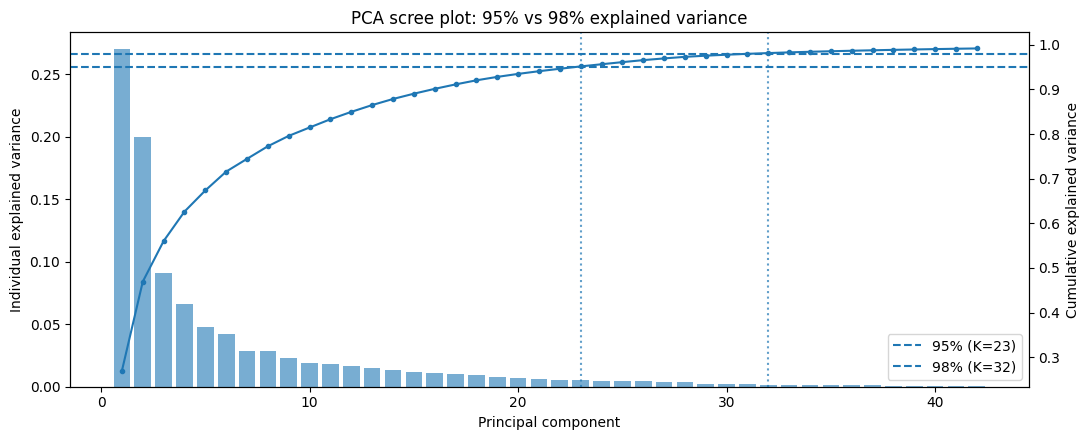


Final PCA:
  Explained variance threshold: 98%
  Components selected: K=32
  Z_train=(4237, 32)  Z_val=(985, 32)  Z_test=(668, 32)


In [13]:
# CELL 7
# PCA variance-threshold diagnostic and final PCA transformation.
# The final variance threshold is selected empirically by comparing Ridge
# validation performance at 90%, 95% and 98% explained variance.

PCA_THRESHOLDS = [0.90, 0.95, 0.98]
FINAL_VAR_THRESHOLD = 0.98
RIDGE_ALPHA = 1.0
MIN_R2_GAIN_FOR_98 = 0.005
PCA_SCREE_PATH = "sprint5_pca_scree.png"

pca_full = PCA(n_components=None, random_state=RANDOM_STATE)
pca_full.fit(X_train_norm)

cum_var = np.cumsum(pca_full.explained_variance_ratio_)

threshold_to_k = {
    threshold: int(np.searchsorted(cum_var, threshold) + 1)
    for threshold in PCA_THRESHOLDS
}

K_90 = threshold_to_k[0.90]
K_95 = threshold_to_k[0.95]
K_98 = threshold_to_k[0.98]

print("PCA components by explained-variance threshold:")
for threshold, k in threshold_to_k.items():
    print(f"  {threshold:.0%}: K={k}")

print(f"  Input features: {X_train_norm.shape[1]:,}")
print(f"  Extra components from 95% to 98%: {K_98 - K_95}")

def ridge_validation_score(K, X_tr, X_v, y_tr, y_v, train_mask, val_mask):
    """Fit Ridge on the first K principal components and return VAL metrics."""
    pca_k = PCA(n_components=K, random_state=RANDOM_STATE)

    Z_tr = pca_k.fit_transform(X_tr)
    Z_v  = pca_k.transform(X_v)

    model = Ridge(alpha=RIDGE_ALPHA, random_state=RANDOM_STATE)
    model.fit(Z_tr[train_mask.values], y_tr.values[train_mask.values])

    pred = model.predict(Z_v[val_mask.values])

    r2 = r2_score(y_v.values[val_mask.values], pred)
    mae = mean_absolute_error(y_v.values[val_mask.values], pred)
    rmse = np.sqrt(mean_squared_error(y_v.values[val_mask.values], pred))

    return r2, mae, rmse

diagnostic_rows = []

for threshold, k in threshold_to_k.items():
    pie_r2, pie_mae, pie_rmse = ridge_validation_score(
        K=k,
        X_tr=X_train_norm,
        X_v=X_val_norm,
        y_tr=y_pie_train,
        y_v=y_pie_val,
        train_mask=mask_pie_train,
        val_mask=mask_pie_val,
    )

    sal_r2, sal_mae, sal_rmse = ridge_validation_score(
        K=k,
        X_tr=X_train_norm,
        X_v=X_val_norm,
        y_tr=y_sal_train,
        y_v=y_sal_val,
        train_mask=mask_sal_train,
        val_mask=mask_sal_val,
    )

    diagnostic_rows.append({
        "threshold": f"{threshold:.0%}",
        "K": k,
        "PIE_val_R2": round(pie_r2, 4),
        "PIE_val_MAE": round(pie_mae, 5),
        "SAL_val_R2": round(sal_r2, 4),
        "SAL_val_MAE": round(sal_mae, 5),
    })

pca_diagnostic = pd.DataFrame(diagnostic_rows)

print("\nRidge validation diagnostic:")
print(pca_diagnostic.to_string(index=False))

pie_r2_95 = pca_diagnostic.loc[
    pca_diagnostic["threshold"] == "95%", "PIE_val_R2"
].iloc[0]
pie_r2_98 = pca_diagnostic.loc[
    pca_diagnostic["threshold"] == "98%", "PIE_val_R2"
].iloc[0]

sal_r2_95 = pca_diagnostic.loc[
    pca_diagnostic["threshold"] == "95%", "SAL_val_R2"
].iloc[0]
sal_r2_98 = pca_diagnostic.loc[
    pca_diagnostic["threshold"] == "98%", "SAL_val_R2"
].iloc[0]

delta_pie_98_vs_95 = pie_r2_98 - pie_r2_95
delta_sal_98_vs_95 = sal_r2_98 - sal_r2_95

print("\nValidation R2 gain from 95% to 98%:")
print(f"  PIE: {delta_pie_98_vs_95:+.4f}")
print(f"  SAL: {delta_sal_98_vs_95:+.4f}")

if max(delta_pie_98_vs_95, delta_sal_98_vs_95) >= MIN_R2_GAIN_FOR_98:
    print("Decision note: 98% is empirically justified by validation signal.")
else:
    print("Decision note: 95% may be preferable if 98% adds no validation signal.")

fig, ax = plt.subplots(figsize=(11, 4.5))
n_plot = min(K_98 + 10, len(cum_var))
x_axis = range(1, n_plot + 1)

ax.bar(x_axis, pca_full.explained_variance_ratio_[:n_plot], alpha=0.6)
ax.set_xlabel("Principal component")
ax.set_ylabel("Individual explained variance")

ax2 = ax.twinx()
ax2.plot(x_axis, cum_var[:n_plot], marker="o", markersize=3)
ax2.axhline(0.95, linestyle="--", label=f"95% (K={K_95})")
ax2.axhline(0.98, linestyle="--", label=f"98% (K={K_98})")
ax2.axvline(K_95, linestyle=":", alpha=0.7)
ax2.axvline(K_98, linestyle=":", alpha=0.7)
ax2.set_ylabel("Cumulative explained variance")
ax2.legend(loc="lower right")

ax.set_title("PCA scree plot: 95% vs 98% explained variance")
plt.tight_layout()
plt.savefig(PCA_SCREE_PATH, dpi=150, bbox_inches="tight")
plt.show()

K = threshold_to_k[FINAL_VAR_THRESHOLD]

pca = PCA(n_components=K, random_state=RANDOM_STATE)

Z_train = pca.fit_transform(X_train_norm)
Z_val   = pca.transform(X_val_norm)
Z_test  = pca.transform(X_test_norm)

assert Z_train.shape[1] == Z_val.shape[1] == Z_test.shape[1] == K, \
    "PCA output dimensions are inconsistent across splits"

print(f"\nFinal PCA:")
print(f"  Explained variance threshold: {FINAL_VAR_THRESHOLD:.0%}")
print(f"  Components selected: K={K}")
print(f"  Z_train={Z_train.shape}  Z_val={Z_val.shape}  Z_test={Z_test.shape}")

In [14]:
# CELL 8
# Build final PCA feature matrices.

pca_cols = [f"PC{i + 1}" for i in range(K)]

X_train_final = pd.DataFrame(Z_train, columns=pca_cols, index=X_train.index)
X_val_final   = pd.DataFrame(Z_val,   columns=pca_cols, index=X_val.index)
X_test_final  = pd.DataFrame(Z_test,  columns=pca_cols, index=X_test.index)

print(f"Final feature matrices:")
print(f"  TRAIN: {X_train_final.shape}")
print(f"  VAL  : {X_val_final.shape}")
print(f"  TEST : {X_test_final.shape}")
print(f"  PCA components: {K}")

Final feature matrices:
  TRAIN: (4237, 32)
  VAL  : (985, 32)
  TEST : (668, 32)
  PCA components: 32


In [15]:
# CELL 9
# Unified evaluation and tuning helpers.
# Metrics: R2, MAE and RMSE for both targets; salary also reports MAE in dollars.
# Target-specific masks are used to exclude rows where the selected target is NaN.

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

CAP_BY_SPLIT = {
    "TRAIN": float(df_model.loc[idx_train, "SALARY_CAP"].mean()),
    "VAL":   float(df_model.loc[idx_val,   "SALARY_CAP"].mean()),
    "TEST":  float(df_model.loc[idx_test,  "SALARY_CAP"].mean()),
}

def evaluate(split_name, y_true, y_pred, target, verbose=True):
    """Evaluate predictions for one split and one target."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    assert len(y_true) == len(y_pred), \
        f"Length mismatch in {split_name}: y_true={len(y_true)}, y_pred={len(y_pred)}"

    assert not np.isnan(y_true).any(), \
        f"{split_name} contains NaN values in y_true"

    assert not np.isnan(y_pred).any(), \
        f"{split_name} contains NaN values in y_pred"

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)

    row = {
        "target": target,
        "split": split_name,
        "R2": r2,
        "MAE": mae,
        "RMSE": rmse,
        "MAE_M": np.nan,
    }

    if target == "SAL":
        mae_m = mae * CAP_BY_SPLIT[split_name] / 1e6
        row["MAE_M"] = mae_m

        if verbose:
            print(f"  {split_name:<5} R2={r2:.4f}  MAE={mae:.5f}  "
                  f"RMSE={rmse:.5f}  MAE_$={mae_m:.2f}M")
    else:
        if verbose:
            print(f"  {split_name:<5} R2={r2:.4f}  MAE={mae:.5f}  RMSE={rmse:.5f}")

    return row

def run_model(
    name,
    model,
    X_tr,
    y_tr,
    X_v,
    y_v,
    X_te,
    y_te,
    target,
    train_mask,
    val_mask,
    test_mask,
):
    """Fit and evaluate one model using the target-specific non-NaN masks."""
    assert train_mask.sum() > 0, \
        f"{name}: no valid training rows after target masking"

    assert val_mask.sum() > 0, \
        f"{name}: no valid validation rows after target masking"

    assert test_mask.sum() > 0, \
        f"{name}: no valid test rows after target masking"

    model.fit(
        X_tr.loc[train_mask],
        y_tr.loc[train_mask],
    )

    print(f"\n{name}")

    results = [
        evaluate(
            "TRAIN",
            y_tr.loc[train_mask],
            model.predict(X_tr.loc[train_mask]),
            target,
        ),
        evaluate(
            "VAL",
            y_v.loc[val_mask],
            model.predict(X_v.loc[val_mask]),
            target,
        ),
        evaluate(
            "TEST",
            y_te.loc[test_mask],
            model.predict(X_te.loc[test_mask]),
            target,
        ),
    ]

    res_df = pd.DataFrame(results)
    res_df["model"] = name

    return model, res_df

def tune_val(
    model_fn,
    param_grid,
    X_tr,
    y_tr,
    X_v,
    y_v,
    train_mask,
    val_mask,
    silent=False,
):
    """Grid-search hyperparameters by maximizing validation R2."""
    assert train_mask.sum() > 0, \
        "No valid training rows after target masking"

    assert val_mask.sum() > 0, \
        "No valid validation rows after target masking"

    X_tr_fit = X_tr.loc[train_mask]
    y_tr_fit = y_tr.loc[train_mask]

    X_v_eval = X_v.loc[val_mask]
    y_v_eval = y_v.loc[val_mask]

    best_r2 = -np.inf
    best_params = None

    for combo in product(*param_grid.values()):
        params = dict(zip(param_grid.keys(), combo))

        model = model_fn(**params)
        model.fit(X_tr_fit, y_tr_fit)

        pred_val = model.predict(X_v_eval)
        val_r2 = r2_score(y_v_eval, pred_val)

        if not silent:
            print(f"  {params} -> Val R2={val_r2:.4f}")

        if val_r2 > best_r2:
            best_r2 = val_r2
            best_params = params

    assert best_params is not None, \
        "No valid parameter combination was evaluated"

    return best_params, best_r2

all_results = []

print("Unified helpers ready")
print("  Metrics: R2, MAE, RMSE")
print("  Salary metric: MAE converted to millions using split mean cap")

Unified helpers ready
  Metrics: R2, MAE, RMSE
  Salary metric: MAE converted to millions using split mean cap


In [16]:
# CELL 10
# Persistence baselines

print("Persistence baseline: PIE")

pie_pred_val  = df_model.loc[X_val_final.index, "PIE_ADVANCED"]
pie_pred_test = df_model.loc[X_test_final.index, "PIE_ADVANCED"]

res_persist_pie = pd.DataFrame([
    evaluate("VAL",  y_pie_val.loc[mask_pie_val],  pie_pred_val.loc[mask_pie_val],  "PIE"),
    evaluate("TEST", y_pie_test.loc[mask_pie_test], pie_pred_test.loc[mask_pie_test], "PIE"),
]).assign(model="Persistence_PIE")

all_results.append(res_persist_pie)

print("\nPersistence baseline: SAL")

sal_pred_val  = df_model.loc[X_val_final.index, "salary_share"]
sal_pred_test = df_model.loc[X_test_final.index, "salary_share"]

res_persist_sal = pd.DataFrame([
    evaluate("VAL",  y_sal_val.loc[mask_sal_val],  sal_pred_val.loc[mask_sal_val],  "SAL"),
    evaluate("TEST", y_sal_test.loc[mask_sal_test], sal_pred_test.loc[mask_sal_test], "SAL"),
]).assign(model="Persistence_SAL")

all_results.append(res_persist_sal)

Persistence baseline: PIE
  VAL   R2=0.6739  MAE=0.01416  RMSE=0.01799
  TEST  R2=0.7058  MAE=0.01315  RMSE=0.01650

Persistence baseline: SAL
  VAL   R2=0.6950  MAE=0.02337  RMSE=0.04985  MAE_$=2.58M
  TEST  R2=0.7601  MAE=0.02286  RMSE=0.04576  MAE_$=2.97M


# PERFORMANCE MODELLING


In [17]:
# CELL 11
# Regularized regression models for next-season PIE.

from sklearn.linear_model import Ridge, ElasticNet

print("Tuning Ridge for PIE")

ridge_grid = {
    "alpha": [1e-8, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0],
}

best_params_ridge_pie, best_r2_ridge_pie = tune_val(
    model_fn=lambda **p: Ridge(**p),
    param_grid=ridge_grid,
    X_tr=X_train_final,
    y_tr=y_pie_train,
    X_v=X_val_final,
    y_v=y_pie_val,
    train_mask=mask_pie_train,
    val_mask=mask_pie_val,
    silent=False,
)

print(f"Best Ridge params: {best_params_ridge_pie}  Val R2={best_r2_ridge_pie:.4f}")

ridge_pie, res_ridge_pie = run_model(
    name="Ridge_PIE_PCA",
    model=Ridge(**best_params_ridge_pie),
    X_tr=X_train_final,
    y_tr=y_pie_train,
    X_v=X_val_final,
    y_v=y_pie_val,
    X_te=X_test_final,
    y_te=y_pie_test,
    target="PIE",
    train_mask=mask_pie_train,
    val_mask=mask_pie_val,
    test_mask=mask_pie_test,
)

all_results.append(res_ridge_pie)

print("\nTuning ElasticNet for PIE")

enet_grid = {
    "alpha": [1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 1e-1],
    "l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9],
}

best_params_enet_pie, best_r2_enet_pie = tune_val(
    model_fn=lambda **p: ElasticNet(max_iter=20000, random_state=RANDOM_STATE, **p),
    param_grid=enet_grid,
    X_tr=X_train_final,
    y_tr=y_pie_train,
    X_v=X_val_final,
    y_v=y_pie_val,
    train_mask=mask_pie_train,
    val_mask=mask_pie_val,
    silent=True,
)

print(f"Best ElasticNet params: {best_params_enet_pie}  Val R2={best_r2_enet_pie:.4f}")

enet_pie, res_enet_pie = run_model(
    name="ElasticNet_PIE_PCA",
    model=ElasticNet(max_iter=20000, random_state=RANDOM_STATE, **best_params_enet_pie),
    X_tr=X_train_final,
    y_tr=y_pie_train,
    X_v=X_val_final,
    y_v=y_pie_val,
    X_te=X_test_final,
    y_te=y_pie_test,
    target="PIE",
    train_mask=mask_pie_train,
    val_mask=mask_pie_val,
    test_mask=mask_pie_test,
)

all_results.append(res_enet_pie)

Tuning Ridge for PIE
  {'alpha': 1e-08} -> Val R2=0.7512
  {'alpha': 1e-06} -> Val R2=0.7512
  {'alpha': 1e-05} -> Val R2=0.7512
  {'alpha': 0.0001} -> Val R2=0.7512
  {'alpha': 0.001} -> Val R2=0.7512
  {'alpha': 0.01} -> Val R2=0.7512
  {'alpha': 0.1} -> Val R2=0.7512
  {'alpha': 1.0} -> Val R2=0.7512
  {'alpha': 10.0} -> Val R2=0.7513
Best Ridge params: {'alpha': 10.0}  Val R2=0.7513

Ridge_PIE_PCA
  TRAIN R2=0.6843  MAE=0.01382  RMSE=0.01779
  VAL   R2=0.7513  MAE=0.01228  RMSE=0.01571
  TEST  R2=0.7566  MAE=0.01193  RMSE=0.01501

Tuning ElasticNet for PIE
Best ElasticNet params: {'alpha': 0.0003, 'l1_ratio': 0.5}  Val R2=0.7524

ElasticNet_PIE_PCA
  TRAIN R2=0.6834  MAE=0.01384  RMSE=0.01782
  VAL   R2=0.7524  MAE=0.01222  RMSE=0.01567
  TEST  R2=0.7566  MAE=0.01195  RMSE=0.01501


Optimizing XGBoost for PIE with Optuna (200 trials)


  0%|          | 0/200 [00:00<?, ?it/s]


Best XGBoost PIE Val R2: 0.7372
Best XGBoost PIE params: {'n_estimators': 1200, 'learning_rate': 0.021769701509925226, 'max_depth': 3, 'min_child_weight': 9, 'subsample': 0.7426339651025914, 'colsample_bytree': 0.9373076403347294, 'colsample_bylevel': 0.8750327231241275, 'reg_alpha': 0.002049006784659258, 'reg_lambda': 3.1530109142663516, 'gamma': 0.0014128445406133027}

XGBoost_PIE_PCA
  TRAIN R2=0.7789  MAE=0.01164  RMSE=0.01489
  VAL   R2=0.7372  MAE=0.01267  RMSE=0.01615
  TEST  R2=0.7293  MAE=0.01257  RMSE=0.01583


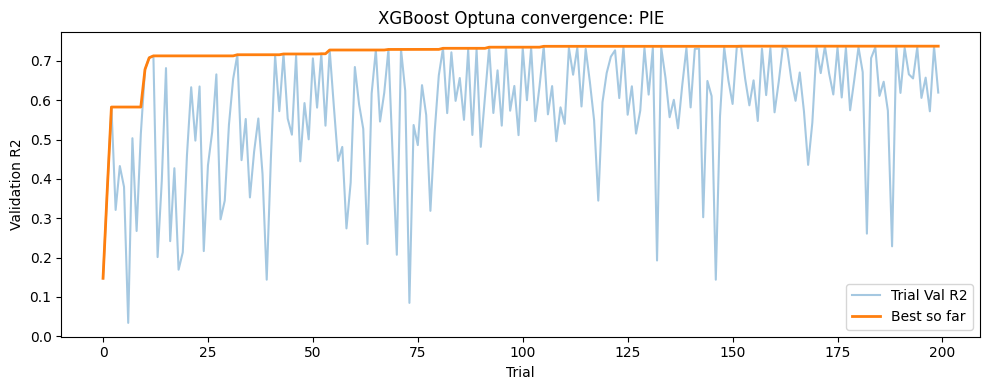

In [18]:
# CELL 12
# XGBoost model for next-season PIE with Optuna tuning.
# The objective maximizes validation R2 on the fixed temporal VAL split.

from xgboost import XGBRegressor

N_XGB_TRIALS_PIE = 200
XGB_PIE_PLOT_PATH = "xgb_optuna_pie.png"

X_train_pie = X_train_final.loc[mask_pie_train]
y_train_pie = y_pie_train.loc[mask_pie_train]

X_val_pie = X_val_final.loc[mask_pie_val]
y_val_pie = y_pie_val.loc[mask_pie_val]

def xgb_objective_pie(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 300, 1500, step=100),
        "learning_rate":     trial.suggest_float("learning_rate", 0.005, 0.15, log=True),
        "max_depth":         trial.suggest_int("max_depth", 2, 5),
        "min_child_weight":  trial.suggest_int("min_child_weight", 1, 10),
        "subsample":         trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.5, 1.0),
        "reg_alpha":         trial.suggest_float("reg_alpha", 1e-4, 5.0, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 0.5, 10.0, log=True),
        "gamma":             trial.suggest_float("gamma", 0.0, 1.0),
        "objective":         "reg:squarederror",
        "tree_method":       "hist",
        "random_state":      RANDOM_STATE,
        "n_jobs":            -1,
        "verbosity":         0,
    }

    model = XGBRegressor(**params)
    model.fit(
        X_train_pie, y_train_pie,
        eval_set=[(X_val_pie, y_val_pie)],
        verbose=False,
    )

    pred_val = model.predict(X_val_pie)
    return r2_score(y_val_pie, pred_val)

print(f"Optimizing XGBoost for PIE with Optuna ({N_XGB_TRIALS_PIE} trials)")

study_xgb_pie = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
)

study_xgb_pie.optimize(
    xgb_objective_pie,
    n_trials=N_XGB_TRIALS_PIE,
    show_progress_bar=True,
)

best_xgb_params_pie = study_xgb_pie.best_params.copy()
best_xgb_params_pie.update({
    "objective": "reg:squarederror",
    "tree_method": "hist",
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "verbosity": 0,
})

print(f"\nBest XGBoost PIE Val R2: {study_xgb_pie.best_value:.4f}")
print(f"Best XGBoost PIE params: {study_xgb_pie.best_params}")

xgb_pie, res_xgb_pie = run_model(
    name="XGBoost_PIE_PCA",
    model=XGBRegressor(**best_xgb_params_pie),
    X_tr=X_train_final,
    y_tr=y_pie_train,
    X_v=X_val_final,
    y_v=y_pie_val,
    X_te=X_test_final,
    y_te=y_pie_test,
    target="PIE",
    train_mask=mask_pie_train,
    val_mask=mask_pie_val,
    test_mask=mask_pie_test,
)

all_results.append(res_xgb_pie)

fig, ax = plt.subplots(figsize=(10, 4))

trials_r2 = [t.value for t in study_xgb_pie.trials if t.value is not None]
ax.plot(trials_r2, alpha=0.4, label="Trial Val R2")
ax.plot(pd.Series(trials_r2).cummax(), linewidth=2, label="Best so far")
ax.set_xlabel("Trial")
ax.set_ylabel("Validation R2")
ax.set_title("XGBoost Optuna convergence: PIE")
ax.legend()

plt.tight_layout()
plt.savefig(XGB_PIE_PLOT_PATH, dpi=150, bbox_inches="tight")
plt.show()

Optimizing LightGBM for PIE with Optuna (200 trials)


  0%|          | 0/200 [00:00<?, ?it/s]


Best LightGBM PIE Val R2: 0.7388
Best LightGBM PIE params: {'max_depth': 2, 'n_estimators': 3000, 'learning_rate': 0.017988549337677677, 'num_leaves': 2, 'min_child_samples': 16, 'min_child_weight': 0.004634429168075699, 'subsample': 0.9909477030477042, 'subsample_freq': 2, 'colsample_bytree': 0.6750199895082941, 'reg_alpha': 0.01681774006172645, 'reg_lambda': 0.4643743673054844, 'min_split_gain': 0.0011322447962534296}
Best iteration: 2999

LightGBM_PIE_PCA
  TRAIN R2=0.6997  MAE=0.01351  RMSE=0.01735
  VAL   R2=0.7388  MAE=0.01267  RMSE=0.01610
  TEST  R2=0.7294  MAE=0.01256  RMSE=0.01582


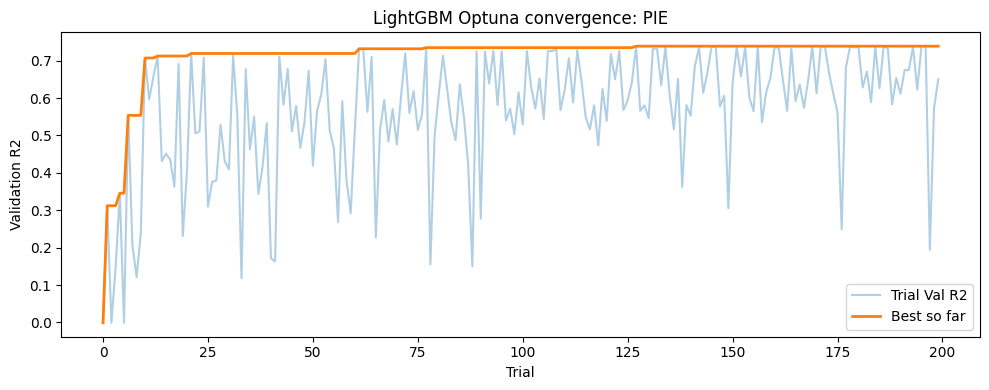

In [19]:
# CELL 13
# LightGBM model for next-season PIE with Optuna tuning.
# The objective maximizes validation R2 on the fixed temporal VAL split.

from lightgbm import LGBMRegressor

N_LGBM_TRIALS_PIE = 200
LGBM_PIE_PLOT_PATH = "lgbm_optuna_pie.png"

X_train_pie = X_train_final.loc[mask_pie_train]
y_train_pie = y_pie_train.loc[mask_pie_train]

X_val_pie = X_val_final.loc[mask_pie_val]
y_val_pie = y_pie_val.loc[mask_pie_val]

X_test_pie = X_test_final.loc[mask_pie_test]
y_test_pie = y_pie_test.loc[mask_pie_test]

def lgbm_objective_pie(trial):
    max_depth = trial.suggest_int("max_depth", 2, 8)
    max_num_leaves = min((2 ** max_depth) - 1, 127)

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 500, 5000, step=250),
        "learning_rate": trial.suggest_float("learning_rate", 0.003, 0.08, log=True),
        "max_depth": max_depth,
        "num_leaves": trial.suggest_int("num_leaves", 2, max_num_leaves),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 60),
        "min_child_weight": trial.suggest_float("min_child_weight", 1e-3, 10.0, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "subsample_freq": trial.suggest_int("subsample_freq", 1, 7),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 20.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 20.0, log=True),
        "min_split_gain": trial.suggest_float("min_split_gain", 0.0, 1.0),
        "objective": "regression",
        "boosting_type": "gbdt",
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
        "verbosity": -1,
    }

    model = LGBMRegressor(**params)
    model.fit(
        X_train_pie,
        y_train_pie,
        eval_set=[(X_val_pie, y_val_pie)],
        eval_metric="l2",
        callbacks=[
            lgb.early_stopping(stopping_rounds=100, verbose=False),
            lgb.log_evaluation(period=0),
        ],
    )

    pred_val = model.predict(X_val_pie, num_iteration=model.best_iteration_)
    return r2_score(y_val_pie, pred_val)

print(f"Optimizing LightGBM for PIE with Optuna ({N_LGBM_TRIALS_PIE} trials)")

study_lgbm_pie = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=30, n_warmup_steps=20),
)

study_lgbm_pie.optimize(
    lgbm_objective_pie,
    n_trials=N_LGBM_TRIALS_PIE,
    show_progress_bar=True,
)

best_lgbm_params_pie = study_lgbm_pie.best_params.copy()
best_lgbm_params_pie.update({
    "objective": "regression",
    "boosting_type": "gbdt",
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "verbosity": -1,
})

print(f"\nBest LightGBM PIE Val R2: {study_lgbm_pie.best_value:.4f}")
print(f"Best LightGBM PIE params: {study_lgbm_pie.best_params}")

lgbm_pie = LGBMRegressor(**best_lgbm_params_pie)
lgbm_pie.fit(
    X_train_pie,
    y_train_pie,
    eval_set=[(X_val_pie, y_val_pie)],
    eval_metric="l2",
    callbacks=[
        lgb.early_stopping(stopping_rounds=100, verbose=False),
        lgb.log_evaluation(period=0),
    ],
)

print(f"Best iteration: {lgbm_pie.best_iteration_}")

pred_train = lgbm_pie.predict(X_train_pie, num_iteration=lgbm_pie.best_iteration_)
pred_val   = lgbm_pie.predict(X_val_pie,   num_iteration=lgbm_pie.best_iteration_)
pred_test  = lgbm_pie.predict(X_test_pie,  num_iteration=lgbm_pie.best_iteration_)

print("\nLightGBM_PIE_PCA")

res_lgbm_pie = pd.DataFrame([
    evaluate("TRAIN", y_train_pie, pred_train, "PIE"),
    evaluate("VAL",   y_val_pie,   pred_val,   "PIE"),
    evaluate("TEST",  y_test_pie,  pred_test,  "PIE"),
]).assign(model="LightGBM_PIE_PCA")

all_results.append(res_lgbm_pie)

trials_r2 = [t.value for t in study_lgbm_pie.trials if t.value is not None]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(trials_r2, alpha=0.35, label="Trial Val R2")
ax.plot(pd.Series(trials_r2).cummax(), linewidth=2, label="Best so far")
ax.set_xlabel("Trial")
ax.set_ylabel("Validation R2")
ax.set_title("LightGBM Optuna convergence: PIE")
ax.legend()

plt.tight_layout()
plt.savefig(LGBM_PIE_PLOT_PATH, dpi=150, bbox_inches="tight")
plt.show()

Optimizing MLP for PIE with Optuna (100 trials, 3 seeds/trial)


  0%|          | 0/100 [00:00<?, ?it/s]


Best MLP PIE avg Val R2: 0.7502
Best MLP PIE params:
  n_layers: 3
  units_l0: 16
  units_l1: 16
  units_l2: 32
  alpha: 0.012549461209465615
  learning_rate_init: 0.0006083707423008023
  batch_size: 64

Final fit with 10 seeds
  seed=  42  Val R2=0.7520  iters=173
  seed=   0  Val R2=0.7213  iters=116
  seed=   1  Val R2=0.7428  iters=187
  seed=   7  Val R2=0.7515  iters=210
  seed=  13  Val R2=0.7440  iters=167
  seed=  99  Val R2=0.7427  iters=134
  seed= 123  Val R2=0.7472  iters=203
  seed= 200  Val R2=0.7441  iters=173
  seed= 314  Val R2=0.7463  iters=171
  seed= 777  Val R2=0.7477  iters=131

Best individual seed Val R2: 0.7520

MLP_PIE_PCA
  TRAIN R2=0.6853  MAE=0.01380  RMSE=0.01776
  VAL   R2=0.7520  MAE=0.01225  RMSE=0.01569
  TEST  R2=0.7614  MAE=0.01186  RMSE=0.01486


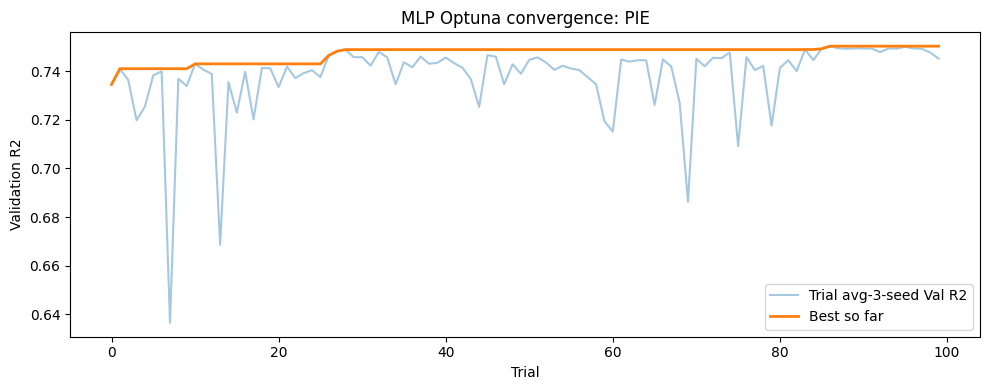

In [20]:
# CELL 14
# MLP model for next-season PIE with Optuna tuning and multi-seed training.

from sklearn.neural_network import MLPRegressor

N_MLP_TRIALS_PIE = 100
MLP_PIE_PLOT_PATH = "mlp_optuna_pie.png"
FINAL_SEEDS = [42, 0, 1, 7, 13, 99, 123, 200, 314, 777]

X_train_pie = X_train_final.loc[mask_pie_train]
y_train_pie = y_pie_train.loc[mask_pie_train]

X_val_pie = X_val_final.loc[mask_pie_val]
y_val_pie = y_pie_val.loc[mask_pie_val]

X_test_pie = X_test_final.loc[mask_pie_test]
y_test_pie = y_pie_test.loc[mask_pie_test]

def mlp_objective_pie(trial):
    n_layers = trial.suggest_int("n_layers", 2, 4)
    layers = []

    for i in range(n_layers):
        max_units = max(16, 256 // (2 ** i))
        units = trial.suggest_int(f"units_l{i}", 16, max_units, step=16)
        layers.append(units)

    params = {
        "hidden_layer_sizes": tuple(layers),
        "alpha": trial.suggest_float("alpha", 5e-4, 0.1, log=True),
        "learning_rate_init": trial.suggest_float("learning_rate_init", 5e-4, 1e-2, log=True),
        "batch_size": trial.suggest_categorical("batch_size", [16, 32, 64]),
        "solver": "adam",
        "learning_rate": "adaptive",
        "max_iter": 700,
        "early_stopping": True,
        "validation_fraction": 0.10,
        "n_iter_no_change": 30,
    }

    r2_seeds = []

    for seed in [42, 123, 7]:
        model = MLPRegressor(random_state=seed, **params)
        model.fit(X_train_pie, y_train_pie)
        r2_seeds.append(r2_score(y_val_pie, model.predict(X_val_pie)))

    return float(np.mean(r2_seeds))

print(f"Optimizing MLP for PIE with Optuna ({N_MLP_TRIALS_PIE} trials, 3 seeds/trial)")

study_mlp_pie = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
)

study_mlp_pie.optimize(
    mlp_objective_pie,
    n_trials=N_MLP_TRIALS_PIE,
    show_progress_bar=True,
)

print(f"\nBest MLP PIE avg Val R2: {study_mlp_pie.best_value:.4f}")
print("Best MLP PIE params:")
for key, value in study_mlp_pie.best_params.items():
    print(f"  {key}: {value}")

best_trial_params = study_mlp_pie.best_params
n_layers_best = best_trial_params["n_layers"]
best_arch = tuple(best_trial_params[f"units_l{i}"] for i in range(n_layers_best))

best_mlp_base_pie = {
    "hidden_layer_sizes": best_arch,
    "alpha": best_trial_params["alpha"],
    "learning_rate_init": best_trial_params["learning_rate_init"],
    "batch_size": best_trial_params["batch_size"],
    "solver": "adam",
    "learning_rate": "adaptive",
    "max_iter": 800,
    "early_stopping": True,
    "validation_fraction": 0.10,
    "n_iter_no_change": 30,
}

print("\nFinal fit with 10 seeds")

best_val_r2_final = -np.inf
best_mlp_model_pie = None

for seed in FINAL_SEEDS:
    model = MLPRegressor(random_state=seed, **best_mlp_base_pie)
    model.fit(X_train_pie, y_train_pie)

    val_r2 = r2_score(y_val_pie, model.predict(X_val_pie))
    print(f"  seed={seed:4d}  Val R2={val_r2:.4f}  iters={model.n_iter_}")

    if val_r2 > best_val_r2_final:
        best_val_r2_final = val_r2
        best_mlp_model_pie = model

print(f"\nBest individual seed Val R2: {best_val_r2_final:.4f}")

mlp_pie = best_mlp_model_pie

print("\nMLP_PIE_PCA")

res_mlp_pie = pd.DataFrame([
    evaluate("TRAIN", y_train_pie, mlp_pie.predict(X_train_pie), "PIE"),
    evaluate("VAL",   y_val_pie,   mlp_pie.predict(X_val_pie),   "PIE"),
    evaluate("TEST",  y_test_pie,  mlp_pie.predict(X_test_pie),  "PIE"),
]).assign(model="MLP_PIE_PCA")

all_results.append(res_mlp_pie)

trials_r2 = [trial.value for trial in study_mlp_pie.trials if trial.value is not None]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(trials_r2, alpha=0.4, label="Trial avg-3-seed Val R2")
ax.plot(pd.Series(trials_r2).cummax(), linewidth=2, label="Best so far")
ax.set_xlabel("Trial")
ax.set_ylabel("Validation R2")
ax.set_title("MLP Optuna convergence: PIE")
ax.legend()

plt.tight_layout()
plt.savefig(MLP_PIE_PLOT_PATH, dpi=150, bbox_inches="tight")
plt.show()

RESULTS — PIE_(t+1) PREDICTION  [Unified pipeline · PCA only · no archetypes]
  Tuning: Ridge/EN -> manual grid | XGB/LGBM/MLP -> Optuna
  MLP: Optuna + multi-seed final selection
             model split     R2    MAE   RMSE
   Persistence_PIE   VAL 0.6739 0.0142 0.0180
   Persistence_PIE  TEST 0.7058 0.0132 0.0165
     Ridge_PIE_PCA TRAIN 0.6843 0.0138 0.0178
     Ridge_PIE_PCA   VAL 0.7513 0.0123 0.0157
     Ridge_PIE_PCA  TEST 0.7566 0.0119 0.0150
ElasticNet_PIE_PCA TRAIN 0.6834 0.0138 0.0178
ElasticNet_PIE_PCA   VAL 0.7524 0.0122 0.0157
ElasticNet_PIE_PCA  TEST 0.7566 0.0120 0.0150
   XGBoost_PIE_PCA TRAIN 0.7789 0.0116 0.0149
   XGBoost_PIE_PCA   VAL 0.7372 0.0127 0.0162
   XGBoost_PIE_PCA  TEST 0.7293 0.0126 0.0158
  LightGBM_PIE_PCA TRAIN 0.6997 0.0135 0.0174
  LightGBM_PIE_PCA   VAL 0.7388 0.0127 0.0161
  LightGBM_PIE_PCA  TEST 0.7294 0.0126 0.0158
       MLP_PIE_PCA TRAIN 0.6853 0.0138 0.0178
       MLP_PIE_PCA   VAL 0.7520 0.0122 0.0157
       MLP_PIE_PCA  TEST 0.7614 0.0119

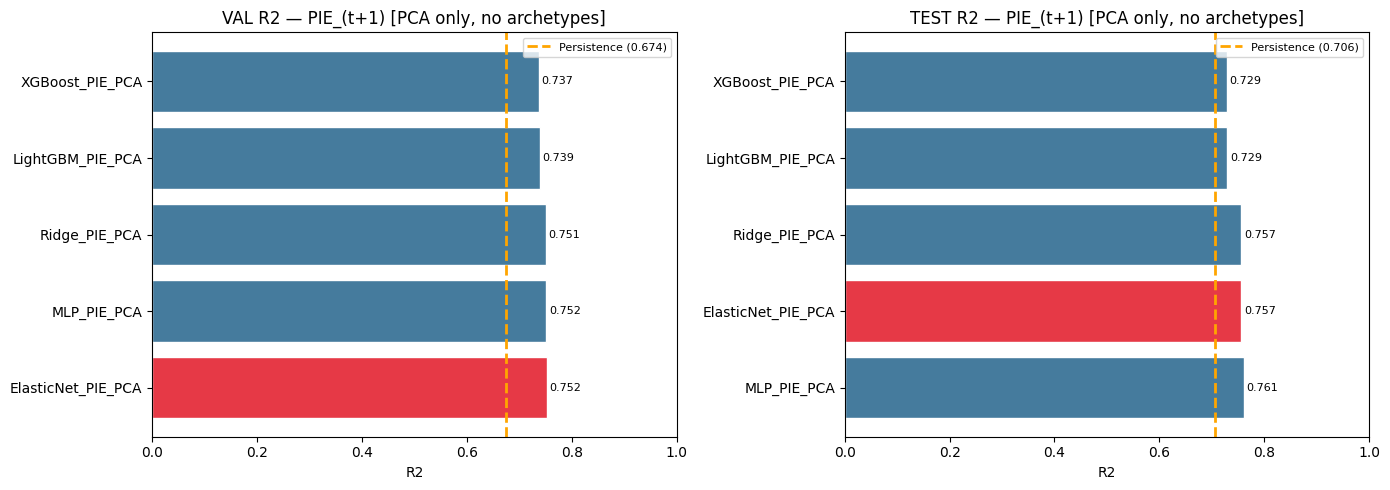

In [21]:
# CELL 15
# Summarize PIE model results

results_pie = pd.concat(all_results, ignore_index=True)
results_pie = results_pie[results_pie["target"] == "PIE"].copy()
results_pie = results_pie.drop(columns=["MAE_M"], errors="ignore")

print("=" * 78)
print("RESULTS — PIE_(t+1) PREDICTION  [Unified pipeline · PCA only · no archetypes]")
print("  Tuning: Ridge/EN -> manual grid | XGB/LGBM/MLP -> Optuna")
print("  MLP: Optuna + multi-seed final selection")
print("=" * 78)
print(results_pie[["model", "split", "R2", "MAE", "RMSE"]].to_string(index=False))

# Validation ranking
print("\nValidation ranking by R2:")
val_pie = (
    results_pie[results_pie["split"] == "VAL"]
    .sort_values("R2", ascending=False)
    .reset_index(drop=True)
)
print(val_pie[["model", "R2", "MAE", "RMSE"]].to_string(index=False))

# Persistence comparison
persist_row_val = results_pie[
    (results_pie["model"] == "Persistence_PIE") &
    (results_pie["split"] == "VAL")
].iloc[0]

persist_row_test = results_pie[
    (results_pie["model"] == "Persistence_PIE") &
    (results_pie["split"] == "TEST")
].iloc[0]

persist_val_r2 = persist_row_val["R2"]
persist_test_r2 = persist_row_test["R2"]

val_pie_ml = val_pie[val_pie["model"] != "Persistence_PIE"].reset_index(drop=True)

best_model_name = val_pie_ml.iloc[0]["model"]
best_val_r2 = val_pie_ml.iloc[0]["R2"]

best_test_r2 = results_pie[
    (results_pie["model"] == best_model_name) &
    (results_pie["split"] == "TEST")
]["R2"].values[0]

print("\nPersistence comparison:")
print(f"  Persistence baseline           — Val R2: {persist_val_r2:.4f}  |  Test R2: {persist_test_r2:.4f}")
print(f"  Best ML ({best_model_name:20s}) — Val R2: {best_val_r2:.4f}  |  Test R2: {best_test_r2:.4f}")
print(f"  Improvement over baseline      — Val: {best_val_r2 - persist_val_r2:+.4f}  |  Test: {best_test_r2 - persist_test_r2:+.4f}")
print(f"\nBest VAL model: {best_model_name}")


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for split_name, ax in zip(["VAL", "TEST"], axes):
    sub = results_pie[
        (results_pie["split"] == split_name) &
        (results_pie["model"] != "Persistence_PIE")
    ].sort_values("R2", ascending=False)

    colors = ["#e63946" if m == best_model_name else "#457b9d" for m in sub["model"]]
    bars = ax.barh(sub["model"], sub["R2"], color=colors, edgecolor="white")

    persist_r2 = persist_val_r2 if split_name == "VAL" else persist_test_r2

    ax.axvline(
        persist_r2,
        color="orange",
        linestyle="--",
        linewidth=2,
        label=f"Persistence ({persist_r2:.3f})",
    )

    ax.set_xlabel("R2")
    ax.set_title(f"{split_name} R2 — PIE_(t+1) [PCA only, no archetypes]")
    ax.set_xlim(0, max(1.0, sub["R2"].max() * 1.1))
    ax.legend(fontsize=8)

    for bar, val in zip(bars, sub["R2"]):
        ax.text(
            bar.get_width() + 0.005,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}",
            va="center",
            fontsize=8,
        )

plt.tight_layout()
plt.savefig("pie_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# SALARY MODELLING

In [22]:
# CELL 16
# Regularized regression models for next-season salary share

from sklearn.linear_model import Ridge, ElasticNet
print("Tuning Ridge for SAL")

ridge_grid_sal = {
    "alpha": [1e-8, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0],
}

best_params_ridge_sal, best_r2_ridge_sal = tune_val(
    model_fn=lambda **p: Ridge(**p),
    param_grid=ridge_grid_sal,
    X_tr=X_train_final,
    y_tr=y_sal_train,
    X_v=X_val_final,
    y_v=y_sal_val,
    train_mask=mask_sal_train,
    val_mask=mask_sal_val,
    silent=False,
)

print(f"Best Ridge params: {best_params_ridge_sal}  Val R2={best_r2_ridge_sal:.4f}")

ridge_sal, res_ridge_sal = run_model(
    name="Ridge_SAL_PCA",
    model=Ridge(**best_params_ridge_sal),
    X_tr=X_train_final,
    y_tr=y_sal_train,
    X_v=X_val_final,
    y_v=y_sal_val,
    X_te=X_test_final,
    y_te=y_sal_test,
    target="SAL",
    train_mask=mask_sal_train,
    val_mask=mask_sal_val,
    test_mask=mask_sal_test,
)

all_results.append(res_ridge_sal)

print("\nTuning ElasticNet for SAL")

enet_grid_sal = {
    "alpha": [1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 1e-1],
    "l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9],
}

best_params_enet_sal, best_r2_enet_sal = tune_val(
    model_fn=lambda **p: ElasticNet(max_iter=20000, random_state=RANDOM_STATE, **p),
    param_grid=enet_grid_sal,
    X_tr=X_train_final,
    y_tr=y_sal_train,
    X_v=X_val_final,
    y_v=y_sal_val,
    train_mask=mask_sal_train,
    val_mask=mask_sal_val,
    silent=True,
)

print(f"Best ElasticNet params: {best_params_enet_sal}  Val R2={best_r2_enet_sal:.4f}")

enet_sal, res_enet_sal = run_model(
    name="ElasticNet_SAL_PCA",
    model=ElasticNet(max_iter=20000, random_state=RANDOM_STATE, **best_params_enet_sal),
    X_tr=X_train_final,
    y_tr=y_sal_train,
    X_v=X_val_final,
    y_v=y_sal_val,
    X_te=X_test_final,
    y_te=y_sal_test,
    target="SAL",
    train_mask=mask_sal_train,
    val_mask=mask_sal_val,
    test_mask=mask_sal_test,
)

all_results.append(res_enet_sal)

Tuning Ridge for SAL
  {'alpha': 1e-08} -> Val R2=0.7405
  {'alpha': 1e-06} -> Val R2=0.7405
  {'alpha': 1e-05} -> Val R2=0.7405
  {'alpha': 0.0001} -> Val R2=0.7405
  {'alpha': 0.001} -> Val R2=0.7405
  {'alpha': 0.01} -> Val R2=0.7405
  {'alpha': 0.1} -> Val R2=0.7405
  {'alpha': 1.0} -> Val R2=0.7405
  {'alpha': 10.0} -> Val R2=0.7406
Best Ridge params: {'alpha': 10.0}  Val R2=0.7406

Ridge_SAL_PCA
  TRAIN R2=0.7423  MAE=0.02953  RMSE=0.04237  MAE_$=1.98M
  VAL   R2=0.7406  MAE=0.03112  RMSE=0.04598  MAE_$=3.43M
  TEST  R2=0.8031  MAE=0.02986  RMSE=0.04146  MAE_$=3.88M

Tuning ElasticNet for SAL
Best ElasticNet params: {'alpha': 0.001, 'l1_ratio': 0.1}  Val R2=0.7407

ElasticNet_SAL_PCA
  TRAIN R2=0.7423  MAE=0.02956  RMSE=0.04237  MAE_$=1.99M
  VAL   R2=0.7407  MAE=0.03118  RMSE=0.04597  MAE_$=3.44M
  TEST  R2=0.8031  MAE=0.02986  RMSE=0.04145  MAE_$=3.88M


Optimizing XGBoost for SAL with Optuna (200 trials)


  0%|          | 0/200 [00:00<?, ?it/s]


Best XGBoost SAL Val R2: 0.7494
Best XGBoost SAL params: {'n_estimators': 1500, 'learning_rate': 0.03996642922418521, 'max_depth': 5, 'min_child_weight': 4, 'subsample': 0.8310516520483785, 'colsample_bytree': 0.9126799529824742, 'colsample_bylevel': 0.5444523353906778, 'reg_alpha': 0.004249614377146065, 'reg_lambda': 2.3093320757924585, 'gamma': 0.003491732457829606}

XGBoost_SAL_PCA
  TRAIN R2=0.9078  MAE=0.01865  RMSE=0.02534  MAE_$=1.25M
  VAL   R2=0.7494  MAE=0.03219  RMSE=0.04519  MAE_$=3.55M
  TEST  R2=0.7717  MAE=0.03383  RMSE=0.04464  MAE_$=4.39M


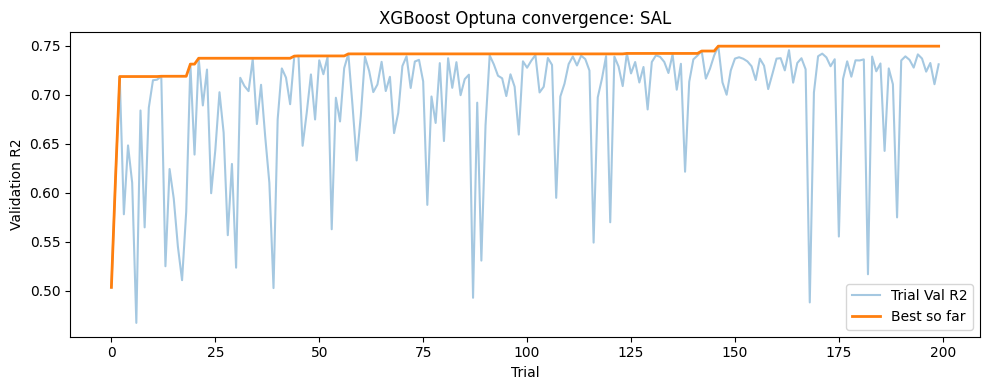

In [23]:
# CELL 17
# XGBoost model for next-season salary share with Optuna tuning.

from xgboost import XGBRegressor

N_XGB_TRIALS_SAL = 200
XGB_SAL_PLOT_PATH = "xgb_optuna_sal.png"

X_train_sal = X_train_final.loc[mask_sal_train]
y_train_sal = y_sal_train.loc[mask_sal_train]

X_val_sal = X_val_final.loc[mask_sal_val]
y_val_sal = y_sal_val.loc[mask_sal_val]

X_test_sal = X_test_final.loc[mask_sal_test]
y_test_sal = y_sal_test.loc[mask_sal_test]

def xgb_objective_sal(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 1500, step=100),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.15, log=True),
        "max_depth": trial.suggest_int("max_depth", 2, 5),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 5.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.5, 10.0, log=True),
        "gamma": trial.suggest_float("gamma", 0.0, 1.0),
        "objective": "reg:squarederror",
        "tree_method": "hist",
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
        "verbosity": 0,
    }

    model = XGBRegressor(**params)
    model.fit(
        X_train_sal,
        y_train_sal,
        eval_set=[(X_val_sal, y_val_sal)],
        verbose=False,
    )

    return r2_score(y_val_sal, model.predict(X_val_sal))

print(f"Optimizing XGBoost for SAL with Optuna ({N_XGB_TRIALS_SAL} trials)")

study_xgb_sal = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
)

study_xgb_sal.optimize(
    xgb_objective_sal,
    n_trials=N_XGB_TRIALS_SAL,
    show_progress_bar=True,
)

best_xgb_params_sal = study_xgb_sal.best_params.copy()
best_xgb_params_sal.update({
    "objective": "reg:squarederror",
    "tree_method": "hist",
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "verbosity": 0,
})

print(f"\nBest XGBoost SAL Val R2: {study_xgb_sal.best_value:.4f}")
print(f"Best XGBoost SAL params: {study_xgb_sal.best_params}")

xgb_sal, res_xgb_sal = run_model(
    name="XGBoost_SAL_PCA",
    model=XGBRegressor(**best_xgb_params_sal),
    X_tr=X_train_final,
    y_tr=y_sal_train,
    X_v=X_val_final,
    y_v=y_sal_val,
    X_te=X_test_final,
    y_te=y_sal_test,
    target="SAL",
    train_mask=mask_sal_train,
    val_mask=mask_sal_val,
    test_mask=mask_sal_test,
)

all_results.append(res_xgb_sal)

trials_r2 = [t.value for t in study_xgb_sal.trials if t.value is not None]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(trials_r2, alpha=0.4, label="Trial Val R2")
ax.plot(pd.Series(trials_r2).cummax(), linewidth=2, label="Best so far")
ax.set_xlabel("Trial")
ax.set_ylabel("Validation R2")
ax.set_title("XGBoost Optuna convergence: SAL")
ax.legend()

plt.tight_layout()
plt.savefig(XGB_SAL_PLOT_PATH, dpi=150, bbox_inches="tight")
plt.show()

Optimizing LightGBM for SAL with Optuna (200 trials)


  0%|          | 0/200 [00:00<?, ?it/s]


Best LightGBM SAL Val R2: 0.7471
Best LightGBM SAL params: {'max_depth': 5, 'n_estimators': 5000, 'learning_rate': 0.010738547891623037, 'num_leaves': 9, 'min_child_samples': 49, 'min_child_weight': 0.005851689036108651, 'subsample': 0.9185635241750335, 'subsample_freq': 1, 'colsample_bytree': 0.6350341798964702, 'reg_alpha': 0.0008943218243075469, 'reg_lambda': 0.02251313249524635, 'min_split_gain': 0.0007574390461740025}
Best iteration: 1716

LightGBM_SAL_PCA
  TRAIN R2=0.8491  MAE=0.02351  RMSE=0.03242  MAE_$=1.58M
  VAL   R2=0.7471  MAE=0.03224  RMSE=0.04540  MAE_$=3.55M
  TEST  R2=0.7883  MAE=0.03236  RMSE=0.04299  MAE_$=4.20M


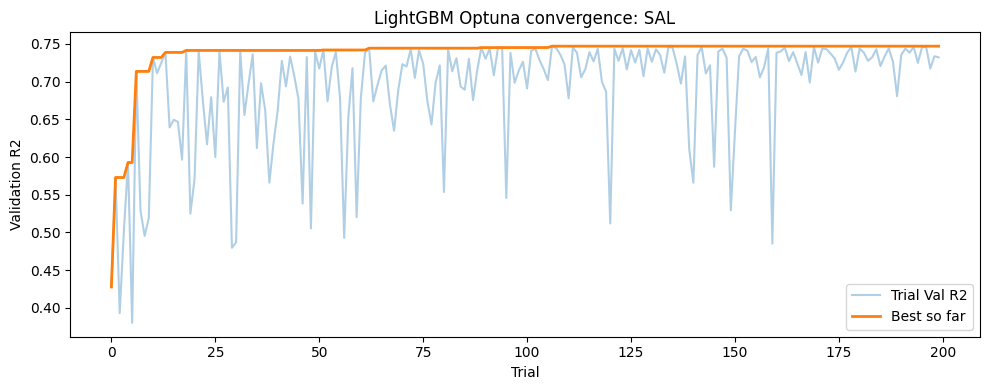

In [24]:
# CELL 18
# LightGBM model for next-season salary share with Optuna tuning.

from lightgbm import LGBMRegressor

N_LGBM_TRIALS_SAL = 200
LGBM_SAL_PLOT_PATH = "lgbm_optuna_sal.png"

X_train_sal = X_train_final.loc[mask_sal_train]
y_train_sal = y_sal_train.loc[mask_sal_train]

X_val_sal = X_val_final.loc[mask_sal_val]
y_val_sal = y_sal_val.loc[mask_sal_val]

X_test_sal = X_test_final.loc[mask_sal_test]
y_test_sal = y_sal_test.loc[mask_sal_test]

def lgbm_objective_sal(trial):
    max_depth = trial.suggest_int("max_depth", 2, 8)
    max_num_leaves = min((2 ** max_depth) - 1, 127)

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 500, 5000, step=250),
        "learning_rate": trial.suggest_float("learning_rate", 0.003, 0.08, log=True),
        "max_depth": max_depth,
        "num_leaves": trial.suggest_int("num_leaves", 2, max_num_leaves),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 60),
        "min_child_weight": trial.suggest_float("min_child_weight", 1e-3, 10.0, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "subsample_freq": trial.suggest_int("subsample_freq", 1, 7),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 20.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 20.0, log=True),
        "min_split_gain": trial.suggest_float("min_split_gain", 0.0, 1.0),
        "objective": "regression",
        "boosting_type": "gbdt",
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
        "verbosity": -1,
    }

    model = LGBMRegressor(**params)
    model.fit(
        X_train_sal,
        y_train_sal,
        eval_set=[(X_val_sal, y_val_sal)],
        eval_metric="l2",
        callbacks=[
            lgb.early_stopping(stopping_rounds=100, verbose=False),
            lgb.log_evaluation(period=0),
        ],
    )

    pred_val = model.predict(X_val_sal, num_iteration=model.best_iteration_)
    return r2_score(y_val_sal, pred_val)

print(f"Optimizing LightGBM for SAL with Optuna ({N_LGBM_TRIALS_SAL} trials)")

study_lgbm_sal = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=30, n_warmup_steps=20),
)

study_lgbm_sal.optimize(
    lgbm_objective_sal,
    n_trials=N_LGBM_TRIALS_SAL,
    show_progress_bar=True,
)

best_lgbm_params_sal = study_lgbm_sal.best_params.copy()
best_lgbm_params_sal.update({
    "objective": "regression",
    "boosting_type": "gbdt",
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "verbosity": -1,
})

print(f"\nBest LightGBM SAL Val R2: {study_lgbm_sal.best_value:.4f}")
print(f"Best LightGBM SAL params: {study_lgbm_sal.best_params}")

lgbm_sal = LGBMRegressor(**best_lgbm_params_sal)
lgbm_sal.fit(
    X_train_sal,
    y_train_sal,
    eval_set=[(X_val_sal, y_val_sal)],
    eval_metric="l2",
    callbacks=[
        lgb.early_stopping(stopping_rounds=100, verbose=False),
        lgb.log_evaluation(period=0),
    ],
)

print(f"Best iteration: {lgbm_sal.best_iteration_}")

pred_train = lgbm_sal.predict(X_train_sal, num_iteration=lgbm_sal.best_iteration_)
pred_val   = lgbm_sal.predict(X_val_sal,   num_iteration=lgbm_sal.best_iteration_)
pred_test  = lgbm_sal.predict(X_test_sal,  num_iteration=lgbm_sal.best_iteration_)

print("\nLightGBM_SAL_PCA")

res_lgbm_sal = pd.DataFrame([
    evaluate("TRAIN", y_train_sal, pred_train, "SAL"),
    evaluate("VAL",   y_val_sal,   pred_val,   "SAL"),
    evaluate("TEST",  y_test_sal,  pred_test,  "SAL"),
]).assign(model="LightGBM_SAL_PCA")

all_results.append(res_lgbm_sal)

trials_r2 = [t.value for t in study_lgbm_sal.trials if t.value is not None]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(trials_r2, alpha=0.35, label="Trial Val R2")
ax.plot(pd.Series(trials_r2).cummax(), linewidth=2, label="Best so far")
ax.set_xlabel("Trial")
ax.set_ylabel("Validation R2")
ax.set_title("LightGBM Optuna convergence: SAL")
ax.legend()

plt.tight_layout()
plt.savefig(LGBM_SAL_PLOT_PATH, dpi=150, bbox_inches="tight")
plt.show()

Optimizing MLP for SAL with Optuna (100 trials, 3 seeds/trial)


  0%|          | 0/100 [00:00<?, ?it/s]


Best MLP SAL avg Val R2: 0.7599
Best MLP SAL params:
  n_layers: 2
  units_l0: 16
  units_l1: 32
  alpha: 0.007251988707376613
  learning_rate_init: 0.0027509596729830763
  batch_size: 32

Final fit with 10 seeds
  seed=  42  Val R2=0.7680  iters=102
  seed=   0  Val R2=0.7545  iters=91
  seed=   1  Val R2=0.7456  iters=89
  seed=   7  Val R2=0.7581  iters=83
  seed=  13  Val R2=0.7545  iters=78
  seed=  99  Val R2=0.7483  iters=77
  seed= 123  Val R2=0.7535  iters=109
  seed= 200  Val R2=0.7586  iters=103
  seed= 314  Val R2=0.7555  iters=135
  seed= 777  Val R2=0.7666  iters=73

Best individual seed Val R2: 0.7680

MLP_SAL_PCA
  TRAIN R2=0.7697  MAE=0.02808  RMSE=0.04005  MAE_$=1.89M
  VAL   R2=0.7680  MAE=0.02895  RMSE=0.04348  MAE_$=3.19M
  TEST  R2=0.8241  MAE=0.02827  RMSE=0.03918  MAE_$=3.67M


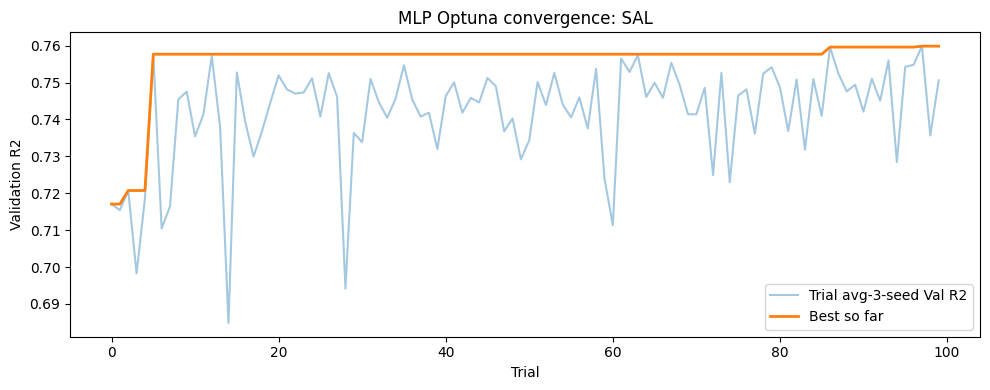

In [25]:
# CELL 19
# MLP model for next-season salary share with Optuna tuning and multi-seed training

from sklearn.neural_network import MLPRegressor

N_MLP_TRIALS_SAL = 100
MLP_SAL_PLOT_PATH = "mlp_optuna_sal.png"
FINAL_SEEDS = [42, 0, 1, 7, 13, 99, 123, 200, 314, 777]

X_train_sal = X_train_final.loc[mask_sal_train]
y_train_sal = y_sal_train.loc[mask_sal_train]

X_val_sal = X_val_final.loc[mask_sal_val]
y_val_sal = y_sal_val.loc[mask_sal_val]

X_test_sal = X_test_final.loc[mask_sal_test]
y_test_sal = y_sal_test.loc[mask_sal_test]

def mlp_objective_sal(trial):
    n_layers = trial.suggest_int("n_layers", 2, 4)
    layers = []

    for i in range(n_layers):
        max_units = max(16, 256 // (2 ** i))
        units = trial.suggest_int(f"units_l{i}", 16, max_units, step=16)
        layers.append(units)

    params = {
        "hidden_layer_sizes": tuple(layers),
        "alpha": trial.suggest_float("alpha", 5e-4, 0.1, log=True),
        "learning_rate_init": trial.suggest_float("learning_rate_init", 5e-4, 1e-2, log=True),
        "batch_size": trial.suggest_categorical("batch_size", [16, 32, 64]),
        "solver": "adam",
        "learning_rate": "adaptive",
        "max_iter": 700,
        "early_stopping": True,
        "validation_fraction": 0.10,
        "n_iter_no_change": 30,
    }

    r2_seeds = []

    for seed in [42, 123, 7]:
        model = MLPRegressor(random_state=seed, **params)
        model.fit(X_train_sal, y_train_sal)
        r2_seeds.append(r2_score(y_val_sal, model.predict(X_val_sal)))

    return float(np.mean(r2_seeds))

print(f"Optimizing MLP for SAL with Optuna ({N_MLP_TRIALS_SAL} trials, 3 seeds/trial)")

study_mlp_sal = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
)

study_mlp_sal.optimize(
    mlp_objective_sal,
    n_trials=N_MLP_TRIALS_SAL,
    show_progress_bar=True,
)

print(f"\nBest MLP SAL avg Val R2: {study_mlp_sal.best_value:.4f}")
print("Best MLP SAL params:")
for key, value in study_mlp_sal.best_params.items():
    print(f"  {key}: {value}")

best_trial_params = study_mlp_sal.best_params
n_layers_best = best_trial_params["n_layers"]
best_arch = tuple(best_trial_params[f"units_l{i}"] for i in range(n_layers_best))

best_mlp_base_sal = {
    "hidden_layer_sizes": best_arch,
    "alpha": best_trial_params["alpha"],
    "learning_rate_init": best_trial_params["learning_rate_init"],
    "batch_size": best_trial_params["batch_size"],
    "solver": "adam",
    "learning_rate": "adaptive",
    "max_iter": 800,
    "early_stopping": True,
    "validation_fraction": 0.10,
    "n_iter_no_change": 30,
}

print("\nFinal fit with 10 seeds")

best_val_r2_final = -np.inf
best_mlp_model_sal = None

for seed in FINAL_SEEDS:
    model = MLPRegressor(random_state=seed, **best_mlp_base_sal)
    model.fit(X_train_sal, y_train_sal)

    val_r2 = r2_score(y_val_sal, model.predict(X_val_sal))
    print(f"  seed={seed:4d}  Val R2={val_r2:.4f}  iters={model.n_iter_}")

    if val_r2 > best_val_r2_final:
        best_val_r2_final = val_r2
        best_mlp_model_sal = model

print(f"\nBest individual seed Val R2: {best_val_r2_final:.4f}")

mlp_sal = best_mlp_model_sal

print("\nMLP_SAL_PCA")

res_mlp_sal = pd.DataFrame([
    evaluate("TRAIN", y_train_sal, mlp_sal.predict(X_train_sal), "SAL"),
    evaluate("VAL",   y_val_sal,   mlp_sal.predict(X_val_sal),   "SAL"),
    evaluate("TEST",  y_test_sal,  mlp_sal.predict(X_test_sal),  "SAL"),
]).assign(model="MLP_SAL_PCA")

all_results.append(res_mlp_sal)

trials_r2 = [trial.value for trial in study_mlp_sal.trials if trial.value is not None]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(trials_r2, alpha=0.4, label="Trial avg-3-seed Val R2")
ax.plot(pd.Series(trials_r2).cummax(), linewidth=2, label="Best so far")
ax.set_xlabel("Trial")
ax.set_ylabel("Validation R2")
ax.set_title("MLP Optuna convergence: SAL")
ax.legend()

plt.tight_layout()
plt.savefig(MLP_SAL_PLOT_PATH, dpi=150, bbox_inches="tight")
plt.show()

RESULTS — salary_share_(t+1) PREDICTION  [Unified pipeline · PCA only]
  Tuning: Ridge/EN -> manual grid | XGB/LGBM/MLP -> Optuna
             model split     R2    MAE   RMSE  MAE_M
   Persistence_SAL   VAL 0.6950 0.0234 0.0498 2.5763
   Persistence_SAL  TEST 0.7601 0.0229 0.0458 2.9672
     Ridge_SAL_PCA TRAIN 0.7423 0.0295 0.0424 1.9838
     Ridge_SAL_PCA   VAL 0.7406 0.0311 0.0460 3.4311
     Ridge_SAL_PCA  TEST 0.8031 0.0299 0.0415 3.8761
ElasticNet_SAL_PCA TRAIN 0.7423 0.0296 0.0424 1.9856
ElasticNet_SAL_PCA   VAL 0.7407 0.0312 0.0460 3.4377
ElasticNet_SAL_PCA  TEST 0.8031 0.0299 0.0415 3.8760
   XGBoost_SAL_PCA TRAIN 0.9078 0.0186 0.0253 1.2527
   XGBoost_SAL_PCA   VAL 0.7494 0.0322 0.0452 3.5483
   XGBoost_SAL_PCA  TEST 0.7716 0.0338 0.0446 4.3913
  LightGBM_SAL_PCA TRAIN 0.8491 0.0235 0.0324 1.5793
  LightGBM_SAL_PCA   VAL 0.7471 0.0322 0.0454 3.5541
  LightGBM_SAL_PCA  TEST 0.7883 0.0324 0.0430 4.2005
       MLP_SAL_PCA TRAIN 0.7697 0.0281 0.0401 1.8865
       MLP_SAL_PCA   V

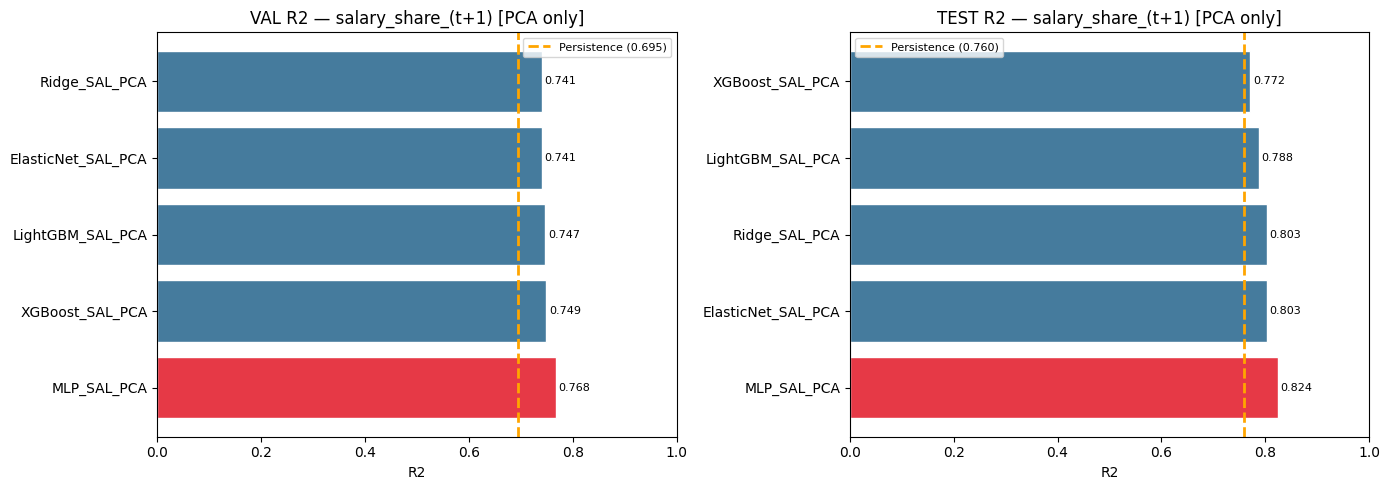

In [26]:
# CELL 20
# Summarize salary-share model results

results_sal = pd.concat(all_results, ignore_index=True)
results_sal = results_sal[results_sal["target"] == "SAL"].copy()

print("=" * 82)
print("RESULTS — salary_share_(t+1) PREDICTION  [Unified pipeline · PCA only]")
print("  Tuning: Ridge/EN -> manual grid | XGB/LGBM/MLP -> Optuna")
print("=" * 82)
print(results_sal[["model", "split", "R2", "MAE", "RMSE", "MAE_M"]].round(5).to_string(index=False))

# Validation ranking
print("\nValidation ranking by R2:")
val_sal = (
    results_sal[results_sal["split"] == "VAL"]
    .sort_values("R2", ascending=False)
    .reset_index(drop=True)
)
print(val_sal[["model", "R2", "MAE", "RMSE", "MAE_M"]].round(5).to_string(index=False))

# Persistence comparison
persist_row_val = results_sal[
    (results_sal["model"] == "Persistence_SAL") &
    (results_sal["split"] == "VAL")
].iloc[0]

persist_row_test = results_sal[
    (results_sal["model"] == "Persistence_SAL") &
    (results_sal["split"] == "TEST")
].iloc[0]

persist_val_r2 = persist_row_val["R2"]
persist_test_r2 = persist_row_test["R2"]
persist_val_maem = persist_row_val["MAE_M"]
persist_test_maem = persist_row_test["MAE_M"]

val_sal_ml = val_sal[val_sal["model"] != "Persistence_SAL"].reset_index(drop=True)

best_model_name = val_sal_ml.iloc[0]["model"]
best_val_r2 = val_sal_ml.iloc[0]["R2"]

best_row_test = results_sal[
    (results_sal["model"] == best_model_name) &
    (results_sal["split"] == "TEST")
].iloc[0]

best_test_r2 = best_row_test["R2"]
best_test_maem = best_row_test["MAE_M"]

print("\nPersistence comparison:")
print(f"  Persistence baseline           — Val R2: {persist_val_r2:.4f}  |  Test R2: {persist_test_r2:.4f}  |  Test MAE: ${persist_test_maem:.2f}M")
print(f"  Best ML ({best_model_name:20s}) — Val R2: {best_val_r2:.4f}  |  Test R2: {best_test_r2:.4f}  |  Test MAE: ${best_test_maem:.2f}M")
print(f"  Improvement over baseline      — Val: {best_val_r2 - persist_val_r2:+.4f}  |  Test: {best_test_r2 - persist_test_r2:+.4f}")
print(f"\nBest VAL model: {best_model_name}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for split_name, ax in zip(["VAL", "TEST"], axes):
    sub = results_sal[
        (results_sal["split"] == split_name) &
        (results_sal["model"] != "Persistence_SAL")
    ].sort_values("R2", ascending=False)

    colors = ["#e63946" if m == best_model_name else "#457b9d" for m in sub["model"]]
    bars = ax.barh(sub["model"], sub["R2"], color=colors, edgecolor="white")

    persist_r2 = persist_val_r2 if split_name == "VAL" else persist_test_r2

    ax.axvline(
        persist_r2,
        color="orange",
        linestyle="--",
        linewidth=2,
        label=f"Persistence ({persist_r2:.3f})",
    )

    ax.set_xlabel("R2")
    ax.set_title(f"{split_name} R2 — salary_share_(t+1) [PCA only]")
    ax.set_xlim(0, max(1.0, sub["R2"].max() * 1.1))
    ax.legend(fontsize=8)

    for bar, val in zip(bars, sub["R2"]):
        ax.text(
            bar.get_width() + 0.005,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}",
            va="center",
            fontsize=8,
        )

plt.tight_layout()
plt.savefig("sal_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

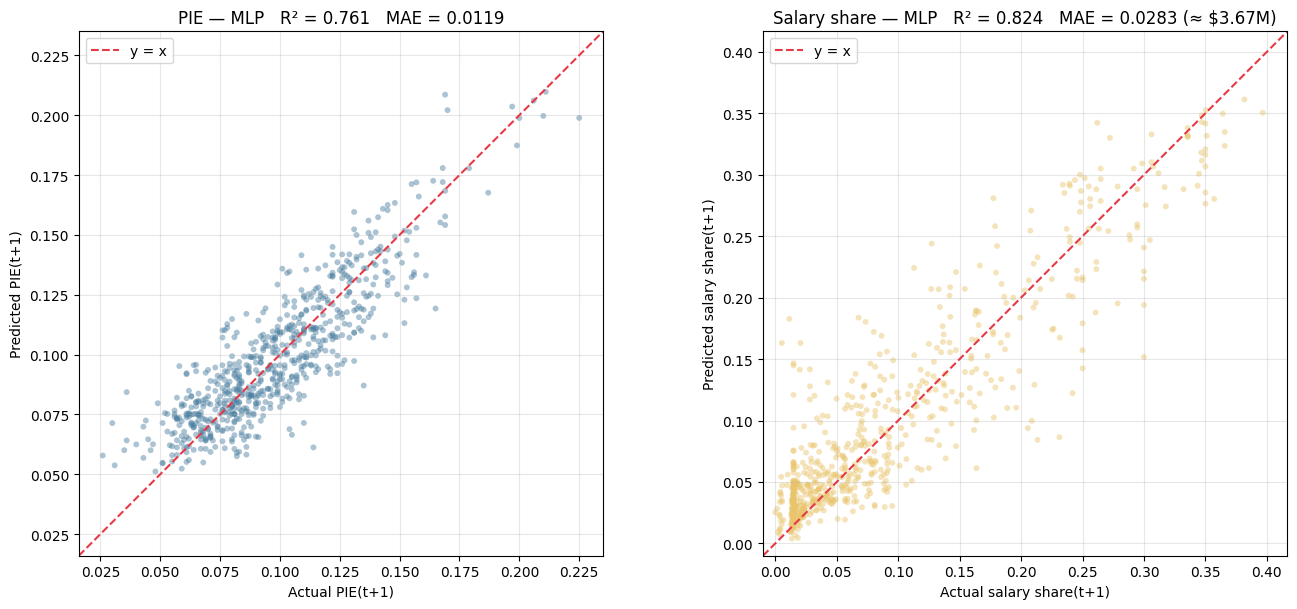

PIE  — R²: 0.7614   MAE: 0.01186
SAL  — R²: 0.8241   MAE: 0.02827   MAE_M$: 3.67


In [29]:
# CELL 21 — FIGURE: predicted-vs-actual scatter for the best model on each target.
# Two panels: PIE (left) and cap-adjusted salary share (right).

# Generate test predictions from the best MLP models
pred_pie_mlp = mlp_pie.predict(X_test_pie)
pred_sal_mlp = mlp_sal.predict(X_test_sal)

# Identify best predictions on TEST
best_pie_pred = pred_pie_mlp     # MLP_PIE (best by test R2)
best_sal_pred = pred_sal_mlp     # MLP_SAL (best by test R2)

r2_pie  = r2_score(y_pie_test, best_pie_pred)
mae_pie = mean_absolute_error(y_pie_test, best_pie_pred)
r2_sal  = r2_score(y_sal_test, best_sal_pred)
mae_sal = mean_absolute_error(y_sal_test, best_sal_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 6.2))

# Panel 1 — PIE
ax = axes[0]
ax.scatter(y_pie_test, best_pie_pred,
           s=18, alpha=0.45, color="#457b9d", edgecolor="none")
lim_min = min(y_pie_test.min(), best_pie_pred.min()) - 0.01
lim_max = max(y_pie_test.max(), best_pie_pred.max()) + 0.01
ax.plot([lim_min, lim_max], [lim_min, lim_max],
        color="#e63946", linestyle="--", linewidth=1.5, label="y = x")
ax.set_xlim(lim_min, lim_max)
ax.set_ylim(lim_min, lim_max)
ax.set_xlabel("Actual PIE(t+1)")
ax.set_ylabel("Predicted PIE(t+1)")
ax.set_title(f"PIE — MLP   R² = {r2_pie:.3f}   MAE = {mae_pie:.4f}",
             fontsize=12)
ax.grid(alpha=0.3)
ax.legend(loc="upper left", fontsize=10)
ax.set_aspect("equal", adjustable="box")

# Panel 2 — Salary share
ax = axes[1]
ax.scatter(y_sal_test, best_sal_pred,
           s=18, alpha=0.45, color="#e9c46a", edgecolor="none")
lim_min = min(y_sal_test.min(), best_sal_pred.min()) - 0.01
lim_max = max(y_sal_test.max(), best_sal_pred.max()) + 0.02
ax.plot([lim_min, lim_max], [lim_min, lim_max],
        color="#e63946", linestyle="--", linewidth=1.5, label="y = x")
ax.set_xlim(lim_min, lim_max)
ax.set_ylim(lim_min, lim_max)
ax.set_xlabel("Actual salary share(t+1)")
ax.set_ylabel("Predicted salary share(t+1)")
mae_sal_million = mae_sal * df_model.loc[idx_test, "SALARY_CAP"].mean() / 1e6
ax.set_title(
    f"Salary share — MLP   R² = {r2_sal:.3f}   MAE = {mae_sal:.4f} "
    f"(≈ ${mae_sal_million:.2f}M)",
    fontsize=12,
)
ax.grid(alpha=0.3)
ax.legend(loc="upper left", fontsize=10)
ax.set_aspect("equal", adjustable="box")

plt.tight_layout()
plt.savefig("predicted_vs_actual_PIE_SAL.pdf", bbox_inches="tight")
plt.savefig("predicted_vs_actual_PIE_SAL.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"PIE  — R²: {r2_pie:.4f}   MAE: {mae_pie:.5f}")
print(f"SAL  — R²: {r2_sal:.4f}   MAE: {mae_sal:.5f}   "
      f"MAE_M$: {mae_sal_million:.2f}")

# ERROR ANALYSIS AND INTERPRETABILITY

In [30]:
# CELL 22
# UMAP hyperparameter search and best-K selection by silhouette.
# This cell explores 96 UMAP configurations on Z_train and identifies the winning combination (n_components, n_neighbors, min_dist, K)

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

N_COMPONENTS_GRID = [2, 3, 4]
N_NEIGHBORS_GRID  = [15, 20, 25, 30, 35, 40, 45, 50]
MIN_DIST_GRID     = [0.00, 0.05, 0.10, 0.20]
K_RANGE           = range(6, 15)
SILHOUETTE_SAMPLE = 2000

print("Running UMAP grid search for archetype discovery...\n")

rows = []
for n_components, n_neighbors, min_dist in product(
    N_COMPONENTS_GRID, N_NEIGHBORS_GRID, MIN_DIST_GRID
):
    reducer_grid = umap.UMAP(
        n_components=n_components,
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        metric="euclidean",
        random_state=RANDOM_STATE,
        n_jobs=1,  
    )
    U_train_grid = reducer_grid.fit_transform(Z_train)

    best_k, best_sil = None, -np.inf
    for k in K_RANGE:
        km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
        labels_k = km.fit_predict(U_train_grid)
        sil = silhouette_score(
            U_train_grid, labels_k,
            sample_size=min(SILHOUETTE_SAMPLE, len(U_train_grid)),
            random_state=RANDOM_STATE,
        )
        if sil > best_sil:
            best_sil, best_k = sil, k

    rows.append({
        "n_components":    n_components,
        "n_neighbors":     n_neighbors,
        "min_dist":        min_dist,
        "best_k":          best_k,
        "best_silhouette": best_sil,
    })

    print(
        f"n_comp={n_components} | n_neighbors={n_neighbors:2d} | "
        f"min_dist={min_dist:>4.2f} -> best_k={best_k:2d} | sil={best_sil:.4f}"
    )

umap_search_df = (
    pd.DataFrame(rows)
      .sort_values(
          ["best_silhouette", "n_components", "n_neighbors", "min_dist"],
          ascending=[False, True, True, True],
      )
      .reset_index(drop=True)
)

print("\nTop 10 UMAP configurations by silhouette:")
print(umap_search_df.head(10).round(4).to_string(index=False))

best_cfg = umap_search_df.iloc[0].to_dict()
print("\nBest overall configuration:")
print({k: round(v, 4) if isinstance(v, float) else v for k, v in best_cfg.items()})

# Aggregated views: best silhouette per single-axis slice of the grid.
summary_n_components = (
    umap_search_df.loc[
        umap_search_df.groupby("n_components")["best_silhouette"].idxmax(),
        ["n_components", "best_k", "best_silhouette", "n_neighbors", "min_dist"],
    ]
    .sort_values("n_components")
    .reset_index(drop=True)
)
summary_n_neighbors = (
    umap_search_df.loc[
        umap_search_df.groupby("n_neighbors")["best_silhouette"].idxmax(),
        ["n_neighbors", "best_k", "best_silhouette", "n_components", "min_dist"],
    ]
    .sort_values("n_neighbors")
    .reset_index(drop=True)
)
summary_min_dist = (
    umap_search_df.loc[
        umap_search_df.groupby("min_dist")["best_silhouette"].idxmax(),
        ["min_dist", "best_k", "best_silhouette", "n_components", "n_neighbors"],
    ]
    .sort_values("min_dist")
    .reset_index(drop=True)
)

print("\nBest K by n_components:")
print(summary_n_components.round(4).to_string(index=False))

print("\nBest K by n_neighbors:")
print(summary_n_neighbors.round(4).to_string(index=False))

print("\nBest K by min_dist:")
print(summary_min_dist.round(4).to_string(index=False))

Running UMAP grid search for archetype discovery...

n_comp=2 | n_neighbors=15 | min_dist=0.00 -> best_k= 7 | sil=0.4355
n_comp=2 | n_neighbors=15 | min_dist=0.05 -> best_k= 7 | sil=0.4223
n_comp=2 | n_neighbors=15 | min_dist=0.10 -> best_k= 6 | sil=0.4202
n_comp=2 | n_neighbors=15 | min_dist=0.20 -> best_k= 6 | sil=0.4022
n_comp=2 | n_neighbors=20 | min_dist=0.00 -> best_k= 6 | sil=0.4366
n_comp=2 | n_neighbors=20 | min_dist=0.05 -> best_k= 6 | sil=0.4205
n_comp=2 | n_neighbors=20 | min_dist=0.10 -> best_k= 6 | sil=0.4114
n_comp=2 | n_neighbors=20 | min_dist=0.20 -> best_k= 6 | sil=0.3999
n_comp=2 | n_neighbors=25 | min_dist=0.00 -> best_k= 6 | sil=0.4406
n_comp=2 | n_neighbors=25 | min_dist=0.05 -> best_k= 9 | sil=0.4237
n_comp=2 | n_neighbors=25 | min_dist=0.10 -> best_k= 9 | sil=0.4118
n_comp=2 | n_neighbors=25 | min_dist=0.20 -> best_k= 6 | sil=0.4014
n_comp=2 | n_neighbors=30 | min_dist=0.00 -> best_k= 6 | sil=0.4372
n_comp=2 | n_neighbors=30 | min_dist=0.05 -> best_k= 9 | sil=0.

### Block A — Archetype construction over PCA

Fitting UMAP with the selected configuration...
  n_components=2, n_neighbors=40, min_dist=0.0, K=7
UMAP shapes  train: (4237, 2)  val: (985, 2)  test: (668, 2)
  K= 5  silhouette=0.4484
  K= 6  silhouette=0.4651
  K= 7  silhouette=0.4666
  K= 8  silhouette=0.4648
  K= 9  silhouette=0.4288
  K=10  silhouette=0.4132
  K=11  silhouette=0.4017
  K=12  silhouette=0.4092
  K=13  silhouette=0.4022
  K=14  silhouette=0.3987


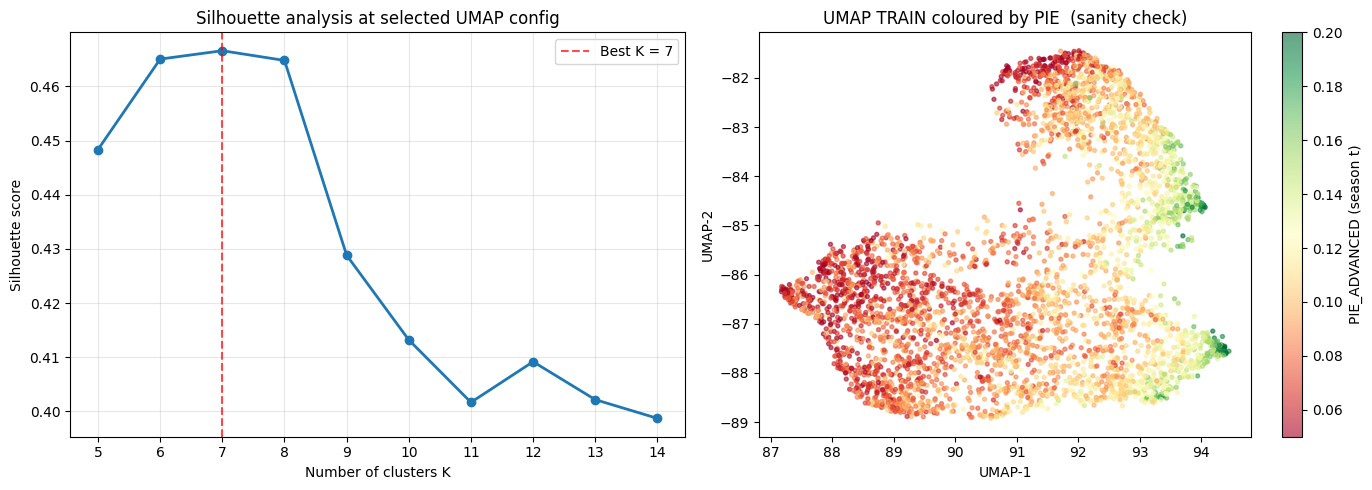

In [31]:
# CELL 23
# UMAP fit with the configuration selected in CELL X, plus a silhouette diagnostic at that configuration and a sanity-check visualisation of the embedding coloured by PIE.
#  UMAP and KMeans are fit ONLY on Z_train; 
# val and test embeddings come from the fitted reducer's .transform().
# Cluster labels are used only as a stratification dimension for error analysis (Block B/C), not as features for the supervised models.

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import umap.umap_ as umap

# Winning configuration
BEST_N_COMPONENTS = 2
BEST_N_NEIGHBORS  = 40
BEST_MIN_DIST     = 0.0
BEST_K            = 7

K_RANGE           = range(5, 15)
SILHOUETTE_SAMPLE = 2000

print("Fitting UMAP with the selected configuration...")
print(f"  n_components={BEST_N_COMPONENTS}, n_neighbors={BEST_N_NEIGHBORS}, "
      f"min_dist={BEST_MIN_DIST}, K={BEST_K}")

reducer = umap.UMAP(
    n_components=BEST_N_COMPONENTS,
    n_neighbors=BEST_N_NEIGHBORS,
    min_dist=BEST_MIN_DIST,
    metric="euclidean",
    random_state=RANDOM_STATE,
    n_jobs=1,
)
U_train = reducer.fit_transform(Z_train)
U_val   = reducer.transform(Z_val)
U_test  = reducer.transform(Z_test)

print(f"UMAP shapes  train: {U_train.shape}  val: {U_val.shape}  test: {U_test.shape}")

# Silhouette diagnostic at the selected configuration
sil_scores = {}
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    sil_scores[k] = silhouette_score(
        U_train, km.fit_predict(U_train),
        sample_size=min(SILHOUETTE_SAMPLE, len(U_train)),
        random_state=RANDOM_STATE,
    )
    print(f"  K={k:2d}  silhouette={sil_scores[k]:.4f}")

assert max(sil_scores, key=sil_scores.get) == BEST_K, (
    f"BEST_K={BEST_K} is not the silhouette-maximising K at the selected "
    f"UMAP configuration. Re-run CELL X to confirm."
)

# Visual: silhouette curve + UMAP coloured by PIE (sanity check)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(sil_scores.keys()), list(sil_scores.values()),
             "o-", color="#1f77b4", linewidth=2)
axes[0].axvline(BEST_K, color="red", linestyle="--", alpha=0.7,
                label=f"Best K = {BEST_K}")
axes[0].set_xlabel("Number of clusters K")
axes[0].set_ylabel("Silhouette score")
axes[0].set_title("Silhouette analysis at selected UMAP config")
axes[0].set_xticks(list(K_RANGE))
axes[0].legend()
axes[0].grid(alpha=0.3)

sc = axes[1].scatter(
    U_train[:, 0], U_train[:, 1],
    c=df_model.loc[idx_train, "PIE_ADVANCED"].values,
    cmap="RdYlGn", s=8, alpha=0.6, vmin=0.05, vmax=0.20,
)
plt.colorbar(sc, ax=axes[1], label="PIE_ADVANCED (season t)")
axes[1].set_title("UMAP TRAIN coloured by PIE  (sanity check)")
axes[1].set_xlabel("UMAP-1")
axes[1].set_ylabel("UMAP-2")

plt.tight_layout()
plt.savefig("archetype_silhouette_umap.png", dpi=150, bbox_inches="tight")
plt.show()

Cluster sizes per split:
  Train: {0: 527, 1: 551, 2: 410, 3: 764, 4: 684, 5: 802, 6: 499}
  Val:   {0: 153, 1: 90, 2: 129, 3: 196, 4: 177, 5: 116, 6: 124}
  Test:  {0: 105, 1: 65, 2: 86, 3: 121, 4: 140, 5: 80, 6: 71}


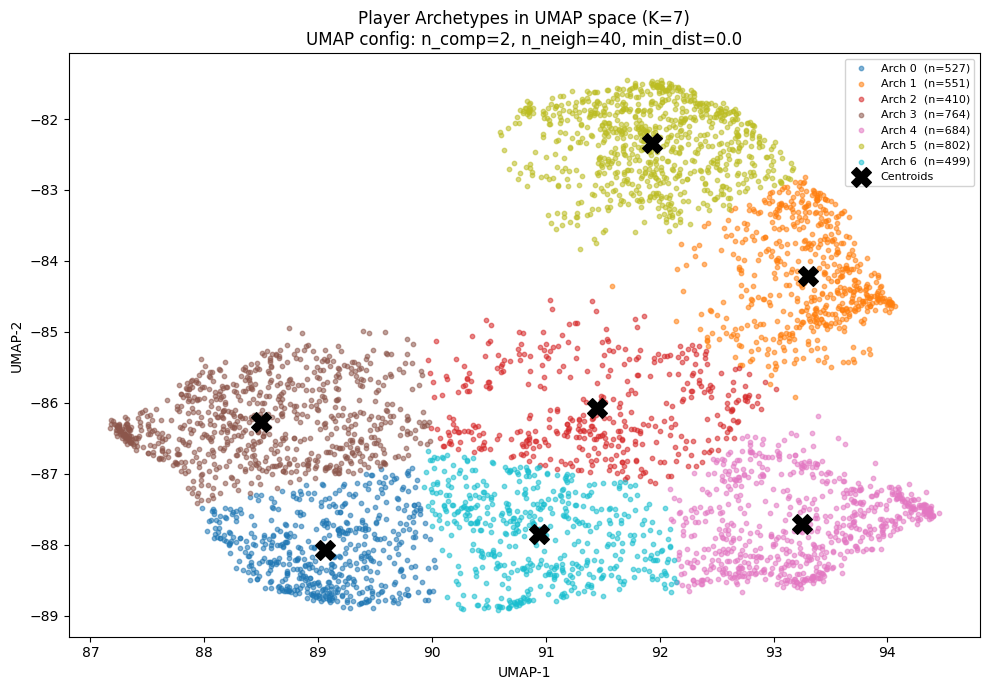

In [32]:
# CELL 24
# Final KMeans with BEST_K and label assignment to all splits.
# KMeans is fit on U_train only; val and test labels come from .predict().

km_umap = KMeans(n_clusters=BEST_K, random_state=RANDOM_STATE, n_init=50)
km_umap.fit(U_train)

labels_train = km_umap.predict(U_train)
labels_val   = km_umap.predict(U_val)
labels_test  = km_umap.predict(U_test)

def _counts(labels):
    keys, vals = np.unique(labels, return_counts=True)
    return {int(k): int(v) for k, v in zip(keys, vals)}

print("Cluster sizes per split:")
print(f"  Train: {_counts(labels_train)}")
print(f"  Val:   {_counts(labels_val)}")
print(f"  Test:  {_counts(labels_test)}")

# Attach cluster labels to df_model for stratified analyses
df_model_with_arch = df_model.copy()
df_model_with_arch["archetype"] = -1
df_model_with_arch.loc[idx_train, "archetype"] = labels_train
df_model_with_arch.loc[idx_val,   "archetype"] = labels_val
df_model_with_arch.loc[idx_test,  "archetype"] = labels_test

assert (df_model_with_arch["archetype"] >= 0).all(), \
    "Some rows did not receive a cluster label"

# Visualize archetypes in the (first 2 dims of) UMAP space
U_train_2d = U_train[:, :2]
centers_2d = km_umap.cluster_centers_[:, :2]

fig, ax = plt.subplots(figsize=(10, 7))
palette = plt.cm.tab10(np.linspace(0, 1, BEST_K))

for k in range(BEST_K):
    mask = labels_train == k
    ax.scatter(
        U_train_2d[mask, 0], U_train_2d[mask, 1],
        s=10, alpha=0.55, color=palette[k],
        label=f"Arch {k}  (n={mask.sum()})",
    )

ax.scatter(
    centers_2d[:, 0], centers_2d[:, 1],
    s=200, c="black", marker="X", zorder=5, label="Centroids",
)
ax.set_title(
    f"Player Archetypes in UMAP space (K={BEST_K})\n"
    f"UMAP config: n_comp={BEST_N_COMPONENTS}, "
    f"n_neigh={BEST_N_NEIGHBORS}, min_dist={BEST_MIN_DIST}"
)
ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")
ax.legend(fontsize=8, loc="best", framealpha=0.85)

plt.tight_layout()
plt.savefig("archetype_umap_clusters.png", dpi=150, bbox_inches="tight")
plt.show()

In [33]:
# CELL 25
# Archetype characterisation. For each cluster, compute the mean of a small set of interpretable raw stats from TRAIN. 
# The output table is the basis for naming each archetype qualitatively in the thesis.

PROFILE_COLS = [c for c in [
    "AGE_BASE", "GP_BASE", "MIN_BASE",
    "PTS_BASE", "AST_BASE", "REB_BASE",
    "OREB_BASE", "DREB_BASE",
    "STL_BASE", "BLK_BASE", "TOV_BASE",
    "FG3M_BASE", "FG3A_BASE",
    "USG_PCT_USAGE", "USG_PCT_ADVANCED",
    "TS_PCT_ADVANCED", "EFG_PCT_ADVANCED",
    "AST_PCT_ADVANCED", "REB_PCT_ADVANCED",
    "DREB_PCT_ADVANCED", "OREB_PCT_ADVANCED",
    "PIE_ADVANCED",
    "salary_share",
] if c in df_model.columns]

print(f"Profiling archetypes with {len(PROFILE_COLS)} interpretable stats")

train_with_arch = df_model_with_arch[idx_train].copy()

ARCHETYPE_PROFILE = train_with_arch.groupby("archetype")[PROFILE_COLS].mean().round(3)
ARCHETYPE_PROFILE.insert(0, "n_players", train_with_arch.groupby("archetype").size())

print("\nArchetype profiles (TRAIN means):")
print(ARCHETYPE_PROFILE.to_string())

print(f"\nProfile table stored as ARCHETYPE_PROFILE  (K={BEST_K})")
print("Cluster labels stored in df_model_with_arch['archetype']")

Profiling archetypes with 23 interpretable stats

Archetype profiles (TRAIN means):
           n_players  AGE_BASE  GP_BASE  MIN_BASE  PTS_BASE  AST_BASE  REB_BASE  OREB_BASE  DREB_BASE  STL_BASE  BLK_BASE  TOV_BASE  FG3M_BASE  FG3A_BASE  USG_PCT_USAGE  USG_PCT_ADVANCED  TS_PCT_ADVANCED  EFG_PCT_ADVANCED  AST_PCT_ADVANCED  REB_PCT_ADVANCED  DREB_PCT_ADVANCED  OREB_PCT_ADVANCED  PIE_ADVANCED  salary_share
archetype                                                                                                                                                                                                                                                                                                                          
0                527   28.7950  69.4550   22.9490    8.0210    1.7170    2.8270     0.4960     2.3350    0.6850    0.2760    0.8990     1.3010     3.4000         0.1600            0.1600           0.5480            0.5210            0.1150            0.0630           

In [34]:
# CELL 26
# Archetype labels summary table for K=7.

ARCHETYPE_NAMES = {
    0: "Backup Wings / Bench Scorers",
    1: "Traditional Bigs / Rim Protectors",
    2: "Stretch Forwards / Two-Way Wings",
    3: "Deep Bench / Young Reserves",
    4: "Primary Stars / Franchise Players",
    5: "Glue Bigs / Defensive Reserves",
    6: "Veteran Floor Spacers / Combo Guards",
}

def build_profile_string(row):
    parts = [
        f"{row['MIN_BASE']:.0f} min",
    ]
    if row["PTS_BASE"] >= 12.0:
        parts.append(f"{row['PTS_BASE']:.1f} PTS")
    if row["REB_BASE"] >= 6.0:
        parts.append(f"{row['REB_BASE']:.1f} REB")
    if row["AST_BASE"] >= 3.0:
        parts.append(f"{row['AST_BASE']:.1f} AST")
    if row["FG3M_BASE"] >= 1.0:
        parts.append(f"{row['FG3M_BASE']:.1f} 3PM")
    if row["BLK_BASE"] >= 1.0:
        parts.append(f"{row['BLK_BASE']:.1f} BLK")
    if row["USG_PCT_USAGE"] >= 0.22:
        parts.append(f"USG {row['USG_PCT_USAGE']*100:.0f}")
    if row["AGE_BASE"] >= 28.0 or row["AGE_BASE"] <= 25.5:
        parts.append(f"age {row['AGE_BASE']:.1f}")
    parts.append(f"sal {row['salary_share']*100:.1f}%")
    return " · ".join(parts)

# Build the summary table (one row per archetype, ordered by cluster index)
ARCHETYPE_SUMMARY = ARCHETYPE_PROFILE.copy()
ARCHETYPE_SUMMARY["proposed_name"] = ARCHETYPE_SUMMARY.index.map(ARCHETYPE_NAMES)
ARCHETYPE_SUMMARY["profile"] = ARCHETYPE_SUMMARY.apply(build_profile_string, axis=1)

# Test-set sample size per archetype (for sanity check on minimum n)
arch_test_counts = (
    df_model_with_arch.loc[idx_test, "archetype"]
    .value_counts()
    .sort_index()
    .to_dict()
)
ARCHETYPE_SUMMARY["n_test"] = ARCHETYPE_SUMMARY.index.map(arch_test_counts)

# Re-order columns for the thesis-style summary
SUMMARY_COLS = ["n_players", "n_test", "profile", "proposed_name"]
ARCHETYPE_SUMMARY_TABLE = ARCHETYPE_SUMMARY[SUMMARY_COLS].rename(
    columns={"n_players": "n_train"}
)

print("=" * 90)
print(f"ARCHETYPE SUMMARY (K={BEST_K})")
print("=" * 90)
print(ARCHETYPE_SUMMARY_TABLE.to_string())

print(f"\nTrain cluster sizes: {sorted(ARCHETYPE_SUMMARY_TABLE['n_train'].tolist())}")
print(f"Test  cluster sizes: {sorted(ARCHETYPE_SUMMARY_TABLE['n_test'].tolist())}")
print(f"Min TEST n per archetype: {min(arch_test_counts.values())}")
print(f"Silhouette at K={BEST_K}: {sil_scores[BEST_K]:.4f}")

ARCHETYPE SUMMARY (K=7)
           n_train  n_test                                                     profile                         proposed_name
archetype                                                                                                                   
0              527     105                      23 min · 1.3 3PM · age 28.8 · sal 6.0%          Backup Wings / Bench Scorers
1              551      65           31 min · 15.3 PTS · 8.9 REB · 1.2 BLK · sal 15.8%     Traditional Bigs / Rim Protectors
2              410      86                      29 min · 12.2 PTS · 1.1 3PM · sal 8.8%      Stretch Forwards / Two-Way Wings
3              764     121                                17 min · age 25.3 · sal 3.5%           Deep Bench / Young Reserves
4              684     140  34 min · 18.4 PTS · 5.3 AST · 1.4 3PM · USG 25 · sal 15.2%     Primary Stars / Franchise Players
5              802      80                                           18 min · sal 6.3%        Glue Bi

### Block B — Per-archetype error stratification

In [35]:
# CELL 27
# Per-archetype error metrics on TEST for three model families per target, plus a persistence baseline as reference.
# PIE: ElasticNet, LightGBM, MLP
# SAL: ElasticNet, XGBoost,  MLP
# Bias flag rule: |bias| > 0.5 * sigma_residual_global is marked with "*".

def label_arch(k):
    return f"{k}: {ARCHETYPE_NAMES.get(int(k), f'Arch_{k}')}"

def per_archetype_metrics(y_true, y_pred, archetypes, target_label, model_label):
    df_res = pd.DataFrame({
        "y_true":    np.asarray(y_true),
        "y_pred":    np.asarray(y_pred),
        "residual":  np.asarray(y_true) - np.asarray(y_pred),
        "archetype": np.asarray(archetypes),
    })
    sigma_global = df_res["residual"].std()
    rows = []
    for k in sorted(df_res["archetype"].unique()):
        sub = df_res[df_res["archetype"] == k]
        n = len(sub)
        rows.append({
            "target":     target_label,
            "model":      model_label,
            "archetype":  k,
            "arch_label": label_arch(k),
            "n":          n,
            "R2":         r2_score(sub["y_true"], sub["y_pred"]) if n >= 5 else np.nan,
            "MAE":        sub["residual"].abs().mean(),
            "RMSE":       np.sqrt((sub["residual"] ** 2).mean()),
            "bias":       sub["residual"].mean(),
            "bias_flag":  "*" if abs(sub["residual"].mean()) > 0.5 * sigma_global else "",
        })
    return pd.DataFrame(rows)

arch_test = df_model_with_arch.loc[idx_test, "archetype"].values

pred_pie_enet    = enet_pie.predict(X_test_final)
pred_pie_lgbm    = lgbm_pie.predict(X_test_final, num_iteration=lgbm_pie.best_iteration_)
pred_pie_mlp     = mlp_pie.predict(X_test_final)
pred_pie_persist = df_model.loc[idx_test, "PIE_ADVANCED"].values

pred_sal_enet    = enet_sal.predict(X_test_final)
pred_sal_xgb     = xgb_sal.predict(X_test_final)
pred_sal_mlp     = mlp_sal.predict(X_test_final)
pred_sal_persist = df_model.loc[idx_test, "salary_share"].values

MODELS_PIE = [
    ("Persistence_PIE", pred_pie_persist),
    ("ElasticNet_PIE",  pred_pie_enet),
    ("LightGBM_PIE",    pred_pie_lgbm),
    ("MLP_PIE",         pred_pie_mlp),
]
MODELS_SAL = [
    ("Persistence_SAL", pred_sal_persist),
    ("ElasticNet_SAL",  pred_sal_enet),
    ("XGBoost_SAL",     pred_sal_xgb),
    ("MLP_SAL",         pred_sal_mlp),
]

# Long-format metrics table
all_arch_metrics = []
for model_label, preds in MODELS_PIE:
    all_arch_metrics.append(
        per_archetype_metrics(y_pie_test, preds, arch_test, "PIE", model_label)
    )
for model_label, preds in MODELS_SAL:
    all_arch_metrics.append(
        per_archetype_metrics(y_sal_test, preds, arch_test, "SAL", model_label)
    )
arch_metrics = pd.concat(all_arch_metrics, ignore_index=True)

# Cross-model R2 pivots
print("=" * 90)
print("PER-ARCHETYPE R2 on TEST  (cross-model comparison vs persistence)")
print("=" * 90)

col_order_pie = ["Persistence_PIE", "ElasticNet_PIE", "LightGBM_PIE", "MLP_PIE", "n_test"]
col_order_sal = ["Persistence_SAL", "ElasticNet_SAL", "XGBoost_SAL",  "MLP_SAL", "n_test"]

pie_pivot = arch_metrics[arch_metrics["target"] == "PIE"].pivot(
    index="arch_label", columns="model", values="R2"
).round(4)
pie_pivot["n_test"] = (
    arch_metrics[arch_metrics["target"] == "PIE"]
    .groupby("arch_label")["n"].first().values
)
pie_pivot = pie_pivot[col_order_pie].sort_values("MLP_PIE", ascending=False)
print("\nPIE")
print(pie_pivot.to_string())

sal_pivot = arch_metrics[arch_metrics["target"] == "SAL"].pivot(
    index="arch_label", columns="model", values="R2"
).round(4)
sal_pivot["n_test"] = (
    arch_metrics[arch_metrics["target"] == "SAL"]
    .groupby("arch_label")["n"].first().values
)
sal_pivot = sal_pivot[col_order_sal].sort_values("MLP_SAL", ascending=False)
print("\nSAL")
print(sal_pivot.to_string())

# improvement over persistence (best ML per target)
print("\n" + "=" * 90)
print("IMPROVEMENT OVER PERSISTENCE  (best ML model per target)")
print("=" * 90)

pie_lift = (pie_pivot["MLP_PIE"] - pie_pivot["Persistence_PIE"]).round(4)
pie_lift = pie_lift.sort_values(ascending=False).to_frame("delta_R2")
pie_lift["n_test"] = pie_pivot.loc[pie_lift.index, "n_test"]
print("\nPIE")
print(pie_lift.to_string())

sal_lift = (sal_pivot["MLP_SAL"] - sal_pivot["Persistence_SAL"]).round(4)
sal_lift = sal_lift.sort_values(ascending=False).to_frame("delta_R2")
sal_lift["n_test"] = sal_pivot.loc[sal_lift.index, "n_test"]
print("\nSAL")
print(sal_lift.to_string())

# bias pivots 
print("\n" + "=" * 90)
print("PER-ARCHETYPE BIAS on TEST  (positive => model underpredicts)")
print("=" * 90)

pie_bias = arch_metrics[arch_metrics["target"] == "PIE"].pivot(
    index="arch_label", columns="model", values="bias"
).round(5)[col_order_pie[:-1]]
print("\nPIE bias")
print(pie_bias.to_string())

sal_bias = arch_metrics[arch_metrics["target"] == "SAL"].pivot(
    index="arch_label", columns="model", values="bias"
).round(5)[col_order_sal[:-1]]
print("\nSAL bias")
print(sal_bias.to_string())

PER-ARCHETYPE R2 on TEST  (cross-model comparison vs persistence)

PIE
model                                    Persistence_PIE  ElasticNet_PIE  LightGBM_PIE  MLP_PIE  n_test
arch_label                                                                                             
1: Traditional Bigs / Rim Protectors              0.6859          0.7532        0.6877   0.7654      65
4: Primary Stars / Franchise Players              0.5493          0.6654        0.6316   0.6707     140
6: Veteran Floor Spacers / Combo Guards           0.4629          0.4281        0.3885   0.4596      71
2: Stretch Forwards / Two-Way Wings               0.3861          0.4574        0.3680   0.4589      86
5: Glue Bigs / Defensive Reserves                 0.4055          0.4089        0.2980   0.4095      80
0: Backup Wings / Bench Scorers                   0.3487          0.3999        0.3788   0.3984     105
3: Deep Bench / Young Reserves                    0.0623          0.3630        0.3501   0.3919  

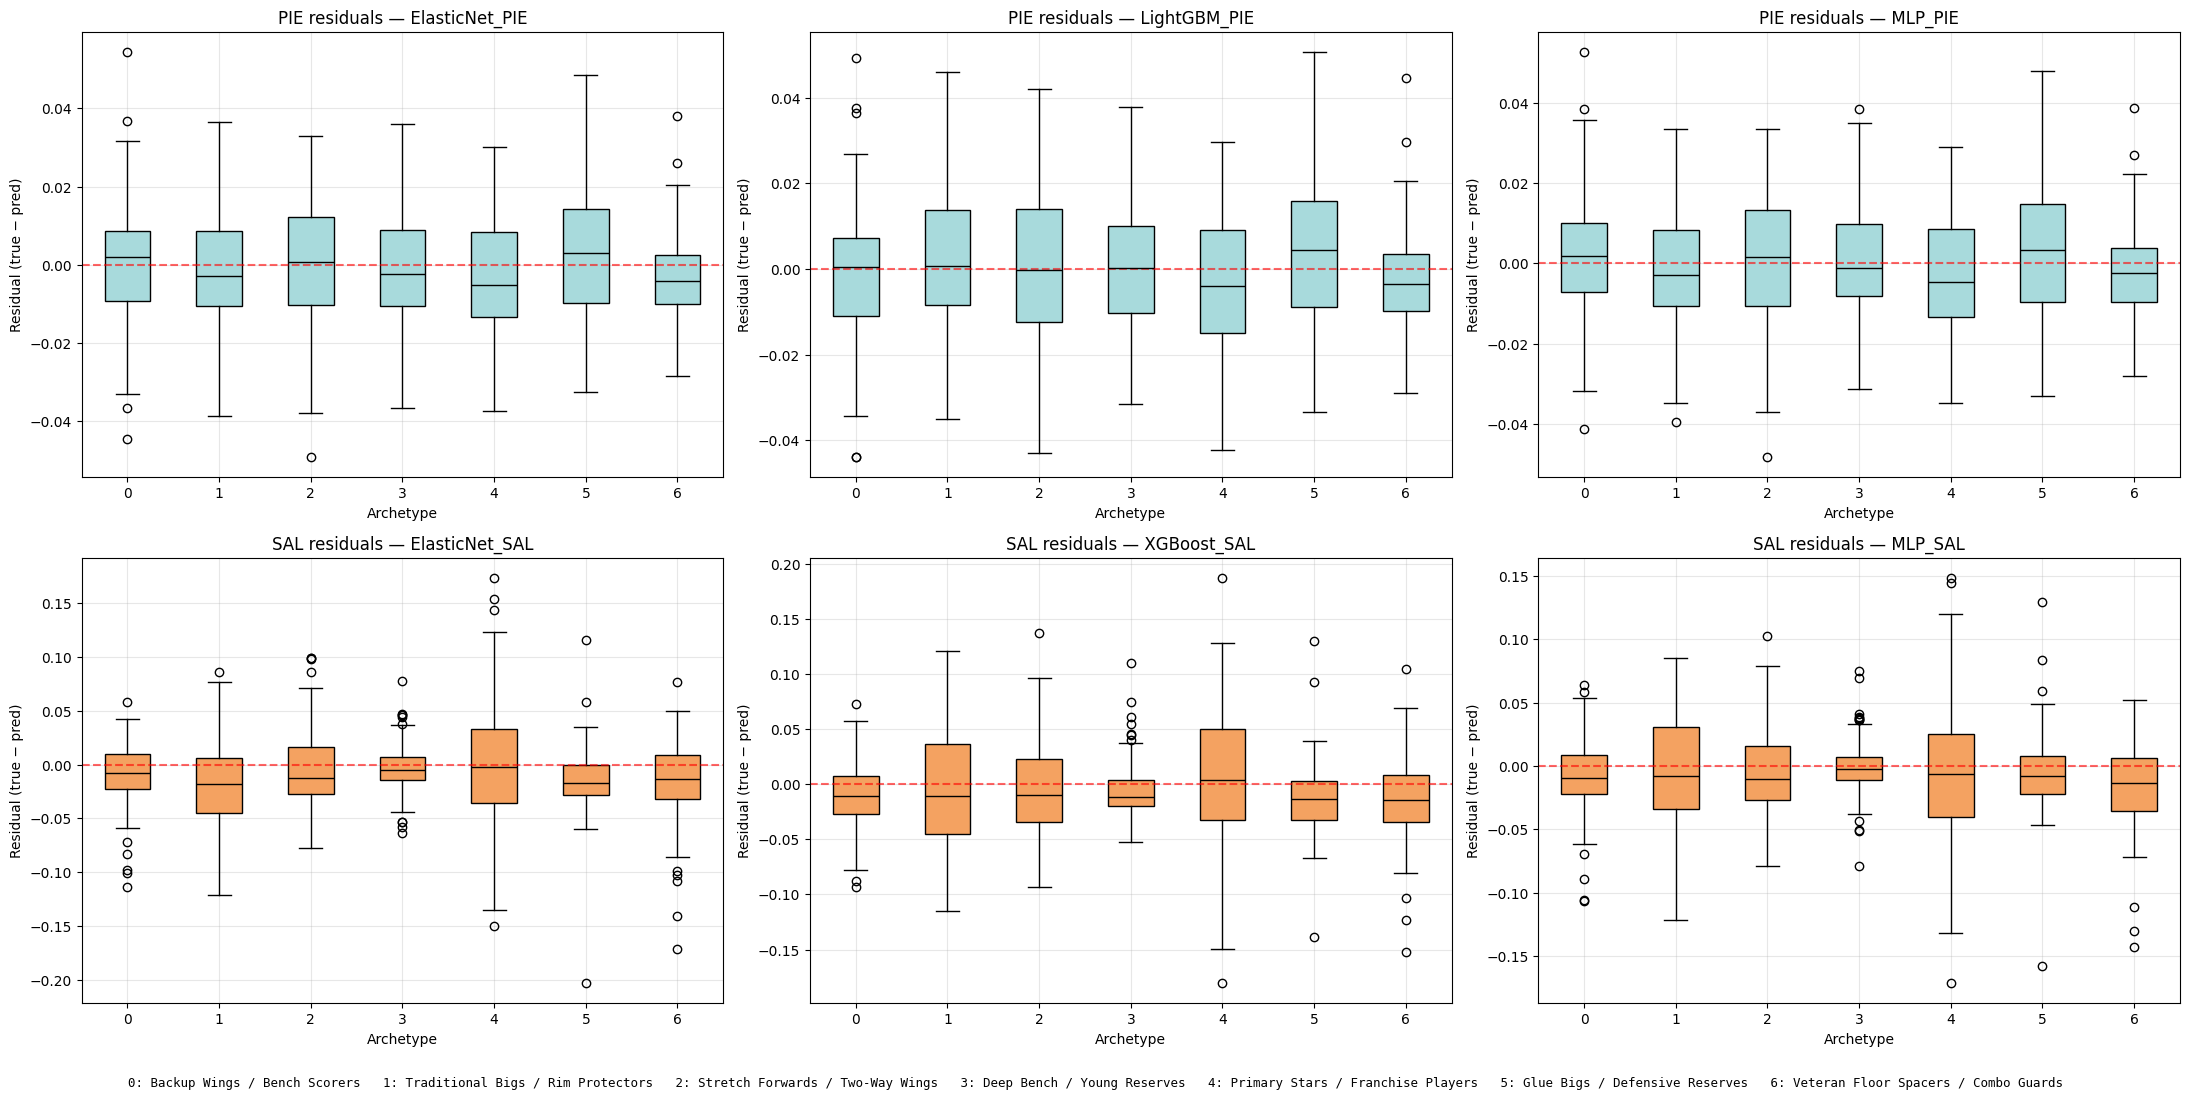

TOP-5 WORST TEST PREDICTIONS  (best ML model per target)

MLP_PIE
     PLAYER_NAME  SEASON_END                          arch_label  y_true  y_pred  residual  abs_res
Matisse Thybulle        2024     0: Backup Wings / Bench Scorers  0.1140  0.0612    0.0528   0.0528
 Jalen McDaniels        2023 2: Stretch Forwards / Two-Way Wings  0.0360  0.0843   -0.0483   0.0483
  Richaun Holmes        2024   5: Glue Bigs / Defensive Reserves  0.1350  0.0871    0.0479   0.0479
   Moritz Wagner        2024   5: Glue Bigs / Defensive Reserves  0.1650  0.1192    0.0458   0.0458
   Yuta Watanabe        2023     0: Backup Wings / Bench Scorers  0.0300  0.0714   -0.0414   0.0414

MLP_SAL
      PLAYER_NAME  SEASON_END                              arch_label  y_true  y_pred  residual  residual_M$
Spencer Dinwiddie        2023    4: Primary Stars / Franchise Players  0.0114  0.1827   -0.1712     -22.2300
      Ben Simmons        2024       5: Glue Bigs / Defensive Reserves  0.0054  0.1630   -0.1577     -20.470

In [36]:
# CELL 28
# Residual boxplots per archetype (3 ML models x 2 targets = 6 panels) and
# top-5 worst test predictions for the best model of each target.
# Archetypes are shown by index only on the x-axis; the legend below maps

PIE_ML_MODELS = [(m, p) for m, p in MODELS_PIE if m != "Persistence_PIE"]
SAL_ML_MODELS = [(m, p) for m, p in MODELS_SAL if m != "Persistence_SAL"]
unique_arch   = sorted(np.unique(arch_test))
xticklabels   = [str(k) for k in unique_arch] 

fig, axes = plt.subplots(2, 3, figsize=(22, 11))

# PIE residual boxplots
for col_idx, (model_label, preds) in enumerate(PIE_ML_MODELS):
    res  = np.asarray(y_pie_test) - np.asarray(preds)
    data = [res[arch_test == k] for k in unique_arch]
    axes[0, col_idx].boxplot(
        data, labels=xticklabels,
        showfliers=True, patch_artist=True,
        boxprops=dict(facecolor="#a8dadc"),
        medianprops=dict(color="black"),
    )
    axes[0, col_idx].axhline(0, color="red", linestyle="--", alpha=0.6)
    axes[0, col_idx].set_title(f"PIE residuals — {model_label}", fontsize=12)
    axes[0, col_idx].set_xlabel("Archetype")
    axes[0, col_idx].set_ylabel("Residual (true − pred)")
    axes[0, col_idx].tick_params(axis="x", labelsize=10)
    axes[0, col_idx].grid(alpha=0.3)

# SAL residual boxplots
for col_idx, (model_label, preds) in enumerate(SAL_ML_MODELS):
    res  = np.asarray(y_sal_test) - np.asarray(preds)
    data = [res[arch_test == k] for k in unique_arch]
    axes[1, col_idx].boxplot(
        data, labels=xticklabels,
        showfliers=True, patch_artist=True,
        boxprops=dict(facecolor="#f4a261"),
        medianprops=dict(color="black"),
    )
    axes[1, col_idx].axhline(0, color="red", linestyle="--", alpha=0.6)
    axes[1, col_idx].set_title(f"SAL residuals — {model_label}", fontsize=12)
    axes[1, col_idx].set_xlabel("Archetype")
    axes[1, col_idx].set_ylabel("Residual (true − pred)")
    axes[1, col_idx].tick_params(axis="x", labelsize=10)
    axes[1, col_idx].grid(alpha=0.3)

legend_text = "   ".join(
    [f"{k}: {ARCHETYPE_NAMES[k]}" for k in unique_arch]
)
fig.text(
    0.5, 0.005, legend_text,
    ha="center", va="bottom", fontsize=9,
    family="monospace",
)

plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.savefig("error_archetype_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

# Top-5 worst test errors per target (best model only)
def worst_errors(y_true, y_pred, arch, idx_mask, k=5):
    df_test = df_model_with_arch[idx_mask].copy()
    df_test["y_true"]     = np.asarray(y_true)
    df_test["y_pred"]     = np.asarray(y_pred)
    df_test["residual"]   = df_test["y_true"] - df_test["y_pred"]
    df_test["abs_res"]    = df_test["residual"].abs()
    df_test["arch_label"] = [label_arch(a) for a in arch]
    cols = ["PLAYER_NAME", "SEASON_END", "arch_label",
            "y_true", "y_pred", "residual", "abs_res"]
    return df_test.nlargest(k, "abs_res")[cols]

print("=" * 90)
print("TOP-5 WORST TEST PREDICTIONS  (best ML model per target)")
print("=" * 90)

print("\nMLP_PIE")
print(worst_errors(y_pie_test, pred_pie_mlp, arch_test, idx_test, k=5)
      .round(4).to_string(index=False))

print("\nMLP_SAL")
worst_sal = worst_errors(y_sal_test, pred_sal_mlp, arch_test, idx_test, k=5)
test_cap_mean = df_model.loc[idx_test, "SALARY_CAP"].mean()
worst_sal["residual_M$"] = (worst_sal["residual"] * test_cap_mean / 1e6).round(2)
print(worst_sal[["PLAYER_NAME", "SEASON_END", "arch_label",
                 "y_true", "y_pred", "residual", "residual_M$"]]
      .round(4).to_string(index=False))

### Block C — Stratification by player age

Test rows: 668
Age-bin counts: {'20-23': 198, '24-27': 234, '28-31': 148, '32+': 88}

PIE  -  AGE BIN stratification (full metrics)

  ElasticNet_PIE
age_bin   n     R2    MAE   RMSE    bias
  20-23 198 0.7468 0.0121 0.0145 -0.0002
  24-27 234 0.7026 0.0125 0.0157 -0.0014
  28-31 148 0.7936 0.0115 0.0154 -0.0017
    32+  88 0.8157 0.0109 0.0135 -0.0009

  LightGBM_PIE
age_bin   n     R2    MAE   RMSE    bias
  20-23 198 0.7131 0.0129 0.0154  0.0006
  24-27 234 0.6925 0.0126 0.0160 -0.0009
  28-31 148 0.7503 0.0126 0.0169 -0.0011
    32+  88 0.7936 0.0116 0.0143 -0.0004

  MLP_PIE
age_bin   n     R2    MAE   RMSE    bias
  20-23 198 0.7577 0.0119 0.0141  0.0006
  24-27 234 0.7071 0.0124 0.0156 -0.0009
  28-31 148 0.7978 0.0115 0.0152 -0.0008
    32+  88 0.8113 0.0110 0.0137 -0.0005

SAL  -  AGE BIN stratification (full metrics)

  ElasticNet_SAL
age_bin   n     R2    MAE   RMSE    bias
  20-23 198 0.4709 0.0291 0.0387 -0.0140
  24-27 234 0.7406 0.0319 0.0454 -0.0002
  28-31 148 0.8771 0

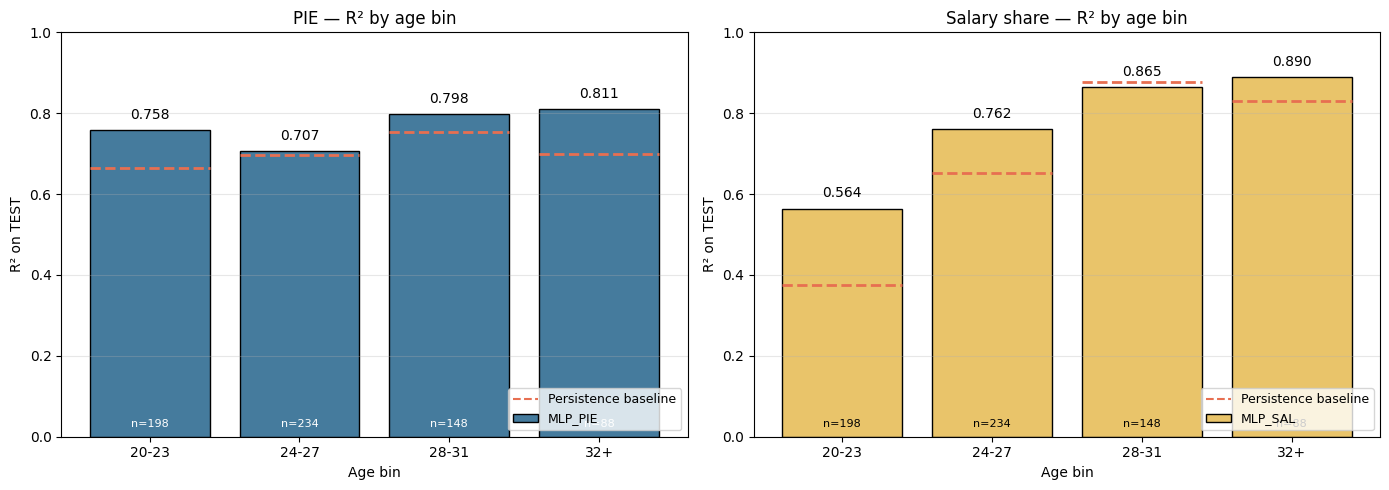

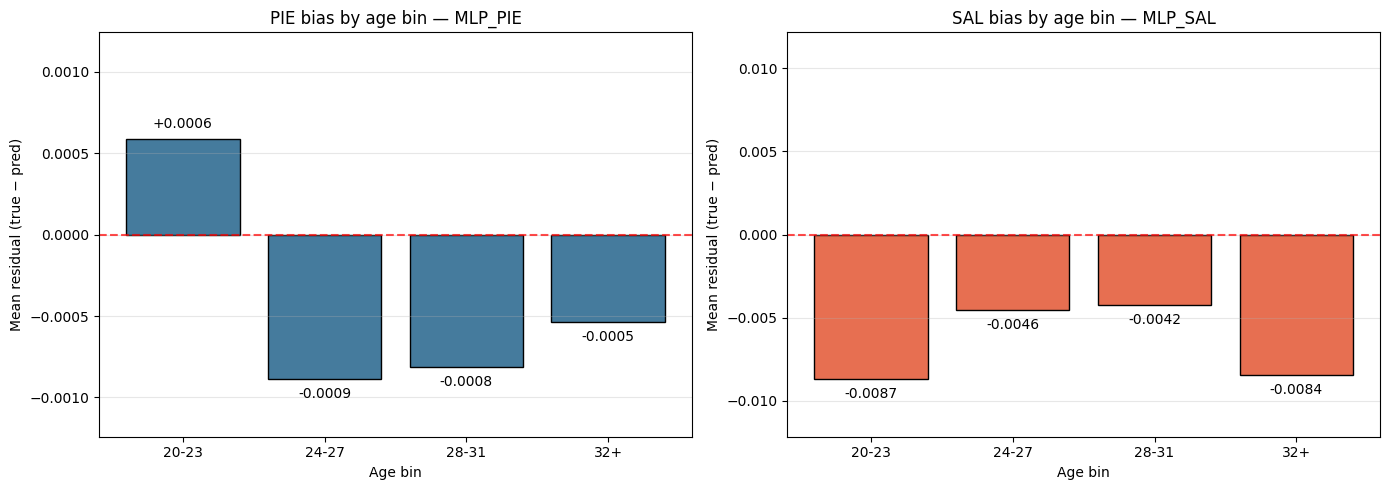


PIE  -  Persistence baseline per age bin
age_bin   n     R2    MAE   RMSE    bias
  20-23 198 0.6651 0.0136 0.0166  0.0066
  24-27 234 0.6968 0.0127 0.0159  0.0006
  28-31 148 0.7539 0.0126 0.0168 -0.0027
    32+  88 0.6991 0.0142 0.0173 -0.0060

SAL  -  Persistence baseline per age bin
age_bin   n     R2    MAE   RMSE    bias
  20-23 198 0.3754 0.0167 0.0421  0.0129
  24-27 234 0.6534 0.0272 0.0524  0.0135
  28-31 148 0.8762 0.0201 0.0341 -0.0030
    32+  88 0.8291 0.0298 0.0513 -0.0204


In [37]:
# CELL 29
# Block C: error stratification by player AGE bin on TEST.
# Within-target quintile R2 is degenerate (target variance concentrates by construction), 
# so quintile stratification is mentioned once in the limitations.

def per_group_metrics(y_true, y_pred, groups, group_name):
    df_res = pd.DataFrame({
        "y_true":   np.asarray(y_true),
        "y_pred":   np.asarray(y_pred),
        "residual": np.asarray(y_true) - np.asarray(y_pred),
        "group":    np.asarray(groups),
    })
    rows = []
    for g in df_res["group"].dropna().unique():
        sub = df_res[df_res["group"] == g]
        n = len(sub)
        rows.append({
            group_name: g,
            "n":    n,
            "R2":   r2_score(sub["y_true"], sub["y_pred"]) if n >= 5 else np.nan,
            "MAE":  sub["residual"].abs().mean(),
            "RMSE": np.sqrt((sub["residual"] ** 2).mean()),
            "bias": sub["residual"].mean(),
        })
    return pd.DataFrame(rows)

# Build age bins on TEST
test_age   = df_model_with_arch.loc[idx_test, "AGE_BASE"].values
age_bins   = [0, 24, 28, 32, 100]
age_labels = ["20-23", "24-27", "28-31", "32+"]
age_groups = pd.cut(test_age, bins=age_bins, labels=age_labels, right=False)

print(f"Test rows: {len(arch_test)}")
print(f"Age-bin counts: {age_groups.value_counts().sort_index().to_dict()}")

PIE_ML_MODELS = [(m, p) for m, p in MODELS_PIE if m != "Persistence_PIE"]
SAL_ML_MODELS = [(m, p) for m, p in MODELS_SAL if m != "Persistence_SAL"]

# Full metrics for PIE x age
print("\n" + "=" * 80)
print("PIE  -  AGE BIN stratification (full metrics)")
print("=" * 80)
for model_label, preds in PIE_ML_MODELS:
    tbl = per_group_metrics(y_pie_test, preds, age_groups, "age_bin").sort_values("age_bin")
    print(f"\n  {model_label}")
    print(tbl.round(5).to_string(index=False))

# Full metrics for SAL x age
print("\n" + "=" * 80)
print("SAL  -  AGE BIN stratification (full metrics)")
print("=" * 80)
for model_label, preds in SAL_ML_MODELS:
    tbl = per_group_metrics(y_sal_test, preds, age_groups, "age_bin").sort_values("age_bin")
    print(f"\n  {model_label}")
    print(tbl.round(5).to_string(index=False))

# Figure: R2 by age bin for PIE and SAL (main figure for SQ5 in Results)
# Bars: MLP_PIE / MLP_SAL.  Dashed orange line: persistence baseline.
pie_r2_tbl = per_group_metrics(y_pie_test, pred_pie_mlp,     age_groups, "age_bin").sort_values("age_bin")
pie_r2_per = per_group_metrics(y_pie_test, pred_pie_persist, age_groups, "age_bin").sort_values("age_bin")
sal_r2_tbl = per_group_metrics(y_sal_test, pred_sal_mlp,     age_groups, "age_bin").sort_values("age_bin")
sal_r2_per = per_group_metrics(y_sal_test, pred_sal_persist, age_groups, "age_bin").sort_values("age_bin")

fig_r2, axes_r2 = plt.subplots(1, 2, figsize=(14, 5))

# PIE panel
ax = axes_r2[0]
labels = pie_r2_tbl["age_bin"].astype(str).tolist()
bars = ax.bar(labels, pie_r2_tbl["R2"].tolist(),
              color="#457b9d", edgecolor="black", label="MLP_PIE")
for i, (lbl, x_pos) in enumerate(zip(labels, range(len(labels)))):
    persist_r2 = pie_r2_per["R2"].iloc[i]
    ax.hlines(persist_r2, x_pos - 0.4, x_pos + 0.4,
              colors="#e76f51", linestyles="--", linewidth=2)
ax.set_ylim(0, 1.0)
ax.set_title("PIE — R² by age bin", fontsize=12)
ax.set_xlabel("Age bin")
ax.set_ylabel("R² on TEST")
ax.grid(alpha=0.3, axis="y")
for bar, v, n_val in zip(bars, pie_r2_tbl["R2"].tolist(), pie_r2_tbl["n"].tolist()):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.02,
            f"{v:.3f}", ha="center", va="bottom", fontsize=10)
    ax.text(bar.get_x() + bar.get_width() / 2, 0.02,
            f"n={n_val}", ha="center", va="bottom", fontsize=8, color="white")
ax.plot([], [], color="#e76f51", linestyle="--", label="Persistence baseline")
ax.legend(loc="lower right", fontsize=9)

# SAL panel
ax = axes_r2[1]
labels = sal_r2_tbl["age_bin"].astype(str).tolist()
bars = ax.bar(labels, sal_r2_tbl["R2"].tolist(),
              color="#e9c46a", edgecolor="black", label="MLP_SAL")
for i, (lbl, x_pos) in enumerate(zip(labels, range(len(labels)))):
    persist_r2 = sal_r2_per["R2"].iloc[i]
    ax.hlines(persist_r2, x_pos - 0.4, x_pos + 0.4,
              colors="#e76f51", linestyles="--", linewidth=2)
ax.set_ylim(0, 1.0)
ax.set_title("Salary share — R² by age bin", fontsize=12)
ax.set_xlabel("Age bin")
ax.set_ylabel("R² on TEST")
ax.grid(alpha=0.3, axis="y")
for bar, v, n_val in zip(bars, sal_r2_tbl["R2"].tolist(), sal_r2_tbl["n"].tolist()):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.02,
            f"{v:.3f}", ha="center", va="bottom", fontsize=10)
    ax.text(bar.get_x() + bar.get_width() / 2, 0.02,
            f"n={n_val}", ha="center", va="bottom", fontsize=8, color="black")
ax.plot([], [], color="#e76f51", linestyle="--", label="Persistence baseline")
ax.legend(loc="lower right", fontsize=9)

plt.tight_layout()
plt.savefig("r2_by_age_bin.png", dpi=150, bbox_inches="tight")
plt.show()

# Figure: Bias by age bin
def annotated_bar(ax, labels, values, color, title, xlabel, ylabel):
    bars = ax.bar(labels, values, color=color, edgecolor="black")
    ax.axhline(0, color="red", linestyle="--", alpha=0.7)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3, axis="y")
    y_range = max(abs(min(values)), abs(max(values))) * 1.4
    ax.set_ylim(-y_range, y_range)
    for bar, v in zip(bars, values):
        offset = y_range * 0.04
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            v + offset if v >= 0 else v - offset,
            f"{v:+.4f}",
            ha="center",
            va="bottom" if v >= 0 else "top",
            fontsize=10,
        )

fig_bias, axes_bias = plt.subplots(1, 2, figsize=(14, 5))

pie_a_tbl = per_group_metrics(y_pie_test, pred_pie_mlp, age_groups, "age_bin").sort_values("age_bin")
annotated_bar(
    axes_bias[0],
    pie_a_tbl["age_bin"].astype(str).tolist(),
    pie_a_tbl["bias"].tolist(),
    "#457b9d",
    "PIE bias by age bin — MLP_PIE",
    "Age bin",
    "Mean residual (true − pred)",
)
sal_a_tbl = per_group_metrics(y_sal_test, pred_sal_mlp, age_groups, "age_bin").sort_values("age_bin")
annotated_bar(
    axes_bias[1],
    sal_a_tbl["age_bin"].astype(str).tolist(),
    sal_a_tbl["bias"].tolist(),
    "#e76f51",
    "SAL bias by age bin — MLP_SAL",
    "Age bin",
    "Mean residual (true − pred)",
)
plt.tight_layout()
plt.savefig("error_age_bias.png", dpi=150, bbox_inches="tight")
plt.show()


print("\n" + "=" * 80)
print("PIE  -  Persistence baseline per age bin")
print("=" * 80)
tbl = per_group_metrics(y_pie_test, pred_pie_persist, age_groups, "age_bin").sort_values("age_bin")
print(tbl.round(5).to_string(index=False))

print("\n" + "=" * 80)
print("SAL  -  Persistence baseline per age bin")
print("=" * 80)
tbl = per_group_metrics(y_sal_test, pred_sal_persist, age_groups, "age_bin").sort_values("age_bin")
print(tbl.round(5).to_string(index=False))

### Block D — Value Index and Market Inefficiency Analysis REHACER

BLOCK D  -  VALUE INDEX & MARKET INEFFICIENCY  (cohort-segmented)

Cohort segmentation on TEST
cohort
continuity    592
extension      48
break          28
  Total TEST rows: 668

Extension cohort  (top by salary jump)
      PLAYER_NAME  SEASON_END  AGE_BASE  salary_share  actual_share  actual_M$
  Anthony Edwards        2024   22.0000        0.0680        0.3000    40.8060
Tyrese Haliburton        2024   24.0000        0.0430        0.3000    40.8060
      LaMelo Ball        2024   22.0000        0.0800        0.2500    34.0050
     Tyrese Maxey        2024   23.0000        0.0320        0.2500    34.0050
Immanuel Quickley        2024   25.0000        0.0310        0.2310    31.4440
        Ja Morant        2023   23.0000        0.0780        0.2500    30.9140
   Darius Garland        2023   23.0000        0.0720        0.2500    30.9140
    Devin Vassell        2024   23.0000        0.0430        0.2090    28.3940

Break cohort  (largest drops)
      PLAYER_NAME  SEASON_END  AGE_BASE

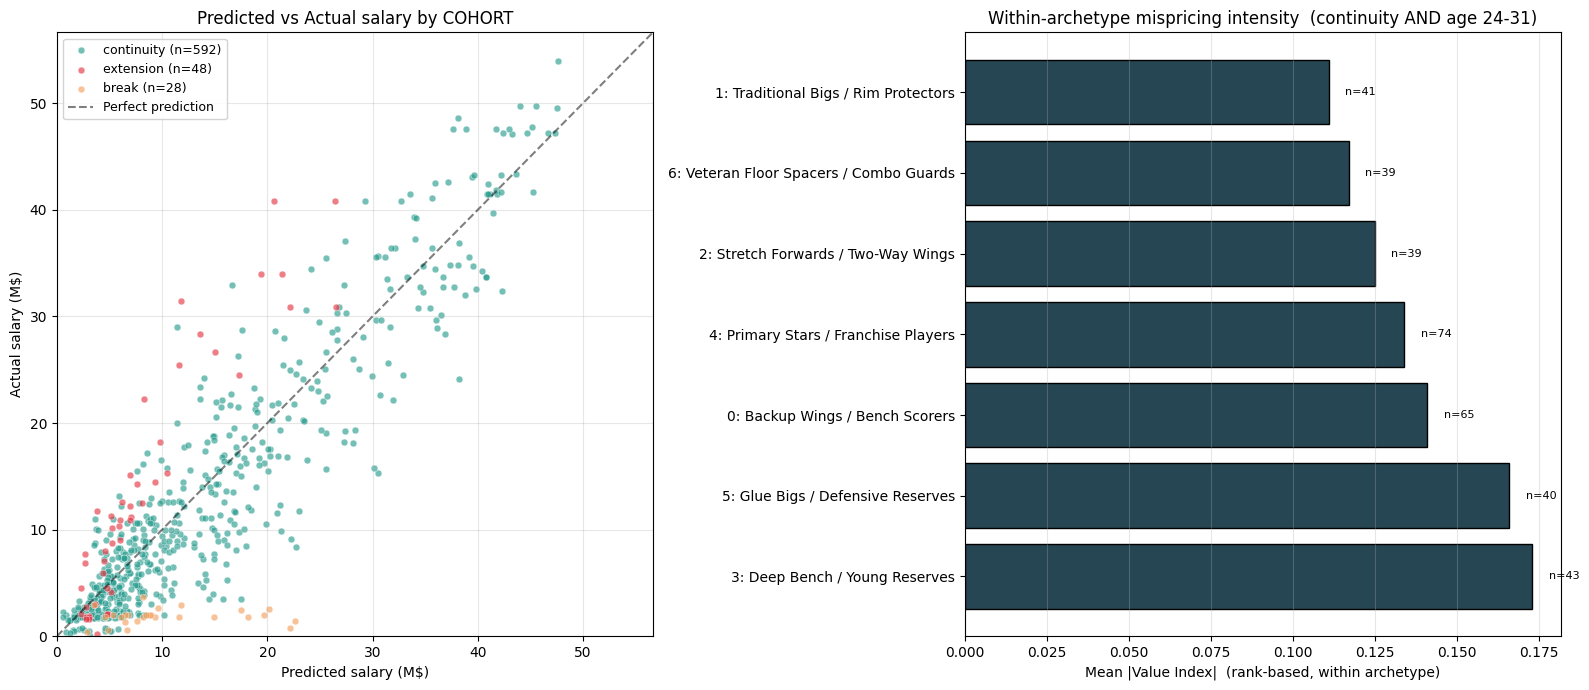

In [38]:
# CELL 30
# Block D: Value Index with cohort segmentation (K=7).
# The naive ranking by raw $ residual is dominated by structural contractual artifacts and by regression-to-the-mean compression. 
# The reformed approach segments TEST into three cohorts based on year-over-year contract transitions, 
# then computes a within-archetype rank-based Value Index over the eligible cohort only.
# Eligibility for the Value Index = continuity cohort  AND  age in [24, 31].

# Cohort thresholds (deterministic rules over salary_share at t and t+1)
COHORT_EXT_AGE_MAX        = 25
COHORT_EXT_SHARE_T_MAX    = 0.10
COHORT_EXT_JUMP_RATIO     = 2.0
COHORT_BRK_SHARE_NEXT_MAX = 0.03
COHORT_BRK_DROP_RATIO     = 0.5
COHORT_BRK_SHARE_T_MIN    = 0.05
ELIGIBLE_AGE_MIN          = 24
ELIGIBLE_AGE_MAX          = 31

# Build the working dataframe
test_cap      = df_model.loc[idx_test, "SALARY_CAP"].values
test_cap_mean = test_cap.mean()

df_market = df_model_with_arch[idx_test].copy()
df_market["actual_share"]    = y_sal_test.values
df_market["predicted_share"] = pred_sal_mlp
df_market["residual_share"]  = df_market["actual_share"] - df_market["predicted_share"]
df_market["actual_M$"]       = df_market["actual_share"]    * test_cap / 1e6
df_market["predicted_M$"]    = df_market["predicted_share"] * test_cap / 1e6
df_market["residual_M$"]     = df_market["actual_M$"]       - df_market["predicted_M$"]
df_market["arch_label"]      = [label_arch(a) for a in arch_test]

# Cohort assignment
is_extension = (
    (df_market["AGE_BASE"]    <= COHORT_EXT_AGE_MAX)
    & (df_market["salary_share"] <= COHORT_EXT_SHARE_T_MAX)
    & (df_market["actual_share"] >= COHORT_EXT_JUMP_RATIO * df_market["salary_share"])
)
is_break = (
    (df_market["actual_share"]   <= COHORT_BRK_SHARE_NEXT_MAX)
    & (df_market["actual_share"] <= COHORT_BRK_DROP_RATIO * df_market["salary_share"])
    & (df_market["salary_share"] >= COHORT_BRK_SHARE_T_MIN)
)

df_market["cohort"] = "continuity"
df_market.loc[is_extension, "cohort"] = "extension"
df_market.loc[is_break,     "cohort"] = "break"

print("=" * 90)
print("BLOCK D  -  VALUE INDEX & MARKET INEFFICIENCY  (cohort-segmented)")
print("=" * 90)

print("\nCohort segmentation on TEST")
print(df_market["cohort"].value_counts().to_string())
print(f"  Total TEST rows: {len(df_market):,}")

# Trace cohort membership
ext_top = (
    df_market[df_market["cohort"] == "extension"]
    .nlargest(8, "actual_M$")[
        ["PLAYER_NAME", "SEASON_END", "AGE_BASE",
         "salary_share", "actual_share", "actual_M$"]
    ]
    .round(3)
)
print("\nExtension cohort  (top by salary jump)")
print(ext_top.to_string(index=False))

brk_top = (
    df_market[df_market["cohort"] == "break"]
    .assign(drop_share=lambda d: d["salary_share"] - d["actual_share"])
    .nlargest(8, "drop_share")[
        ["PLAYER_NAME", "SEASON_END", "AGE_BASE",
         "salary_share", "actual_share", "actual_M$"]
    ]
    .round(3)
)
print("\nBreak cohort  (largest drops)")
print(brk_top.to_string(index=False))

# Sanity check: naive vs reformed top-5
DISPLAY_COLS = [
    "PLAYER_NAME", "SEASON_END", "AGE_BASE", "arch_label", "cohort",
    "actual_M$", "predicted_M$", "residual_M$",
]

print("\n" + "=" * 90)
print("SANITY CHECK  -  naive top-5 (all TEST) vs reformed top-5 (eligible only)")
print("=" * 90)

print("\n[NAIVE] Top-5 OVERPAID over all TEST (contaminated by extensions)")
print(df_market.nlargest(5, "residual_M$")[DISPLAY_COLS].round(2).to_string(index=False))

print("\n[NAIVE] Top-5 UNDERPAID over all TEST (contaminated by breaks)")
print(df_market.nsmallest(5, "residual_M$")[DISPLAY_COLS].round(2).to_string(index=False))

mask_eligible = (
    (df_market["cohort"] == "continuity")
    & (df_market["AGE_BASE"] >= ELIGIBLE_AGE_MIN)
    & (df_market["AGE_BASE"] <= ELIGIBLE_AGE_MAX)
)
df_eligible = df_market[mask_eligible].copy()
print(f"\nEligible cohort (continuity AND age {ELIGIBLE_AGE_MIN}-{ELIGIBLE_AGE_MAX}): "
      f"{len(df_eligible):,} players")
print("This is the validity domain of the Value Index.")

print("\n[REFORMED] Top-5 OVERPAID (eligible only)")
print(df_eligible.nlargest(5, "residual_M$")[DISPLAY_COLS].round(2).to_string(index=False))

print("\n[REFORMED] Top-5 UNDERPAID (eligible only)")
print(df_eligible.nsmallest(5, "residual_M$")[DISPLAY_COLS].round(2).to_string(index=False))

# Value Index: rank-based, within archetype
print("\n" + "=" * 90)
print("VALUE INDEX  (rank-based, within archetype, eligible cohort)")
print("=" * 90)

df_eligible["actual_pct"]    = df_eligible.groupby("archetype")["actual_share"].rank(pct=True)
df_eligible["predicted_pct"] = df_eligible.groupby("archetype")["predicted_share"].rank(pct=True)
df_eligible["value_index"]   = df_eligible["predicted_pct"] - df_eligible["actual_pct"]

VI_COLS = [
    "PLAYER_NAME", "SEASON_END", "AGE_BASE", "arch_label",
    "actual_M$", "predicted_M$",
    "actual_pct", "predicted_pct", "value_index",
]

print("\nTop-10 UNDERVALUED  (high VI: paid below predicted rank in archetype)")
print(df_eligible.nlargest(10, "value_index")[VI_COLS].round(3).to_string(index=False))

print("\nTop-10 OVERVALUED  (low VI: paid above predicted rank in archetype)")
print(df_eligible.nsmallest(10, "value_index")[VI_COLS].round(3).to_string(index=False))

# Per-archetype VI dispersion
arch_vi = (
    df_eligible.groupby("arch_label")
    .agg(
        n=("value_index", "size"),
        mean_abs_VI=("value_index", lambda s: s.abs().mean()),
        std_VI=("value_index", "std"),
        mean_residual_M=("residual_M$", "mean"),
    )
    .round(3)
    .sort_values("mean_abs_VI", ascending=False)
)
print("\nPer-archetype Value Index dispersion (eligible cohort)")
print("Mean(VI) = 0 by construction within archetype; the dispersion is the signal.")
print(arch_vi.to_string())
print("Note: archetypes with n < 15 should be interpreted with caution.")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

cohort_colors = {"extension": "#e63946", "break": "#f4a261", "continuity": "#2a9d8f"}
for cohort_name in ["continuity", "extension", "break"]:
    sub = df_market[df_market["cohort"] == cohort_name]
    axes[0].scatter(
        sub["predicted_M$"], sub["actual_M$"],
        s=24, alpha=0.65, color=cohort_colors[cohort_name],
        label=f"{cohort_name} (n={len(sub)})",
        edgecolor="white", linewidth=0.4,
    )
max_val = max(df_market["actual_M$"].max(), df_market["predicted_M$"].max()) * 1.05
axes[0].plot([0, max_val], [0, max_val], "k--", alpha=0.5, label="Perfect prediction")
axes[0].set_xlabel("Predicted salary (M$)")
axes[0].set_ylabel("Actual salary (M$)")
axes[0].set_title("Predicted vs Actual salary by COHORT")
axes[0].legend(fontsize=9, loc="upper left", framealpha=0.85)
axes[0].set_xlim(0, max_val)
axes[0].set_ylim(0, max_val)
axes[0].grid(alpha=0.3)

arch_order = arch_vi.index.tolist()
bars = axes[1].barh(
    arch_order,
    arch_vi["mean_abs_VI"].values,
    color="#264653", edgecolor="black",
)
axes[1].set_xlabel("Mean |Value Index|  (rank-based, within archetype)")
axes[1].set_title(f"Within-archetype mispricing intensity  "
                  f"(continuity AND age {ELIGIBLE_AGE_MIN}-{ELIGIBLE_AGE_MAX})")
axes[1].grid(alpha=0.3, axis="x")
for bar, n in zip(bars, arch_vi["n"].values):
    flag = "  small n" if n < 15 else ""
    axes[1].text(
        bar.get_width() + 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"n={n}{flag}", va="center", fontsize=8,
    )

plt.tight_layout()
plt.savefig("value_index_reformed.png", dpi=150, bbox_inches="tight")
plt.show()

### Block E — Interpretability

PCA LOADINGS  -  Top-7 features per PC for the first 30 components
Variance explained by these 30 PCs: 97.80%

PC1  (explains 26.99% of variance)
        feature  loading  abs_load
       PTS_BASE   0.1741    0.1741
       FGM_BASE   0.1730    0.1730
FGM_PG_ADVANCED   0.1730    0.1730
       FGA_BASE   0.1674    0.1674
FGA_PG_ADVANCED   0.1674    0.1674
       PFD_BASE   0.1638    0.1638
       PFD_MISC   0.1638    0.1638

PC2  (explains 19.95% of variance)
              feature  loading  abs_load
       PCT_OREB_USAGE   0.2039    0.2039
    OREB_PCT_ADVANCED   0.1962    0.1962
     REB_PCT_ADVANCED   0.1961    0.1961
        PCT_REB_USAGE   0.1956    0.1956
    DREB_PCT_ADVANCED   0.1774    0.1774
       PCT_DREB_USAGE   0.1764    0.1764
PCT_PTS_PAINT_SCORING   0.1748    0.1748

PC3  (explains 9.10% of variance)
                    feature  loading  abs_load
      E_NET_RATING_ADVANCED   0.2773    0.2773
        NET_RATING_ADVANCED   0.2757    0.2757
sp_work_NET_RATING_ADVANCED   0.27

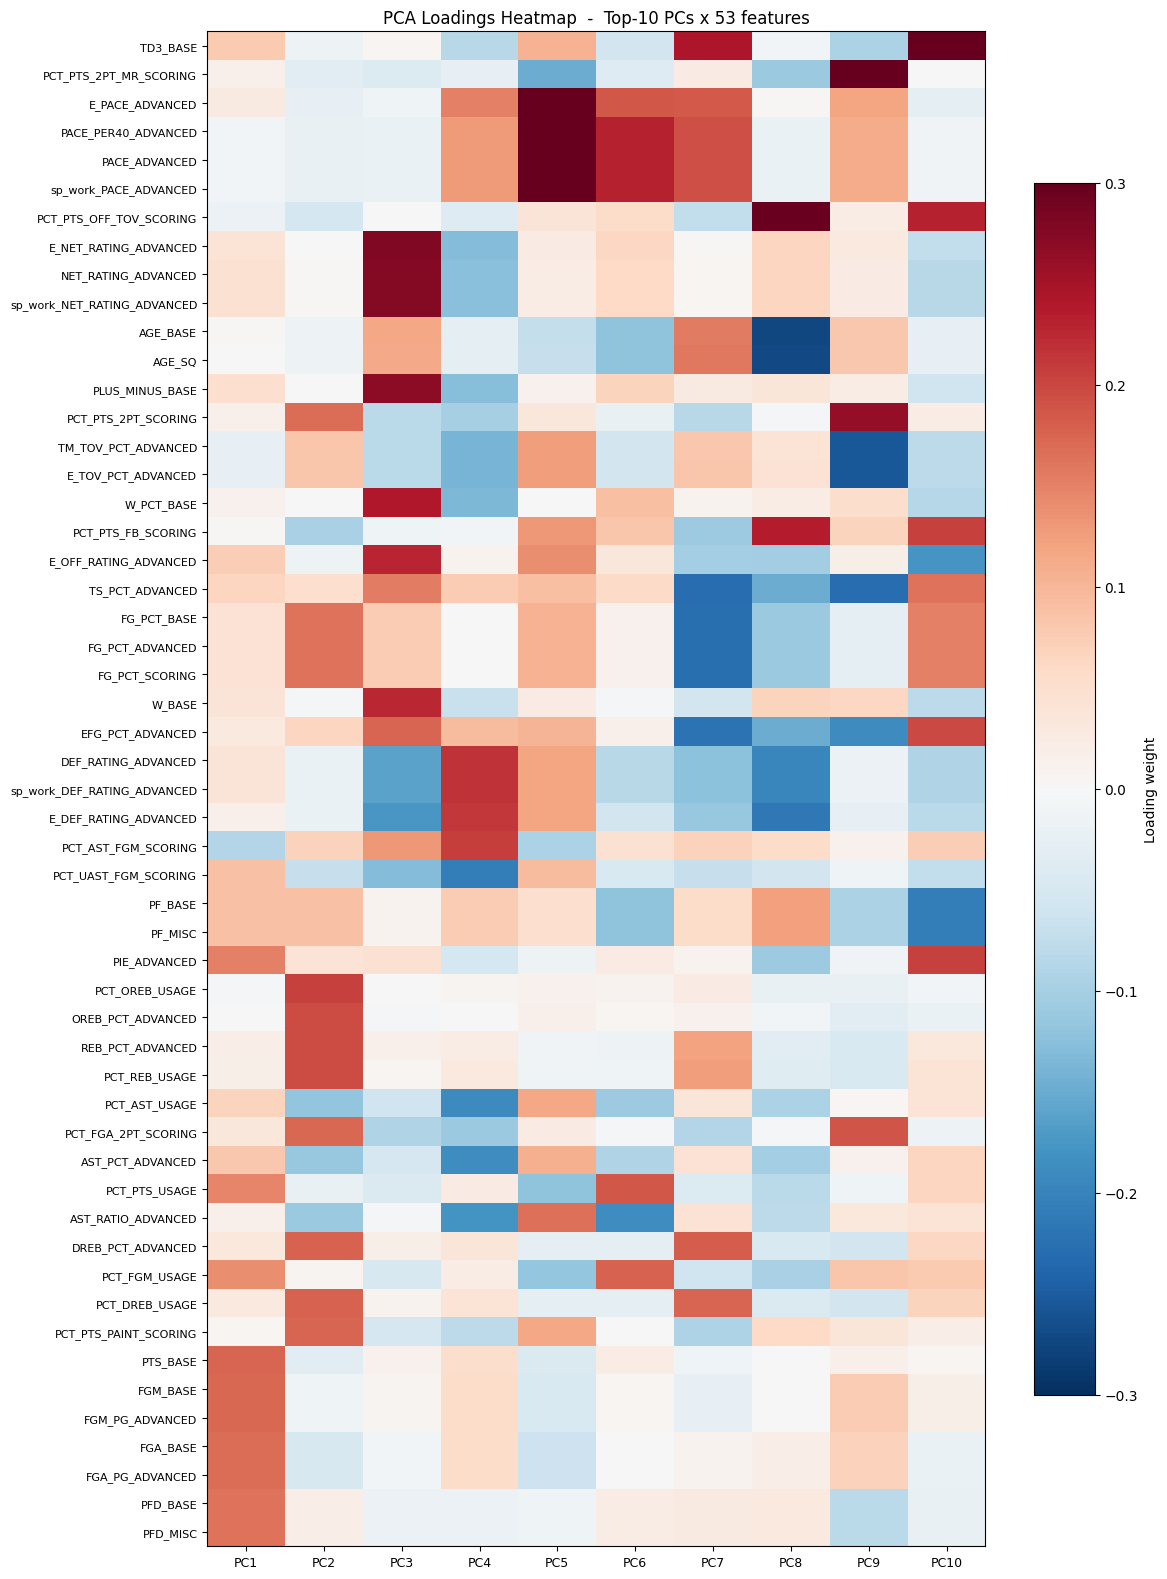


Loading summaries stored in PCA_LOADING_SUMMARIES (covers PC1..PC30).


In [39]:
# CELL 31
# Block E Part 1: PCA loadings inspection.
# For the first N_INSPECT_PCS principal components, list the top-N original features by absolute loading. 
# These tables bridge the abstract PCA space back to the interpretable feature space and feed all subsequent interpretability cells

N_INSPECT_PCS  = 30
N_HEATMAP_PCS  = 10
N_TOP_FEATURES = 7

feature_names = X_train.columns.tolist()
loadings = pd.DataFrame(
    pca.components_[:N_INSPECT_PCS],
    columns=feature_names,
    index=[f"PC{i+1}" for i in range(N_INSPECT_PCS)],
)

print("=" * 90)
print(f"PCA LOADINGS  -  Top-{N_TOP_FEATURES} features per PC for the first "
      f"{N_INSPECT_PCS} components")
print(f"Variance explained by these {N_INSPECT_PCS} PCs: "
      f"{pca.explained_variance_ratio_[:N_INSPECT_PCS].sum():.2%}")
print("=" * 90)

PCA_LOADING_SUMMARIES = {}
for pc_name in loadings.index:
    row = loadings.loc[pc_name]
    top_idx = row.abs().nlargest(N_TOP_FEATURES).index
    summary = pd.DataFrame({
        "feature":   top_idx,
        "loading":   row[top_idx].values,
        "abs_load":  row[top_idx].abs().values,
    })
    PCA_LOADING_SUMMARIES[pc_name] = summary
    var_pct = pca.explained_variance_ratio_[int(pc_name[2:]) - 1]
    print(f"\n{pc_name}  (explains {var_pct:.2%} of variance)")
    print(summary.to_string(index=False))

# Heatmap of top PCs vs the union of their top features
loadings_heatmap = loadings.iloc[:N_HEATMAP_PCS]
all_top_features = list(dict.fromkeys(
    feat
    for pc in list(PCA_LOADING_SUMMARIES.values())[:N_HEATMAP_PCS]
    for feat in pc["feature"].tolist()
))
heatmap_data = loadings_heatmap[all_top_features].T
heatmap_data = heatmap_data.loc[
    heatmap_data.abs().max(axis=1).sort_values(ascending=False).index
]

fig, ax = plt.subplots(figsize=(12, max(8, len(heatmap_data) * 0.3)))
im = ax.imshow(heatmap_data.values, aspect="auto", cmap="RdBu_r",
               vmin=-0.3, vmax=0.3)
ax.set_xticks(range(N_HEATMAP_PCS))
ax.set_xticklabels(heatmap_data.columns, fontsize=9)
ax.set_yticks(range(len(heatmap_data)))
ax.set_yticklabels(heatmap_data.index, fontsize=8)
ax.set_title(
    f"PCA Loadings Heatmap  -  Top-{N_HEATMAP_PCS} PCs x {len(heatmap_data)} features"
)
plt.colorbar(im, ax=ax, label="Loading weight", shrink=0.8)
plt.tight_layout()
plt.savefig("pca_loadings_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nLoading summaries stored in PCA_LOADING_SUMMARIES "
      f"(covers PC1..PC{N_INSPECT_PCS}).")

PERMUTATION IMPORTANCE on TEST  (10 repeats per feature)

ElasticNet_PIE  (PIE)
  baseline R2 on TEST: 0.7566
  PC  importance    std
 PC1      1.3230 0.0682
 PC2      0.0827 0.0087
PC10      0.0624 0.0068
PC11      0.0419 0.0030
PC14      0.0418 0.0067
 PC4      0.0284 0.0046
 PC8      0.0143 0.0017

LightGBM_PIE  (PIE)
  baseline R2 on TEST: 0.7294
  PC  importance    std
 PC1      1.2586 0.0664
 PC2      0.0727 0.0073
PC10      0.0494 0.0049
PC14      0.0402 0.0067
PC11      0.0367 0.0024
 PC4      0.0188 0.0028
PC18      0.0140 0.0031

MLP_PIE  (PIE)
  baseline R2 on TEST: 0.7614
  PC  importance    std
 PC1      1.3422 0.0732
 PC2      0.0909 0.0097
PC10      0.0596 0.0061
PC11      0.0423 0.0024
PC14      0.0396 0.0060
 PC4      0.0283 0.0045
 PC8      0.0127 0.0018

ElasticNet_SAL  (SAL)
  baseline R2 on TEST: 0.8031
  PC  importance    std
 PC1      0.9856 0.0509
 PC3      0.0682 0.0079
PC25      0.0408 0.0028
PC21      0.0383 0.0033
 PC7      0.0351 0.0053
PC11      0.0350 0.0

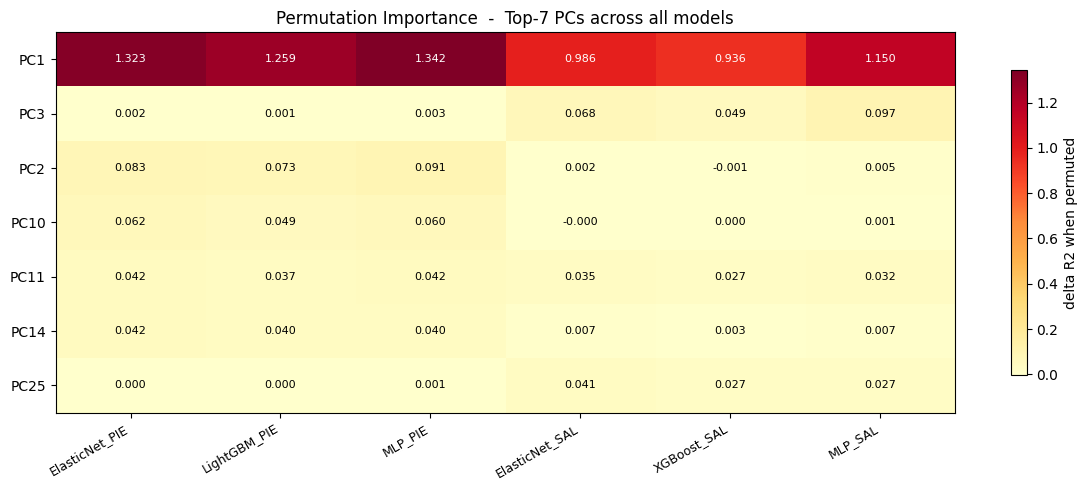


BRIDGING  -  what the most important PCs capture in basketball terms

ElasticNet_PIE
  PC1 (delta R2=1.3230):  PTS_BASE (+0.174), FGM_BASE (+0.173), FGM_PG_ADVANCED (+0.173), FGA_BASE (+0.167), FGA_PG_ADVANCED (+0.167)
  PC2 (delta R2=0.0827):  PCT_OREB_USAGE (+0.204), OREB_PCT_ADVANCED (+0.196), REB_PCT_ADVANCED (+0.196), PCT_REB_USAGE (+0.196), DREB_PCT_ADVANCED (+0.177)
  PC10 (delta R2=0.0624):  TD3_BASE (+0.445), PCT_PTS_OFF_TOV_SCORING (+0.231), PF_BASE (-0.207), PF_MISC (-0.207), PIE_ADVANCED (+0.205)

LightGBM_PIE
  PC1 (delta R2=1.2586):  PTS_BASE (+0.174), FGM_BASE (+0.173), FGM_PG_ADVANCED (+0.173), FGA_BASE (+0.167), FGA_PG_ADVANCED (+0.167)
  PC2 (delta R2=0.0727):  PCT_OREB_USAGE (+0.204), OREB_PCT_ADVANCED (+0.196), REB_PCT_ADVANCED (+0.196), PCT_REB_USAGE (+0.196), DREB_PCT_ADVANCED (+0.177)
  PC10 (delta R2=0.0494):  TD3_BASE (+0.445), PCT_PTS_OFF_TOV_SCORING (+0.231), PF_BASE (-0.207), PF_MISC (-0.207), PIE_ADVANCED (+0.205)

MLP_PIE
  PC1 (delta R2=1.3422):  PTS_BAS

In [40]:
# CELL 32
# Block E Part 2: permutation importance + bridging to original features.

N_REPEATS      = 10
N_TOP_PCS_SHOW = 7
N_BRIDGE_PCS   = 3
N_BRIDGE_FEATS = 5

def manual_permutation_importance(model, X, y, n_repeats, random_state):
    """Permutation importance using only model.predict(). Score is R2.
    importance = baseline_score - mean(permuted_scores) per feature."""
    rng      = np.random.RandomState(random_state)
    X_values = X.values if hasattr(X, "values") else np.asarray(X)
    y_values = np.asarray(y)
    baseline = r2_score(y_values, model.predict(X))

    n_features  = X_values.shape[1]
    importances = np.zeros((n_features, n_repeats))

    for feat_idx in range(n_features):
        for rep in range(n_repeats):
            X_perm = X_values.copy()
            rng.shuffle(X_perm[:, feat_idx])
            if hasattr(X, "columns"):
                X_perm_df = pd.DataFrame(X_perm, columns=X.columns, index=X.index)
                permuted_score = r2_score(y_values, model.predict(X_perm_df))
            else:
                permuted_score = r2_score(y_values, model.predict(X_perm))
            importances[feat_idx, rep] = baseline - permuted_score

    return {
        "importances_mean": importances.mean(axis=1),
        "importances_std":  importances.std(axis=1),
        "baseline_score":   baseline,
    }

INTERP_MODELS = [
    ("ElasticNet_PIE", enet_pie, X_test_final, y_pie_test, "PIE"),
    ("LightGBM_PIE",   lgbm_pie, X_test_final, y_pie_test, "PIE"),
    ("MLP_PIE",        mlp_pie,  X_test_final, y_pie_test, "PIE"),
    ("ElasticNet_SAL", enet_sal, X_test_final, y_sal_test, "SAL"),
    ("XGBoost_SAL",    xgb_sal,  X_test_final, y_sal_test, "SAL"),
    ("MLP_SAL",        mlp_sal,  X_test_final, y_sal_test, "SAL"),
]
pca_col_names = [f"PC{i+1}" for i in range(K)]

print("=" * 90)
print(f"PERMUTATION IMPORTANCE on TEST  ({N_REPEATS} repeats per feature)")
print("=" * 90)

perm_results = {}
for model_name, model, X_te, y_te, target in INTERP_MODELS:
    print(f"\n{model_name}  ({target})")
    result = manual_permutation_importance(
        model, X_te, y_te,
        n_repeats=N_REPEATS,
        random_state=RANDOM_STATE,
    )
    imp_df = pd.DataFrame({
        "PC":         pca_col_names,
        "importance": result["importances_mean"],
        "std":        result["importances_std"],
    }).sort_values("importance", ascending=False)
    perm_results[model_name] = imp_df
    print(f"  baseline R2 on TEST: {result['baseline_score']:.4f}")
    print(imp_df.head(N_TOP_PCS_SHOW).round(5).to_string(index=False))

# Comparative heatmap across all models
imp_matrix = pd.DataFrame({
    name: res.set_index("PC")["importance"]
    for name, res in perm_results.items()
})
top_pcs_global = imp_matrix.max(axis=1).nlargest(N_TOP_PCS_SHOW).index.tolist()
imp_matrix_top = imp_matrix.loc[top_pcs_global]

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(imp_matrix_top.values, aspect="auto", cmap="YlOrRd")
ax.set_xticks(range(len(imp_matrix_top.columns)))
ax.set_xticklabels(imp_matrix_top.columns, fontsize=9, rotation=30, ha="right")
ax.set_yticks(range(len(imp_matrix_top)))
ax.set_yticklabels(imp_matrix_top.index, fontsize=10)
ax.set_title(f"Permutation Importance  -  Top-{N_TOP_PCS_SHOW} PCs across all models")
plt.colorbar(im, ax=ax, label="delta R2 when permuted", shrink=0.8)

vmax = imp_matrix_top.values.max()
for i in range(len(imp_matrix_top)):
    for j in range(len(imp_matrix_top.columns)):
        val   = imp_matrix_top.iloc[i, j]
        color = "white" if val > vmax * 0.6 else "black"
        ax.text(j, i, f"{val:.3f}", ha="center", va="center",
                fontsize=8, color=color)

plt.tight_layout()
plt.savefig("permutation_importance_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

# Bridging: top PCs back to original features
print("\n" + "=" * 90)
print("BRIDGING  -  what the most important PCs capture in basketball terms")
print("=" * 90)

for model_name, imp_df in perm_results.items():
    print(f"\n{model_name}")
    for _, row in imp_df.head(N_BRIDGE_PCS).iterrows():
        pc_name = row["PC"]
        imp_val = row["importance"]
        if pc_name in PCA_LOADING_SUMMARIES:
            features = PCA_LOADING_SUMMARIES[pc_name].head(N_BRIDGE_FEATS)
            feat_str = ", ".join(
                f"{r['feature']} ({r['loading']:+.3f})"
                for _, r in features.iterrows()
            )
        else:
            feat_str = "(loadings not available for this PC)"
        print(f"  {pc_name} (delta R2={imp_val:.4f}):  {feat_str}")

Computing SHAP values for LightGBM_PIE on TEST...
Computing SHAP values for XGBoost_SAL on TEST...


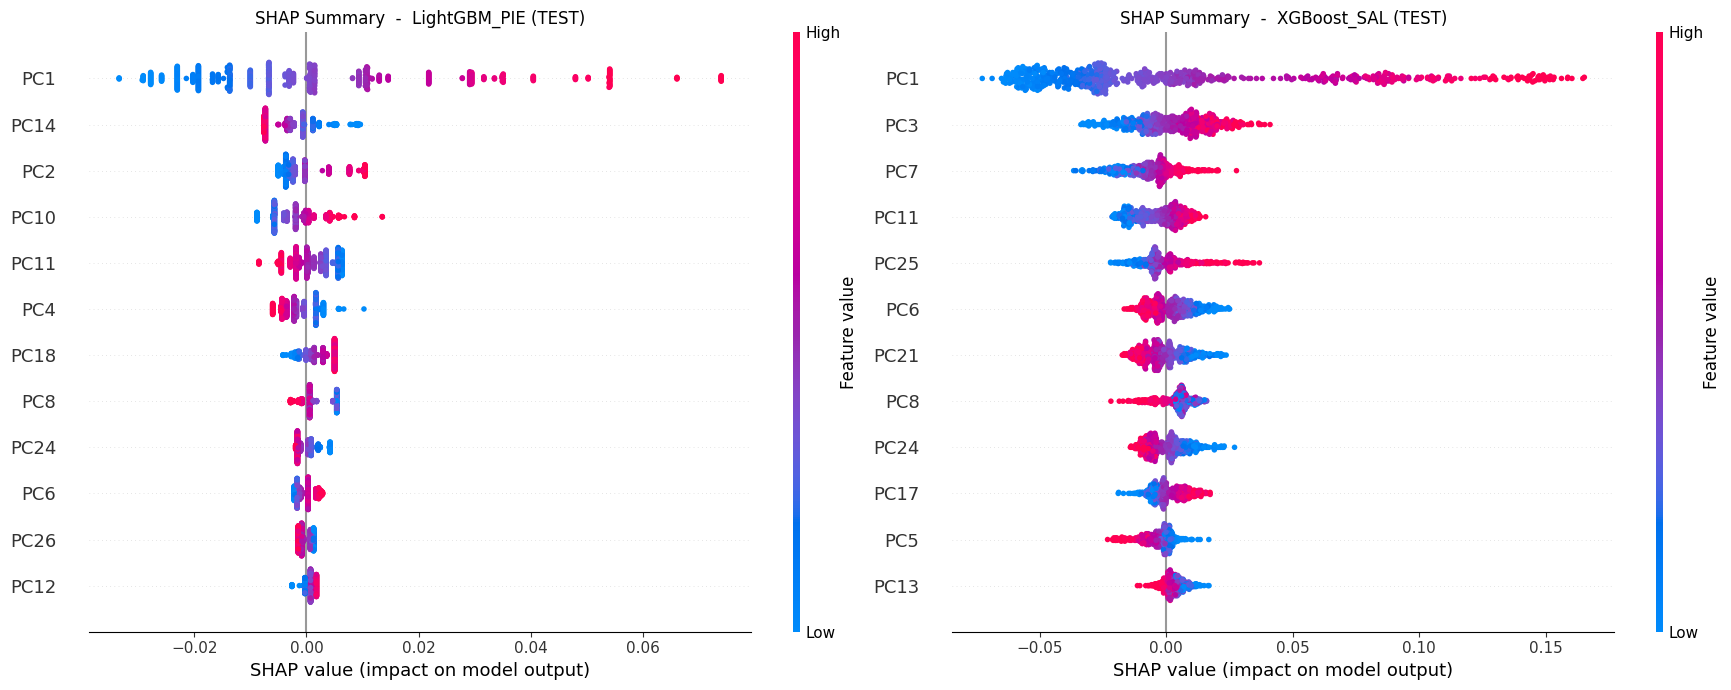

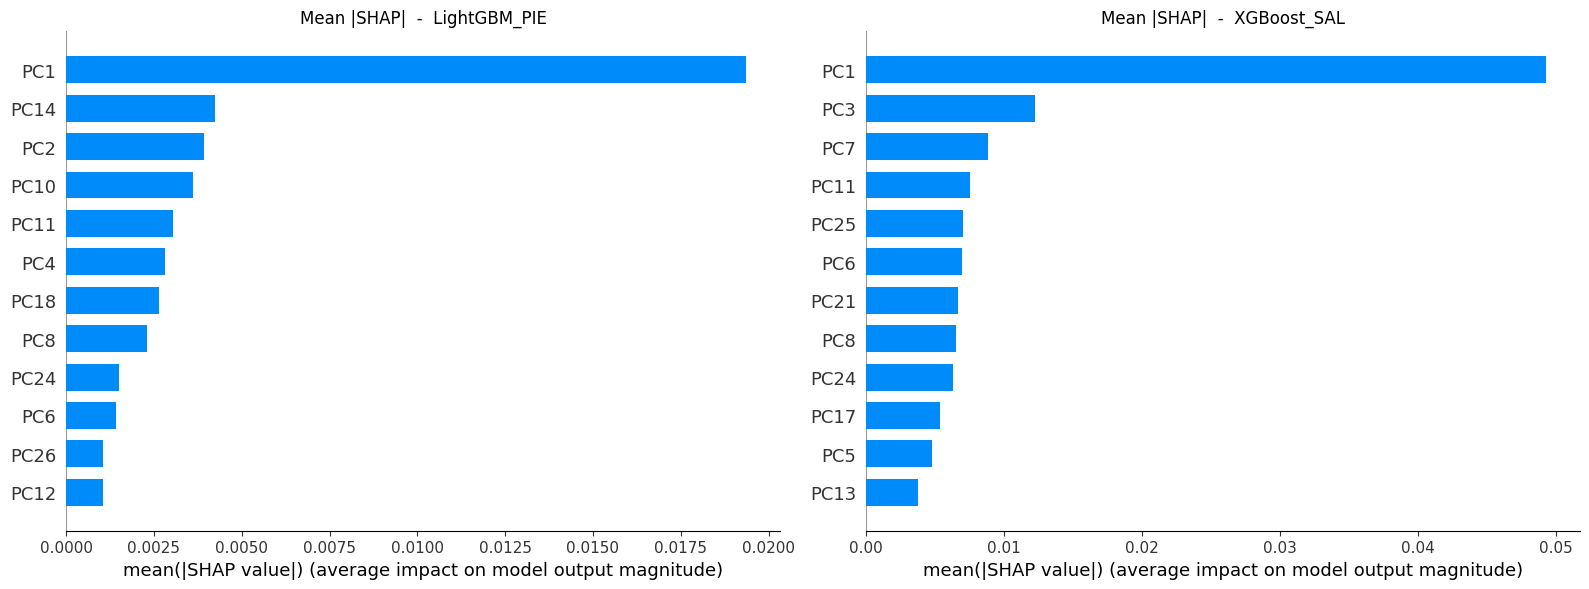

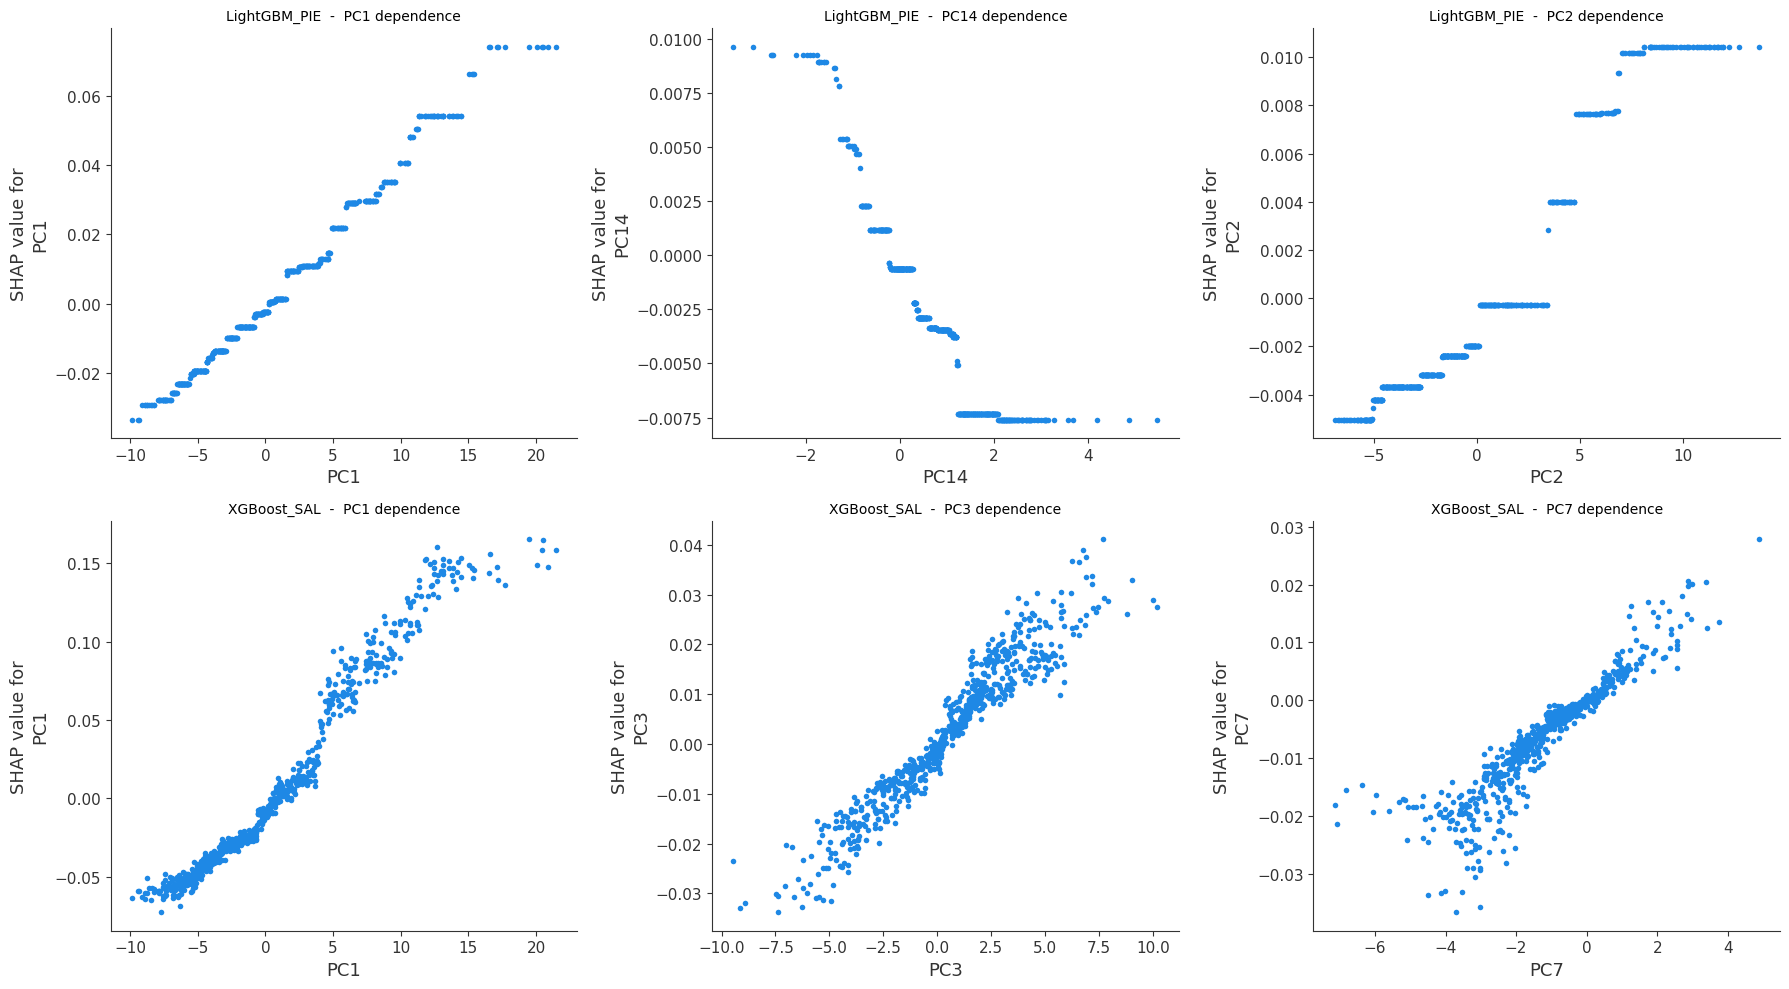


SHAP BRIDGING  -  top PCs by mean |SHAP|  -> original features

LightGBM_PIE
  PC1 (mean|SHAP|=0.0194):  PTS_BASE (+0.174), FGM_BASE (+0.173), FGM_PG_ADVANCED (+0.173), FGA_BASE (+0.167), FGA_PG_ADVANCED (+0.167)
  PC14 (mean|SHAP|=0.0042):  TD3_BASE (+0.574), PIE_ADVANCED (-0.188), AST_TO_ADVANCED (-0.178), TM_TOV_PCT_ADVANCED (+0.155), E_TOV_PCT_ADVANCED (+0.154)
  PC2 (mean|SHAP|=0.0039):  PCT_OREB_USAGE (+0.204), OREB_PCT_ADVANCED (+0.196), REB_PCT_ADVANCED (+0.196), PCT_REB_USAGE (+0.196), DREB_PCT_ADVANCED (+0.177)

XGBoost_SAL
  PC1 (mean|SHAP|=0.0493):  PTS_BASE (+0.174), FGM_BASE (+0.173), FGM_PG_ADVANCED (+0.173), FGA_BASE (+0.167), FGA_PG_ADVANCED (+0.167)
  PC3 (mean|SHAP|=0.0123):  E_NET_RATING_ADVANCED (+0.277), NET_RATING_ADVANCED (+0.276), sp_work_NET_RATING_ADVANCED (+0.276), PLUS_MINUS_BASE (+0.268), W_PCT_BASE (+0.240)
  PC7 (mean|SHAP|=0.0089):  TD3_BASE (+0.242), TS_PCT_ADVANCED (-0.228), FG_PCT_BASE (-0.227), FG_PCT_ADVANCED (-0.227), FG_PCT_SCORING (-0.227)


In [41]:
# CELL 33
# Block E Part 3: SHAP analysis for the tree-based models.

try:
    import shap
except ImportError:
    raise ImportError(
        "Package 'shap' is required for this cell. "
        "Install it once with: pip install shap"
    )

pca_col_names = [f"PC{i+1}" for i in range(K)]

print("Computing SHAP values for LightGBM_PIE on TEST...")
explainer_lgbm   = shap.TreeExplainer(lgbm_pie)
shap_values_lgbm = explainer_lgbm.shap_values(X_test_final)

print("Computing SHAP values for XGBoost_SAL on TEST...")
explainer_xgb   = shap.TreeExplainer(xgb_sal)
shap_values_xgb = explainer_xgb.shap_values(X_test_final)

# Beeswarm summaries
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

plt.sca(axes[0])
shap.summary_plot(
    shap_values_lgbm, X_test_final,
    feature_names=pca_col_names,
    max_display=12, show=False, plot_size=None,
)
axes[0].set_title("SHAP Summary  -  LightGBM_PIE (TEST)", fontsize=12)

plt.sca(axes[1])
shap.summary_plot(
    shap_values_xgb, X_test_final,
    feature_names=pca_col_names,
    max_display=12, show=False, plot_size=None,
)
axes[1].set_title("SHAP Summary  -  XGBoost_SAL (TEST)", fontsize=12)

plt.tight_layout()
plt.savefig("shap_summary_trees.png", dpi=150, bbox_inches="tight")
plt.show()

# Mean |SHAP| bar plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plt.sca(axes[0])
shap.summary_plot(
    shap_values_lgbm, X_test_final,
    feature_names=pca_col_names,
    plot_type="bar", max_display=12, show=False, plot_size=None,
)
axes[0].set_title("Mean |SHAP|  -  LightGBM_PIE", fontsize=12)

plt.sca(axes[1])
shap.summary_plot(
    shap_values_xgb, X_test_final,
    feature_names=pca_col_names,
    plot_type="bar", max_display=12, show=False, plot_size=None,
)
axes[1].set_title("Mean |SHAP|  -  XGBoost_SAL", fontsize=12)

plt.tight_layout()
plt.savefig("shap_bar_trees.png", dpi=150, bbox_inches="tight")
plt.show()

# Top-3 PC dependence plots per model
mean_abs_shap_lgbm = np.abs(shap_values_lgbm).mean(axis=0)
mean_abs_shap_xgb  = np.abs(shap_values_xgb).mean(axis=0)
top3_lgbm = np.argsort(mean_abs_shap_lgbm)[-3:][::-1]
top3_xgb  = np.argsort(mean_abs_shap_xgb)[-3:][::-1]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for col_idx, pc_idx in enumerate(top3_lgbm):
    plt.sca(axes[0, col_idx])
    shap.dependence_plot(
        pc_idx, shap_values_lgbm, X_test_final,
        feature_names=pca_col_names,
        interaction_index=None, show=False, ax=axes[0, col_idx],
    )
    axes[0, col_idx].set_title(
        f"LightGBM_PIE  -  {pca_col_names[pc_idx]} dependence", fontsize=10
    )

for col_idx, pc_idx in enumerate(top3_xgb):
    plt.sca(axes[1, col_idx])
    shap.dependence_plot(
        pc_idx, shap_values_xgb, X_test_final,
        feature_names=pca_col_names,
        interaction_index=None, show=False, ax=axes[1, col_idx],
    )
    axes[1, col_idx].set_title(
        f"XGBoost_SAL  -  {pca_col_names[pc_idx]} dependence", fontsize=10
    )

plt.tight_layout()
plt.savefig("shap_dependence_trees.png", dpi=150, bbox_inches="tight")
plt.show()

# Bridge top PCs by mean |SHAP| back to original features
print("\n" + "=" * 90)
print("SHAP BRIDGING  -  top PCs by mean |SHAP|  -> original features")
print("=" * 90)

N_BRIDGE = 3
N_FEATS  = 5
for model_name, mean_abs in [
    ("LightGBM_PIE", mean_abs_shap_lgbm),
    ("XGBoost_SAL",  mean_abs_shap_xgb),
]:
    print(f"\n{model_name}")
    top_idx = np.argsort(mean_abs)[-N_BRIDGE:][::-1]
    for pc_idx in top_idx:
        pc_name         = pca_col_names[pc_idx]
        shap_importance = mean_abs[pc_idx]
        if pc_name in PCA_LOADING_SUMMARIES:
            features = PCA_LOADING_SUMMARIES[pc_name].head(N_FEATS)
            feat_str = ", ".join(
                f"{r['feature']} ({r['loading']:+.3f})"
                for _, r in features.iterrows()
            )
        else:
            feat_str = "(loadings not available)"
        print(f"  {pc_name} (mean|SHAP|={shap_importance:.4f}):  {feat_str}")

In [42]:
# CELL 34
# Block E Part 4: ElasticNet coefficients (the model coefficients requirement of SQ4). 
# Coefficients are over PCA components since both ElasticNet models were trained on X_train_final. We bridge the top
# coefficients back to original features via PCA_LOADING_SUMMARIES.

N_TOP_COEFS    = 7
N_BRIDGE_FEATS = 5

pca_col_names = [f"PC{i+1}" for i in range(K)]

print("=" * 90)
print("ELASTICNET COEFFICIENTS  -  over PCA components")
print("=" * 90)

coef_tables = {}
for model_name, model, target in [
    ("ElasticNet_PIE", enet_pie, "PIE"),
    ("ElasticNet_SAL", enet_sal, "SAL"),
]:
    coefs = model.coef_
    coef_df = pd.DataFrame({
        "PC":       pca_col_names,
        "coef":     coefs,
        "abs_coef": np.abs(coefs),
    }).sort_values("abs_coef", ascending=False)
    coef_tables[model_name] = coef_df

    n_nonzero = (coefs != 0).sum()
    print(f"\n{model_name}  (target={target})")
    print(f"  intercept             : {model.intercept_:+.5f}")
    print(f"  Non-zero coefficients : {n_nonzero} / {len(coefs)}  "
          f"({n_nonzero / len(coefs):.0%})")
    print(f"\n  Top {N_TOP_COEFS} PCs by |coef|:")
    for _, row in coef_df.head(N_TOP_COEFS).iterrows():
        pc_name  = row["PC"]
        coef_val = row["coef"]
        sign     = "+" if coef_val > 0 else "-"
        if pc_name in PCA_LOADING_SUMMARIES:
            top_feats = PCA_LOADING_SUMMARIES[pc_name].head(N_BRIDGE_FEATS)
            feat_str  = ", ".join(
                f"{r['feature']}({r['loading']:+.2f})"
                for _, r in top_feats.iterrows()
            )
        else:
            feat_str = "(no loadings)"
        print(f"    {pc_name:>5s}  coef={coef_val:+.5f} [{sign}]  ->  {feat_str}")

# Sign-divergence comparison: PCs that PIE and SAL use in opposite directions
print("\n" + "=" * 90)
print("DIRECTIONAL COMPARISON  -  PCs where PIE and SAL diverge in sign")
print("=" * 90)

coef_pie_s = pd.Series(enet_pie.coef_, index=pca_col_names)
coef_sal_s = pd.Series(enet_sal.coef_, index=pca_col_names)

both_active   = (coef_pie_s.abs() > 1e-4) & (coef_sal_s.abs() > 1e-4)
opposite_sign = (np.sign(coef_pie_s) != np.sign(coef_sal_s)) & both_active

if opposite_sign.sum() == 0:
    print("\n  No major sign divergences between ElasticNet_PIE and ElasticNet_SAL.")
else:
    diverge_pcs = coef_pie_s[opposite_sign].index.tolist()
    diverge_df = pd.DataFrame({
        "PC":       diverge_pcs,
        "coef_PIE": coef_pie_s[diverge_pcs].values,
        "coef_SAL": coef_sal_s[diverge_pcs].values,
        "abs_max":  np.maximum(
            coef_pie_s[diverge_pcs].abs(),
            coef_sal_s[diverge_pcs].abs(),
        ).values,
    }).sort_values("abs_max", ascending=False).head(5)

    for _, row in diverge_df.iterrows():
        pc_name = row["PC"]
        if pc_name in PCA_LOADING_SUMMARIES:
            top_feats = PCA_LOADING_SUMMARIES[pc_name].head(3)
            feat_str = ", ".join(
                f"{r['feature']}({r['loading']:+.2f})"
                for _, r in top_feats.iterrows()
            )
        else:
            feat_str = "(no loadings)"
        print(f"  {pc_name:>5s}  PIE={row['coef_PIE']:+.4f}  "
              f"SAL={row['coef_SAL']:+.4f}  ->  {feat_str}")

ELASTICNET COEFFICIENTS  -  over PCA components

ElasticNet_PIE  (target=PIE)
  intercept             : +0.09665
  Non-zero coefficients : 32 / 32  (100%)

  Top 7 PCs by |coef|:
     PC14  coef=-0.00421 [-]  ->  TD3_BASE(+0.57), PIE_ADVANCED(-0.19), AST_TO_ADVANCED(-0.18), TM_TOV_PCT_ADVANCED(+0.16), E_TOV_PCT_ADVANCED(+0.15)
      PC1  coef=+0.00409 [+]  ->  PTS_BASE(+0.17), FGM_BASE(+0.17), FGM_PG_ADVANCED(+0.17), FGA_BASE(+0.17), FGA_PG_ADVANCED(+0.17)
     PC10  coef=+0.00373 [+]  ->  TD3_BASE(+0.45), PCT_PTS_OFF_TOV_SCORING(+0.23), PF_BASE(-0.21), PF_MISC(-0.21), PIE_ADVANCED(+0.20)
     PC11  coef=-0.00290 [-]  ->  AGE_BASE(+0.32), AGE_SQ(+0.32), PCT_PTS_FT_SCORING(+0.28), TD3_BASE(-0.22), salary_share_t_minus1(+0.20)
     PC30  coef=+0.00272 [+]  ->  PIE_t_minus1(+0.82), FT_PCT_BASE(-0.20), DD2_BASE(-0.19), PCT_PTS_2PT_MR_SCORING(+0.14), PCT_PTS_PAINT_SCORING(-0.13)
     PC24  coef=-0.00266 [-]  ->  PCT_UAST_3PM_SCORING(+0.48), FT_PCT_BASE(-0.32), FG3_PCT_BASE(+0.31), salary_sh

ARCHETYPE-LEVEL SHAP  -  mean(|SHAP|) per archetype x PC


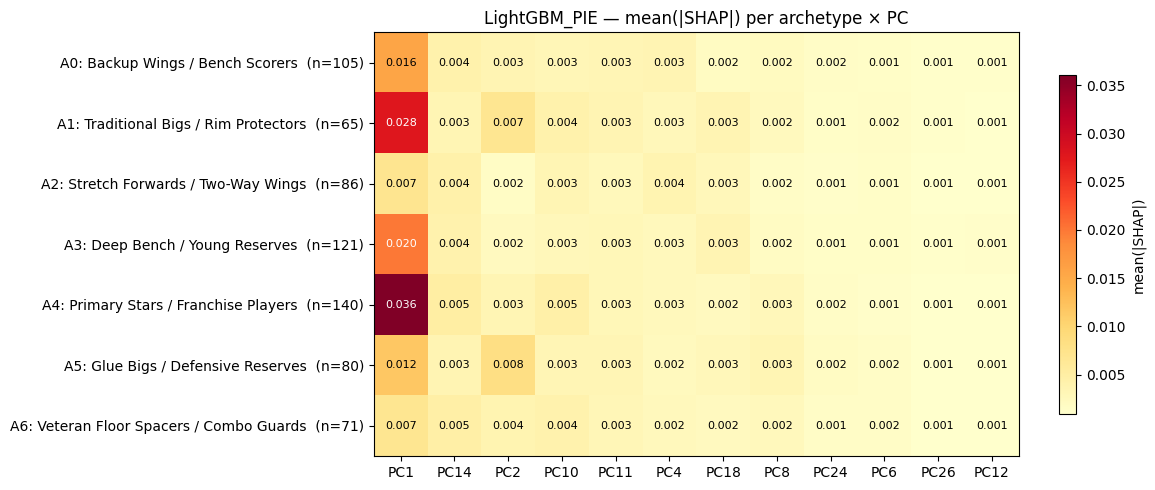

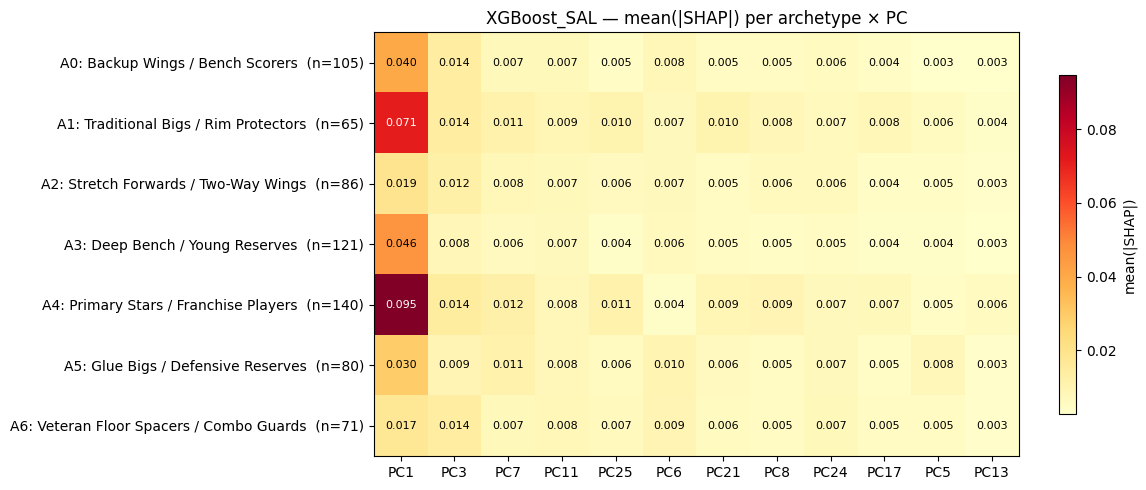


Differential PCs  (archetype mean|SHAP| / global mean|SHAP| > 1.8x)

LightGBM_PIE
  A0 Backup Wings / Bench Scorers         -> no over-reliance
  A1 Traditional Bigs / Rim Protector     -> no over-reliance
  A2 Stretch Forwards / Two-Way Wings     -> no over-reliance
  A3 Deep Bench / Young Reserves          -> no over-reliance
  A4 Primary Stars / Franchise Player     -> PC1(1.9x)
  A5 Glue Bigs / Defensive Reserves       -> PC2(2.1x)
  A6 Veteran Floor Spacers / Combo Gu     -> no over-reliance

XGBoost_SAL
  A0 Backup Wings / Bench Scorers         -> no over-reliance
  A1 Traditional Bigs / Rim Protector     -> no over-reliance
  A2 Stretch Forwards / Two-Way Wings     -> no over-reliance
  A3 Deep Bench / Young Reserves          -> no over-reliance
  A4 Primary Stars / Franchise Player     -> PC1(1.9x)
  A5 Glue Bigs / Defensive Reserves       -> PC2(2.6x)
  A6 Veteran Floor Spacers / Combo Gu     -> no over-reliance


In [43]:
# CELL 35
# Block E Part 5: archetype-level SHAP summaries. For each (archetype, PC)
# we compute mean(|SHAP|) over the TEST players of that archetype. The resulting heatmaps show whether different archetypes are predicted
# through different latent dimensions. Reuses SHAP values.
# Generates TWO separate figures (one per model.

TOP_N_PCS_HEATMAP    = 12
ARCH_RATIO_THRESHOLD = 1.8   # raised from 1.5 for cleaner thesis findings
MIN_ARCH_N           = 10

def archetype_shap_matrix(shap_values, archetypes, top_n):
    """Return arch_labels, top PC names, mean(|SHAP|) matrix and counts."""
    abs_shap     = np.abs(shap_values)
    top_pc_idx   = np.argsort(abs_shap.mean(axis=0))[-top_n:][::-1]
    top_pc_names = [pca_col_names[i] for i in top_pc_idx]
    arch_labels  = sorted(np.unique(archetypes))
    matrix       = np.zeros((len(arch_labels), top_n))
    counts       = np.zeros(len(arch_labels), dtype=int)
    for i, k in enumerate(arch_labels):
        mask = archetypes == k
        if mask.sum() == 0:
            continue
        matrix[i, :] = abs_shap[mask][:, top_pc_idx].mean(axis=0)
        counts[i]   = mask.sum()
    return arch_labels, top_pc_names, matrix, counts

print("=" * 90)
print("ARCHETYPE-LEVEL SHAP  -  mean(|SHAP|) per archetype x PC")
print("=" * 90)

# Separate figure per model for thesis-quality readability
FIGURES = [
    ("LightGBM_PIE", shap_values_lgbm, "shap_per_archetype_PIE.png"),
    ("XGBoost_SAL",  shap_values_xgb,  "shap_per_archetype_SAL.png"),
]

for model_name, shap_vals, out_path in FIGURES:
    arch_labels, top_pc_names, M, counts = archetype_shap_matrix(
        shap_vals, arch_test, top_n=TOP_N_PCS_HEATMAP,
    )
    # Full archetype names with counts (no truncation needed in single-panel layout)
    row_labels = [
        f"A{k}: {ARCHETYPE_NAMES[k]}  (n={n})"
        for k, n in zip(arch_labels, counts)
    ]

    fig, ax = plt.subplots(figsize=(12, 5))
    im = ax.imshow(M, aspect="auto", cmap="YlOrRd")
    ax.set_xticks(range(len(top_pc_names)))
    ax.set_xticklabels(top_pc_names, fontsize=10)
    ax.set_yticks(range(len(row_labels)))
    ax.set_yticklabels(row_labels, fontsize=10)
    ax.set_title(f"{model_name} — mean(|SHAP|) per archetype × PC", fontsize=12)
    plt.colorbar(im, ax=ax, label="mean(|SHAP|)", shrink=0.8)

    vmax = M.max()
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            val   = M[i, j]
            color = "white" if val > vmax * 0.55 else "black"
            ax.text(j, i, f"{val:.3f}", ha="center", va="center",
                    fontsize=8, color=color)

    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()

# Differential analysis: PCs an archetype uses more than the global average
print(
    "\nDifferential PCs  (archetype mean|SHAP| / global mean|SHAP| > "
    f"{ARCH_RATIO_THRESHOLD}x)"
)
for model_name, shap_vals in [
    ("LightGBM_PIE", shap_values_lgbm),
    ("XGBoost_SAL",  shap_values_xgb),
]:
    abs_shap    = np.abs(shap_vals)
    global_mean = abs_shap.mean(axis=0)
    threshold   = global_mean.max() * 0.05  # PC must be at least 5% of strongest
    print(f"\n{model_name}")
    for k in sorted(np.unique(arch_test)):
        mask = arch_test == k
        if mask.sum() < MIN_ARCH_N:
            print(f"  A{k} {ARCHETYPE_NAMES[k][:32]:35s}  n={mask.sum()} too small")
            continue
        arch_mean = abs_shap[mask].mean(axis=0)
        ratio     = arch_mean / (global_mean + 1e-12)
        sig_mask  = (ratio > ARCH_RATIO_THRESHOLD) & (arch_mean > threshold)
        if sig_mask.sum() == 0:
            print(f"  A{k} {ARCHETYPE_NAMES[k][:32]:35s}  -> no over-reliance")
            continue
        sig_pcs = sorted(
            zip(np.where(sig_mask)[0], ratio[sig_mask]),
            key=lambda x: -x[1],
        )[:3]
        sig_str = ", ".join(f"{pca_col_names[i]}({r:.1f}x)" for i, r in sig_pcs)
        print(f"  A{k} {ARCHETYPE_NAMES[k][:32]:35s}  -> {sig_str}")